# Análisis Exploratorio de Datos: contaminantes, clima e índices urbanos

En este *notebook*, realizamos el análisis exploratorio de los *datasets* almacenados en la carpeta `archivos_cont_clima_indices`. Cada archivo representa una ciudad y contiene registros horarios para el periodo comprendido entre el 1 de enero de 2013 y el 31 de diciembre de 2024.

Los datasets integran información de distinta naturaleza:

- variables temporales de inicio y fin de medición;
- contaminantes atmosféricos;
- variables meteorológicas;
- índices urbanos interpolados, principalmente NDVI y NDBI.

El objetivo principal de este EDA es estudiar la estructura, calidad, disponibilidad y comportamiento temporal de los datos antes de utilizarlos en la construcción de modelos predictivos.

In [25]:
# =============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# =============================================================================

# Librerías básicas para manejo de rutas y archivos.
from pathlib import Path
import os
import re
import unicodedata
import warnings

# Librerías principales de análisis de datos.
import numpy as np
import pandas as pd

# Librería para visualización.
import matplotlib.pyplot as plt

# PCHIP como método de interpolación.
from scipy.interpolate import PchipInterpolator

# Ignoramos warnings poco relevantes para que el notebook sea más limpio.
warnings.filterwarnings("ignore")

# Configuración de pandas para ver mejor las tablas.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)
pd.set_option("display.max_colwidth", 120)

# Configuración general de las figuras.
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 120

In [26]:
# =============================================================================
# 2. CONFIGURACIÓN DE RUTAS Y PERIODO DE ESTUDIO
# =============================================================================

# -----------------------------------------------------------------------------
# Ruta base del proyecto
# -----------------------------------------------------------------------------
# En tu caso, el notebook está dentro de:
# scripts/Exploración de los datos
#
# Pero la carpeta datasets está directamente dentro de TFM_github.
# Por eso aquí usamos la ruta absoluta a la carpeta raíz del proyecto.
# -----------------------------------------------------------------------------

BASE_PATH = Path("..", "..")

# Carpeta que contiene los datasets finales por ciudad.
FOLDER_DATOS = BASE_PATH / "datasets" / "archivos_cont_clima_indices"

# Carpeta donde guardaremos resultados del EDA.
# Esto no modifica los datos originales.
FOLDER_OUTPUT = BASE_PATH / "datasets" / "eda_archivos_cont_clima_indices"
FOLDER_FIGS = BASE_PATH / "figuras" / "EDA"

# Creamos las carpetas de salida si no existen.
FOLDER_OUTPUT.mkdir(parents=True, exist_ok=True)
FOLDER_FIGS.mkdir(parents=True, exist_ok=True)

# Periodo completo del trabajo.
FECHA_INICIO = pd.Timestamp("2013-01-01 00:00:00")
FECHA_FIN = pd.Timestamp("2024-12-31 23:00:00")

# Número de horas esperadas entre ambas fechas.
# Sirve para comprobar si los datasets cubren todo el periodo horario.
HORAS_ESPERADAS = len(pd.date_range(FECHA_INICIO, FECHA_FIN, freq="h"))

print("Ruta base del proyecto:")
print(BASE_PATH.resolve())

print("\nRuta de los datos:")
print(FOLDER_DATOS.resolve())

print("\nRuta de salida:")
print(FOLDER_OUTPUT.resolve())

print(f"\nHoras esperadas en el periodo 2013-2024: {HORAS_ESPERADAS:,}")

Ruta base del proyecto:
C:\Users\Juanfran cd\Desktop\Máster_Ciencia_de_Datos_UA\TFM\TFM_github

Ruta de los datos:
C:\Users\Juanfran cd\Desktop\Máster_Ciencia_de_Datos_UA\TFM\TFM_github\datasets\archivos_cont_clima_indices

Ruta de salida:
C:\Users\Juanfran cd\Desktop\Máster_Ciencia_de_Datos_UA\TFM\TFM_github\datasets\eda_archivos_cont_clima_indices

Horas esperadas en el periodo 2013-2024: 105,192


In [27]:
# =============================================================================
# 3. FUNCIONES AUXILIARES
# =============================================================================

def leer_csv_robusto(ruta, nrows=None):
    """
    Lee un archivo CSV intentando detectar automáticamente el separador.

    En este proyecto puede ocurrir que algunos archivos estén separados por coma
    y otros por punto y coma. Por eso se intenta primero una lectura automática.
    Si falla, se prueban separadores concretos.

    Parámetros
    ----------
    ruta : str o Path
        Ruta del archivo CSV.
    nrows : int, opcional
        Número de filas a leer. Es útil cuando solo queremos inspeccionar.

    Devuelve
    --------
    DataFrame
        Dataset leído como pandas DataFrame.
    """

    ruta = Path(ruta)

    try:
        return pd.read_csv(
            ruta,
            sep=None,
            engine="python",
            encoding="utf-8-sig",
            nrows=nrows
        )

    except Exception:
        try:
            return pd.read_csv(
                ruta,
                sep=";",
                encoding="utf-8-sig",
                nrows=nrows
            )

        except Exception:
            return pd.read_csv(
                ruta,
                sep=",",
                encoding="utf-8-sig",
                nrows=nrows
            )


def normalizar_texto(texto):
    """
    Normaliza texto para poder comparar nombres de columnas de forma más robusta.

    Lo que hace:
    - convierte a string,
    - elimina tildes,
    - pasa a minúsculas,
    - sustituye caracteres raros por guiones bajos,
    - elimina guiones bajos repetidos.

    Esta función será útil para detectar automáticamente columnas como:
    NO2, NO_2, dióxido de nitrógeno, PM10, temperatura, etc.
    """

    texto = str(texto)

    # Eliminamos tildes.
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))

    # Homogeneizamos símbolos de micro.
    texto = texto.replace("µ", "u").replace("μ", "u")

    # Pasamos a minúsculas.
    texto = texto.lower()

    # Sustituimos todo lo que no sea letra o número por "_".
    texto = re.sub(r"[^a-z0-9]+", "_", texto)

    # Quitamos repeticiones y extremos.
    texto = re.sub(r"_+", "_", texto).strip("_")

    return texto


def nombre_ciudad_desde_archivo(ruta):
    """
    Obtiene el nombre de la ciudad a partir del nombre del archivo.

    Por ejemplo:
    - Albacete.csv -> Albacete
    - Alicante-Alacant.csv -> Alicante/Alacant

    Esta columna nos permitirá unir todos los archivos en un único DataFrame.
    """

    stem = Path(ruta).stem

    if stem.lower() in ["alicante_alacant", "alicante-alacant"]:
        return "Alicante/Alacant"

    return stem.replace("_", " ")


def guardar_figura(nombre):
    """
    Guarda la figura activa en la carpeta de figuras y después la muestra.
    """

    ruta = FOLDER_FIGS / f"{nombre}.png"
    plt.savefig(ruta, bbox_inches="tight", dpi=180)
    print(f"Figura guardada en: {ruta}")
    plt.show()

In [28]:
# =============================================================================
# 4. INSPECCIÓN DE ARCHIVOS DISPONIBLES
# =============================================================================

archivos = sorted(FOLDER_DATOS.glob("*.csv"))

print("Archivos encontrados en archivos_cont_clima_indices")
print("-" * 80)

for archivo in archivos:
    print(archivo.name)

print("-" * 80)
print(f"Número total de archivos encontrados: {len(archivos)}")

# Comprobación básica.
if len(archivos) == 0:
    raise FileNotFoundError(
        f"No se han encontrado archivos CSV en {FOLDER_DATOS.resolve()}. "
        "Revisa la ruta antes de continuar."
    )

Archivos encontrados en archivos_cont_clima_indices
--------------------------------------------------------------------------------
A_Coruña.csv
Albacete.csv
Alicante-Alacant.csv
Barcelona.csv
Bilbao.csv
Madrid.csv
Murcia.csv
Santa_Cruz_de_Tenerife.csv
Sevilla.csv
Valencia.csv
Valladolid.csv
Zaragoza.csv
--------------------------------------------------------------------------------
Número total de archivos encontrados: 12


In [29]:
# =============================================================================
# 5. CARGA DE TODOS LOS DATASETS
# =============================================================================

dfs = []

for archivo in archivos:

    # Obtenemos el nombre de ciudad desde el nombre del archivo.
    ciudad = nombre_ciudad_desde_archivo(archivo)

    print(f"Leyendo {archivo.name} como ciudad: {ciudad}")

    # Leemos el CSV.
    df = leer_csv_robusto(archivo)

    # Añadimos la ciudad como columna explícita.
    df["city"] = ciudad

    # Guardamos el DataFrame en una lista.
    dfs.append(df)

# Concatenamos todos los archivos.
df_all = pd.concat(dfs, ignore_index=True)

print("\nDataset conjunto creado correctamente.")
print(f"Número total de filas: {len(df_all):,}")
print(f"Número total de columnas: {df_all.shape[1]}")
print(f"Número de ciudades detectadas: {df_all['city'].nunique()}")

display(df_all.head())
display(df_all.tail())

Leyendo A_Coruña.csv como ciudad: A Coruña
Leyendo Albacete.csv como ciudad: Albacete
Leyendo Alicante-Alacant.csv como ciudad: Alicante/Alacant
Leyendo Barcelona.csv como ciudad: Barcelona
Leyendo Bilbao.csv como ciudad: Bilbao
Leyendo Madrid.csv como ciudad: Madrid
Leyendo Murcia.csv como ciudad: Murcia
Leyendo Santa_Cruz_de_Tenerife.csv como ciudad: Santa Cruz de Tenerife
Leyendo Sevilla.csv como ciudad: Sevilla
Leyendo Valencia.csv como ciudad: Valencia
Leyendo Valladolid.csv como ciudad: Valladolid
Leyendo Zaragoza.csv como ciudad: Zaragoza

Dataset conjunto creado correctamente.
Número total de filas: 1,262,304
Número total de columnas: 23
Número de ciudades detectadas: 12


,Start,End,CO (mg.m-3),NO (ug.m-3),NO2 (ug.m-3),NOx (ug.m-3),O3 (ug.m-3),PM10 (ug.m-3),SO2 (ug.m-3),city,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,surface_pressure,cloudcover,windspeed_10m,shortwave_radiation,boundary_layer_height,NDVI,NDBI,C6H6 (ug.m-3)
0,2013-01-01 00:00:00,2013-01-01 01:00:00,NaN,NaN,NaN,NaN,37.5,NaN,NaN,A Coruña,10.3,88.0,0.0,0.0,0.0,1011.8,26.0,12.7,0.0,475.0,0.358500,-0.159821,NaN
1,2013-01-01 01:00:00,2013-01-01 02:00:00,0.12,34.0,15.0,1.8,37.5,36.5,2.90,A Coruña,10.6,87.0,0.0,0.0,0.0,1012.1,40.0,13.7,0.0,530.0,0.358502,-0.159821,NaN
2,2013-01-01 02:00:00,2013-01-01 03:00:00,0.12,36.5,12.0,1.3,34.0,44.0,3.35,A Coruña,10.5,87.0,0.1,0.1,0.0,1012.5,63.0,14.1,0.0,530.0,0.358506,-0.159822,NaN
3,2013-01-01 03:00:00,2013-01-01 04:00:00,0.12,34.5,9.8,1.0,35.5,42.0,3.15,A Coruña,10.4,88.0,0.1,0.1,0.0,1012.8,57.0,11.9,0.0,520.0,0.358514,-0.159824,NaN
4,2013-01-01 04:00:00,2013-01-01 05:00:00,0.12,34.5,11.0,1.0,32.5,24.0,3.50,A Coruña,10.5,89.0,0.0,0.0,0.0,1013.3,48.0,10.5,0.0,450.0,0.358524,-0.159827,NaN


,Start,End,CO (mg.m-3),NO (ug.m-3),NO2 (ug.m-3),NOx (ug.m-3),O3 (ug.m-3),PM10 (ug.m-3),SO2 (ug.m-3),city,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,surface_pressure,cloudcover,windspeed_10m,shortwave_radiation,boundary_layer_height,NDVI,NDBI,C6H6 (ug.m-3)
1262299,2024-12-31 19:00:00,2024-12-31 20:00:00,-142.51,-105.75,-39.30,-113.38,-114.34,-155.10,-164.06,Zaragoza,1.5,93.0,0.0,0.0,0.0,1005.8,16.0,5.8,0.0,55.0,0.085,0.034833,0.18
1262300,2024-12-31 20:00:00,2024-12-31 21:00:00,-142.50,-107.43,-42.17,-115.16,-112.07,-151.65,-164.01,Zaragoza,0.6,95.0,0.0,0.0,0.0,1005.9,13.0,5.2,0.0,40.0,0.085,0.034833,0.16
1262301,2024-12-31 21:00:00,2024-12-31 22:00:00,-142.52,-107.90,-45.01,-117.95,-111.49,-153.46,-164.16,Zaragoza,0.1,94.0,0.0,0.0,0.0,1006.0,16.0,5.3,0.0,35.0,0.085,0.034833,0.16
1262302,2024-12-31 22:00:00,2024-12-31 23:00:00,-142.53,-111.50,-49.54,-121.43,-106.75,-156.09,-164.36,Zaragoza,-0.1,93.0,0.0,0.0,0.0,1006.3,30.0,6.1,0.0,55.0,0.085,0.034833,0.11
1262303,2024-12-31 23:00:00,2025-01-01 00:00:00,-142.54,-112.65,-50.46,-121.76,-104.41,-157.57,-164.22,Zaragoza,-0.2,94.0,0.0,0.0,0.0,1006.5,46.0,6.2,0.0,60.0,0.085,0.034833,0.11


In [30]:
# =============================================================================
# 6. CONVERSIÓN DE VARIABLES TEMPORALES
# =============================================================================

# Comprobamos que exista la columna Start.
if "Start" not in df_all.columns:
    raise ValueError("No existe la columna 'Start'. Revisa los nombres de las columnas.")

# Convertimos Start a datetime.
df_all["Start"] = pd.to_datetime(df_all["Start"], errors="coerce")

# Si existe End, también la convertimos.
if "End" in df_all.columns:
    df_all["End"] = pd.to_datetime(df_all["End"], errors="coerce")

# Eliminamos filas sin Start porque no pueden utilizarse en un análisis temporal.
filas_antes = len(df_all)
df_all = df_all.dropna(subset=["Start"]).copy()
filas_despues = len(df_all)

print(f"Filas eliminadas por Start no válido: {filas_antes - filas_despues}")

# Ordenamos por ciudad y fecha.
df_all = df_all.sort_values(["city", "Start"]).reset_index(drop=True)

# Mostramos el rango temporal global.
print("Fecha mínima global:", df_all["Start"].min())
print("Fecha máxima global:", df_all["Start"].max())

Filas eliminadas por Start no válido: 0
Fecha mínima global: 2013-01-01 00:00:00
Fecha máxima global: 2024-12-31 23:00:00


In [ ]:
# =============================================================================
# 7. CREACIÓN DE VARIABLES TEMPORALES
# =============================================================================

# Año de la observación.
df_all["Año"] = df_all["Start"].dt.year

# Mes numérico.
df_all["Mes"] = df_all["Start"].dt.month

# Día del mes.
df_all["Dia"] = df_all["Start"].dt.day

# Hora del día.
df_all["Hora"] = df_all["Start"].dt.hour

# Día de la semana:
# lunes = 0, martes = 1, ..., domingo = 6.
df_all["Dia_semana"] = df_all["Start"].dt.dayofweek

# Fin de semana como variable binaria.
df_all["Fin_de_semana"] = df_all["Dia_semana"].isin([5, 6]).astype(int)

# Fecha sin hora, útil para agregaciones diarias.
df_all["Fecha"] = df_all["Start"].dt.date

# Semana del año.
df_all["Semana_año"] = df_all["Start"].dt.isocalendar().week.astype(int)


def asignar_estacion(mes):
    """
    Asigna una estación meteorológica aproximada según el mes.

    Se usa una clasificación simple:
    - invierno: diciembre, enero, febrero
    - primavera: marzo, abril, mayo
    - verano: junio, julio, agosto
    - otoño: septiembre, octubre, noviembre
    """

    if mes in [12, 1, 2]:
        return "Invierno"
    elif mes in [3, 4, 5]:
        return "Primavera"
    elif mes in [6, 7, 8]:
        return "Verano"
    else:
        return "Otoño"


df_all["Estacion"] = df_all["Mes"].apply(asignar_estacion)

display(df_all[["city", "Start", "Año", "Mes", "Hora", "Dia_semana", "Fin_de_semana", "Estacion"]].head(25))

,city,Start,Año,Mes,Hora,Dia_semana,Fin_de_semana,Estacion
0,A Coruña,2013-01-01 00:00:00,2013,1,0,1,0,Invierno
1,A Coruña,2013-01-01 01:00:00,2013,1,1,1,0,Invierno
2,A Coruña,2013-01-01 02:00:00,2013,1,2,1,0,Invierno
3,A Coruña,2013-01-01 03:00:00,2013,1,3,1,0,Invierno
4,A Coruña,2013-01-01 04:00:00,2013,1,4,1,0,Invierno
5,A Coruña,2013-01-01 05:00:00,2013,1,5,1,0,Invierno
6,A Coruña,2013-01-01 06:00:00,2013,1,6,1,0,Invierno
7,A Coruña,2013-01-01 07:00:00,2013,1,7,1,0,Invierno
8,A Coruña,2013-01-01 08:00:00,2013,1,8,1,0,Invierno
9,A Coruña,2013-01-01 09:00:00,2013,1,9,1,0,Invierno


In [32]:
# =============================================================================
# 8. DETECCIÓN AUTOMÁTICA DE VARIABLES
# =============================================================================

# Columnas que no queremos tratar como variables numéricas de análisis.
COLUMNAS_NO_ANALISIS = {
    "Start", "End", "city", "Año", "Mes", "Dia", "Hora",
    "Dia_semana", "Fin_de_semana", "Fecha", "Semana_año", "Estacion"
}

# Nos quedamos con columnas numéricas que no sean temporales ni identificadoras.
columnas_numericas = [
    c for c in df_all.columns
    if c not in COLUMNAS_NO_ANALISIS
    and pd.api.types.is_numeric_dtype(df_all[c])
]


def detectar_contaminante(columna):
    """
    Intenta detectar si una columna corresponde a un contaminante atmosférico.

    Está preparado para nombres como:
    - NO2
    - NO_2
    - O3
    - PM10
    - C6H6
    - Benzene
    - SO2
    """

    c = normalizar_texto(columna).upper()

    # Evitamos confundir columnas de nieve con NO.
    if "SNOW" in c or "NIEVE" in c:
        return None

    patrones = {
        "PM10": [r"PM_?10"],
        "PM2.5": [r"PM_?2_?5", r"PM25"],
        "NO2": [r"NO_?2"],
        "NOx": [r"NO_?X", r"NOX"],
        "NO": [r"(^|_)NO($|_)"],
        "O3": [r"O_?3"],
        "CO": [r"(^|_)CO($|_)"],
        "SO2": [r"SO_?2"],
        "C6H6": [r"C_?6_?H_?6", r"BENCENO", r"BENZENE"]
    }

    for contaminante, lista_patrones in patrones.items():
        for patron in lista_patrones:
            if re.search(patron, c):
                return contaminante

    return None


def detectar_indice_urbano(columna):
    """
    Detecta si una columna es un índice urbano.
    """

    c = normalizar_texto(columna).upper()

    if "NDVI" in c:
        return "NDVI"

    if "NDBI" in c:
        return "NDBI"

    return None


def detectar_variable_climatica(columna):
    """
    Detecta si una columna parece corresponder a una variable meteorológica.
    """

    c = normalizar_texto(columna)

    patrones = {
        "Temperatura": ["temperature", "temperatura", "temp"],
        "Humedad": ["humidity", "humedad", "relative_humidity"],
        "Precipitación": ["precipitation", "precipitacion"],
        "Lluvia": ["rain", "lluvia"],
        "Nieve": ["snow", "snowfall", "nieve"],
        "Presión": ["pressure", "presion"],
        "Nubosidad": ["cloud", "nubosidad"],
        "Radiación": ["radiation", "radiacion", "shortwave"],
        "Viento": ["wind", "viento"],
        "PBLH": ["pblh", "boundary_layer", "planetary_boundary_layer"]
    }

    for etiqueta, claves in patrones.items():
        if any(clave in c for clave in claves):
            return etiqueta

    return None


# Listas finales.
columnas_contaminantes = []
columnas_clima = []
columnas_indices = []
columnas_otras = []

# Diccionarios para guardar la etiqueta detectada.
mapa_contaminantes = {}
mapa_clima = {}
mapa_indices = {}

for col in columnas_numericas:

    contaminante = detectar_contaminante(col)
    indice = detectar_indice_urbano(col)
    clima = detectar_variable_climatica(col)

    if contaminante is not None:
        columnas_contaminantes.append(col)
        mapa_contaminantes[col] = contaminante

    elif indice is not None:
        columnas_indices.append(col)
        mapa_indices[col] = indice

    elif clima is not None:
        columnas_clima.append(col)
        mapa_clima[col] = clima

    else:
        columnas_otras.append(col)


print("Contaminantes detectados:")
display(pd.DataFrame({
    "columna": columnas_contaminantes,
    "etiqueta_detectada": [mapa_contaminantes[c] for c in columnas_contaminantes]
}))

print("Variables climáticas detectadas:")
display(pd.DataFrame({
    "columna": columnas_clima,
    "etiqueta_detectada": [mapa_clima[c] for c in columnas_clima]
}))

print("Índices urbanos detectados:")
display(pd.DataFrame({
    "columna": columnas_indices,
    "etiqueta_detectada": [mapa_indices[c] for c in columnas_indices]
}))

print("Otras columnas numéricas no clasificadas:")
display(pd.DataFrame({"columna": columnas_otras}))

Contaminantes detectados:


,columna,etiqueta_detectada
0,CO (mg.m-3),CO
1,NO (ug.m-3),NO
2,NO2 (ug.m-3),NO2
3,NOx (ug.m-3),NOx
4,O3 (ug.m-3),O3
5,PM10 (ug.m-3),PM10
6,SO2 (ug.m-3),SO2
7,C6H6 (ug.m-3),C6H6


Variables climáticas detectadas:


,columna,etiqueta_detectada
0,temperature_2m,Temperatura
1,relative_humidity_2m,Humedad
2,precipitation,Precipitación
3,rain,Lluvia
4,snowfall,Nieve
5,surface_pressure,Presión
6,cloudcover,Nubosidad
7,windspeed_10m,Viento
8,shortwave_radiation,Radiación
9,boundary_layer_height,PBLH


Índices urbanos detectados:


,columna,etiqueta_detectada
0,NDVI,NDVI
1,NDBI,NDBI


Otras columnas numéricas no clasificadas:


,columna


### **ANÁLISIS ESTRUCTURAL Y DISPONIBILIDAD DE VARIABLES**

In [33]:
# =============================================================================
# 9. RESUMEN GENERAL POR CIUDAD
# =============================================================================

resumen_ciudades = []

for ciudad, df_ciudad in df_all.groupby("city"):

    # Número de filas.
    n_filas = len(df_ciudad)

    # Número de horas únicas.
    horas_unicas = df_ciudad["Start"].nunique()

    # Rango temporal observado.
    fecha_min = df_ciudad["Start"].min()
    fecha_max = df_ciudad["Start"].max()

    # Número de Start duplicados.
    duplicados_start = df_ciudad["Start"].duplicated().sum()

    # Porcentaje de cobertura respecto al periodo teórico completo.
    cobertura_periodo = 100 * horas_unicas / HORAS_ESPERADAS

    # Número de variables disponibles por tipo.
    n_contaminantes = sum(df_ciudad[c].notna().sum() > 0 for c in columnas_contaminantes)
    n_clima = sum(df_ciudad[c].notna().sum() > 0 for c in columnas_clima)
    n_indices = sum(df_ciudad[c].notna().sum() > 0 for c in columnas_indices)

    resumen_ciudades.append({
        "Ciudad": ciudad,
        "filas": n_filas,
        "fecha_min": fecha_min,
        "fecha_max": fecha_max,
        "horas_unicas": horas_unicas,
        "cobertura_periodo_%": cobertura_periodo,
        "duplicados_Start": duplicados_start,
        "n_contaminantes_con_datos": n_contaminantes,
        "n_variables_clima_con_datos": n_clima,
        "n_indices_con_datos": n_indices
    })


df_resumen_ciudades = pd.DataFrame(resumen_ciudades).sort_values("Ciudad")

display(df_resumen_ciudades)

,Ciudad,filas,fecha_min,fecha_max,horas_unicas,cobertura_periodo_%,duplicados_Start,n_contaminantes_con_datos,n_variables_clima_con_datos,n_indices_con_datos
0,A Coruña,105192,2013-01-01,2024-12-31 23:00:00,105192,100.0,0,7,10,2
1,Albacete,105192,2013-01-01,2024-12-31 23:00:00,105192,100.0,0,7,10,2
2,Alicante/Alacant,105192,2013-01-01,2024-12-31 23:00:00,105192,100.0,0,8,10,2
3,Barcelona,105192,2013-01-01,2024-12-31 23:00:00,105192,100.0,0,8,10,2
4,Bilbao,105192,2013-01-01,2024-12-31 23:00:00,105192,100.0,0,8,10,2
5,Madrid,105192,2013-01-01,2024-12-31 23:00:00,105192,100.0,0,8,10,2
6,Murcia,105192,2013-01-01,2024-12-31 23:00:00,105192,100.0,0,8,10,2
7,Santa Cruz de Tenerife,105192,2013-01-01,2024-12-31 23:00:00,105192,100.0,0,8,10,2
8,Sevilla,105192,2013-01-01,2024-12-31 23:00:00,105192,100.0,0,8,10,2
9,Valencia,105192,2013-01-01,2024-12-31 23:00:00,105192,100.0,0,8,10,2


Esta tabla resume la estructura temporal y la disponibilidad general de variables para cada una de las ciudades analizadas. En todos los casos, cada ciudad cuenta con 105.192 registros, correspondientes al periodo horario completo comprendido entre el 1 de enero de 2013 y el 31 de diciembre de 2024 a las 23:00.

La cobertura temporal es del 100% en todas las ciudades, lo que indica que para cada una de ellas existe una fila por cada hora esperada dentro del periodo de estudio. Además, no se detectan valores duplicados en la columna temporal `Start`, por lo que no existen horas repetidas dentro de una misma ciudad.

También, observamos que todas las ciudades presentan datos para las 10 variables meteorológicas consideradas y para los 2 índices urbanos, NDVI y NDBI. En cuanto a los contaminantes atmosféricos, la mayoría de ciudades dispone de registros para los 8 contaminantes considerados. Sin embargo, A Coruña y Albacete presentan datos para 7 contaminantes, lo que indica que al menos uno de los contaminantes no tiene registros disponibles en esas ciudades.

No obstante, una cobertura temporal del 100% no implica necesariamente que todas las variables tengan valores válidos en todas las horas. Significa que la estructura horaria está completa, pero dentro de esas filas pueden existir valores vacíos o nulos.

### **ANÁLISIS DE VALORES FALTANTES**

In [34]:
# =============================================================================
# 10. COMPROBACIÓN DE CONTINUIDAD TEMPORAL
# =============================================================================

resumen_continuidad = []

for ciudad, df_ciudad in df_all.groupby("city"):

    df_ciudad = df_ciudad.sort_values("Start").copy()

    # Creamos el rango horario esperado entre la primera y la última fecha de esa ciudad.
    rango_esperado = pd.date_range(
        start=df_ciudad["Start"].min(),
        end=df_ciudad["Start"].max(),
        freq="h"
    )

    # Fechas realmente presentes.
    fechas_presentes = pd.DatetimeIndex(df_ciudad["Start"].unique())

    # Horas faltantes.
    horas_faltantes = rango_esperado.difference(fechas_presentes)

    resumen_continuidad.append({
        "Ciudad": ciudad,
        "inicio_observado": df_ciudad["Start"].min(),
        "fin_observado": df_ciudad["Start"].max(),
        "horas_esperadas_en_rango": len(rango_esperado),
        "horas_presentes": len(fechas_presentes),
        "horas_faltantes": len(horas_faltantes),
        "pct_horas_faltantes": 100 * len(horas_faltantes) / len(rango_esperado)
    })

df_continuidad = pd.DataFrame(resumen_continuidad).sort_values("Ciudad")

display(df_continuidad)

,Ciudad,inicio_observado,fin_observado,horas_esperadas_en_rango,horas_presentes,horas_faltantes,pct_horas_faltantes
0,A Coruña,2013-01-01,2024-12-31 23:00:00,105192,105192,0,0.0
1,Albacete,2013-01-01,2024-12-31 23:00:00,105192,105192,0,0.0
2,Alicante/Alacant,2013-01-01,2024-12-31 23:00:00,105192,105192,0,0.0
3,Barcelona,2013-01-01,2024-12-31 23:00:00,105192,105192,0,0.0
4,Bilbao,2013-01-01,2024-12-31 23:00:00,105192,105192,0,0.0
5,Madrid,2013-01-01,2024-12-31 23:00:00,105192,105192,0,0.0
6,Murcia,2013-01-01,2024-12-31 23:00:00,105192,105192,0,0.0
7,Santa Cruz de Tenerife,2013-01-01,2024-12-31 23:00:00,105192,105192,0,0.0
8,Sevilla,2013-01-01,2024-12-31 23:00:00,105192,105192,0,0.0
9,Valencia,2013-01-01,2024-12-31 23:00:00,105192,105192,0,0.0


In [35]:
# =============================================================================
# 11. PORCENTAJE DE VALORES NULOS POR CIUDAD Y VARIABLE
# =============================================================================

variables_eda = columnas_contaminantes + columnas_clima + columnas_indices

resumen_nulos = []

for ciudad, df_ciudad in df_all.groupby("city"):

    for variable in variables_eda:

        n_total = len(df_ciudad)
        n_nulos = df_ciudad[variable].isna().sum()
        n_no_nulos = df_ciudad[variable].notna().sum()

        resumen_nulos.append({
            "Ciudad": ciudad,
            "Variable": variable,
            "n_total": n_total,
            "n_no_nulos": n_no_nulos,
            "n_nulos": n_nulos,
            "pct_no_nulos": 100 * n_no_nulos / n_total,
            "pct_nulos": 100 * n_nulos / n_total
        })


df_nulos = pd.DataFrame(resumen_nulos)

# Mostramos primero las variables con más nulos.
display(df_nulos.sort_values("pct_nulos", ascending=False).head(40))

,Ciudad,Variable,n_total,n_no_nulos,n_nulos,pct_no_nulos,pct_nulos
7,A Coruña,C6H6 (ug.m-3),105192,0,105192,0.000000,100.000000
27,Albacete,C6H6 (ug.m-3),105192,0,105192,0.000000,100.000000
227,Zaragoza,C6H6 (ug.m-3),105192,8783,96409,8.349494,91.650506
26,Albacete,SO2 (ug.m-3),105192,27383,77809,26.031447,73.968553
23,Albacete,NOx (ug.m-3),105192,27383,77809,26.031447,73.968553
25,Albacete,PM10 (ug.m-3),105192,27383,77809,26.031447,73.968553
21,Albacete,NO (ug.m-3),105192,27383,77809,26.031447,73.968553
20,Albacete,CO (mg.m-3),105192,27383,77809,26.031447,73.968553
127,Murcia,C6H6 (ug.m-3),105192,57767,47425,54.915773,45.084227
165,Sevilla,PM10 (ug.m-3),105192,61358,43834,58.329531,41.670469


En primer lugar, observamos que el contaminante con mayores problemas de disponibilidad es el benceno, C6H6. En concreto, para A Coruña y Albacete, esta variable aparece completamente vacía, con un 100% de valores nulos. Esto indica que, aunque la columna existe en el *dataset* conjunto, no hay registros disponibles de este contaminante para dichas ciudades durante el periodo analizado. También destaca el caso de Zaragoza, donde C6H6 solo dispone de aproximadamente un 8.35% de datos no nulos.

Otro caso llamativo es Albacete. Para esta ciudad, varios contaminantes presentan una disponibilidad muy pequeña: CO, NO, NOx, PM10 y SO2 tienen únicamente un 26.03% de observaciones no nulas. Esto sugiere que, para Albacete, una parte importante de los contaminantes no está disponible durante gran parte del periodo 2013-2024. Sin embargo, no todos los contaminantes de esta ciudad se comportan igual, ya que O3 presenta una disponibilidad superior al 91% y NO2 supera el 93%.

También, observamos porcentajes elevados de nulos en algunos contaminantes concretos de otras ciudades. Por ejemplo, PM10 en Sevilla presenta alrededor de un 41.67% de valores nulos, C6H6 en Murcia supera el 45% de nulos, y PM10 en Barcelona presenta aproximadamente un 33.33% de valores nulos. Estos casos deben tenerse en cuenta antes de entrenar modelos, ya que una variable con una proporción elevada de datos ausentes puede introducir sesgos o reducir la capacidad predictiva del modelo.

En cambio, la mayoría de variables meteorológicas parecen presentar una disponibilidad elevada. El caso más visible en la tabla es `boundary_layer_height`, que presenta el mismo porcentaje de nulos en todas las ciudades: aproximadamente un 4.15%, equivalente a 4368 registros horarios ausentes. Dado que este patrón se repite de forma idéntica en todas las ciudades, es probable que la ausencia se deba a la disponibilidad temporal de esta variable en la fuente meteorológica y no a un problema específico de una ciudad concreta.


In [36]:
# =============================================================================
# 12. FECHA DE INICIO DE REGISTROS POR CIUDAD Y VARIABLE
# =============================================================================

# En esta celda queremos saber desde qué momento empieza a haber datos reales
# para cada variable en cada ciudad.
#
# Es decir, para cada ciudad y cada variable, buscamos la primera fecha "Start"
# en la que esa variable no es nula.
#
# Esto es útil porque puede ocurrir que una ciudad tenga el dataset completo
# desde 2013, pero que un contaminante concreto empiece a registrarse más tarde.


def obtener_primera_fecha_registro(df, columnas_variables):
    """
    Calcula la primera fecha con dato no nulo para cada ciudad y variable.

    Parámetros
    ----------
    df : DataFrame
        Dataset completo con todas las ciudades.
        Debe contener las columnas 'Ciudad' y 'Start'.

    columnas_variables : list
        Lista de columnas para las que queremos calcular la primera fecha
        con registros disponibles.

    Devuelve
    --------
    DataFrame
        Tabla con:
        - filas: ciudades
        - columnas: variables
        - valores: primera fecha con dato no nulo
    """

    # Diccionario donde guardaremos los resultados.
    # La clave será la ciudad y el valor será otro diccionario con las fechas.
    resultados = {}

    # Recorremos ciudad por ciudad.
    for ciudad, df_ciudad in df.groupby("city"):

        # Ordenamos temporalmente para que la primera fecha encontrada
        # sea realmente la primera en el tiempo.
        df_ciudad = df_ciudad.sort_values("Start").copy()

        # Diccionario auxiliar para guardar los resultados de esta ciudad.
        resultados_ciudad = {}

        # Recorremos cada variable.
        for variable in columnas_variables:

            # Nos quedamos solo con las filas donde esa variable tiene dato.
            df_con_dato = df_ciudad[df_ciudad[variable].notna()]

            # Si no existe ningún dato no nulo, marcamos que no hay registros.
            if df_con_dato.empty:
                resultados_ciudad[variable] = "Sin registros"

            # Si sí hay datos, tomamos la primera fecha disponible.
            else:
                primera_fecha = df_con_dato["Start"].min()

                # Guardamos solo la fecha, sin hora, para que la tabla sea más limpia.
                resultados_ciudad[variable] = primera_fecha.strftime("%Y-%m-%d")

        # Guardamos los resultados de la ciudad.
        resultados[ciudad] = resultados_ciudad

    # Convertimos el diccionario en DataFrame.
    tabla = pd.DataFrame.from_dict(resultados, orient="index")

    # Ponemos nombre al índice.
    tabla.index.name = "Ciudad"

    # Ordenamos alfabéticamente las ciudades.
    tabla = tabla.sort_index()

    return tabla


# -----------------------------------------------------------------------------
# TABLA 1: PRIMERA FECHA DISPONIBLE DE CADA CONTAMINANTE
# -----------------------------------------------------------------------------

tabla_inicio_contaminantes = obtener_primera_fecha_registro(
    df=df_all,
    columnas_variables=columnas_contaminantes
)

print("Primera fecha con registros disponibles por contaminante")
display(tabla_inicio_contaminantes)


# -----------------------------------------------------------------------------
# TABLA 2: PRIMERA FECHA DISPONIBLE DE CADA VARIABLE ATMOSFÉRICA / CLIMÁTICA
# -----------------------------------------------------------------------------

tabla_inicio_clima = obtener_primera_fecha_registro(
    df=df_all,
    columnas_variables=columnas_clima
)

print("Primera fecha con registros disponibles por variable atmosférica / climática")
display(tabla_inicio_clima)

Primera fecha con registros disponibles por contaminante


,CO (mg.m-3),NO (ug.m-3),NO2 (ug.m-3),NOx (ug.m-3),O3 (ug.m-3),PM10 (ug.m-3),SO2 (ug.m-3),C6H6 (ug.m-3)
Ciudad,,,,,,,,
A Coruña,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,Sin registros
Albacete,2021-11-17,2021-11-17,2013-01-01,2021-11-17,2013-01-01,2021-11-17,2021-11-17,Sin registros
Alicante/Alacant,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01
Barcelona,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2017-01-01,2013-01-01,2014-06-30
Bilbao,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2014-01-01
Madrid,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01
Murcia,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2015-01-01,2018-05-31
Santa Cruz de Tenerife,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01
Sevilla,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2016-01-01,2013-01-01,2013-01-01


Primera fecha con registros disponibles por variable atmosférica / climática


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,surface_pressure,cloudcover,windspeed_10m,shortwave_radiation,boundary_layer_height
Ciudad,,,,,,,,,,
A Coruña,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01
Albacete,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01
Alicante/Alacant,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01
Barcelona,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01
Bilbao,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01
Madrid,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01
Murcia,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01
Santa Cruz de Tenerife,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01
Sevilla,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01,2013-01-01


Las tablas anteriores muestran la primera fecha en la que existe al menos un valor no nulo para cada variable y ciudad. Este análisis complementa el estudio de valores nulos, ya que permite distinguir entre variables que tienen huecos puntuales dentro del periodo 2013-2024 y variables cuya serie temporal comienza más tarde o directamente no contiene registros válidos.

En la **primera tabla**, correspondiente a los contaminantes atmosféricos, observamos que la mayoría de ciudades presentan registros desde el inicio del periodo de estudio; es decir, desde el 1 de enero de 2013, para contaminantes como CO, NO, NO2, NOx, O3, PM10 y SO2. Sin embargo, existen algunas excepciones. El caso más claro es el benceno, C6H6, que presenta una disponibilidad mucho más irregular que el resto de contaminantes. En A Coruña y Albacete aparece como `Sin registros`, lo que significa que no existe ningún valor válido para esta variable en dichas ciudades durante todo el periodo analizado. En otras ciudades, aunque sí hay datos, la serie comienza más tarde: por ejemplo, en Bilbao empieza en 2014, en Valencia en marzo de 2014, en Valladolid en marzo de 2015, en Murcia en mayo de 2018 y en Zaragoza no comienza hasta 2024.

También destaca el caso de Albacete. Aunque NO2 y O3 tienen registros desde 2013, otros contaminantes como CO, NO, NOx, PM10 y SO2 no comienzan hasta el 17 de noviembre de 2021. Otros casos relevantes son Barcelona y Sevilla, donde PM10 empieza en 2017 y 2016, respectivamente.

En cambio, la **segunda tabla**, correspondiente a las variables atmosféricas o meteorológicas, muestra un comportamiento mucho más homogéneo. Todas las ciudades presentan registros desde el 1 de enero de 2013 para todas las variables climáticas consideradas.

### **DETECCIÓN Y CORRECCIÓN DE VALORES INVÁLIDOS**

A continuación, identificamos los valores inválidos presentes en el *dataset*. Realizamos la detección variable por variable, generando una máscara booleana que indica qué registros contienen valores inválidos.

Consideramos inválidos los códigos asociados a errores de registro, especialmente valores menores o iguales que `-900`. Este criterio permite detectar códigos como `-999`, frecuentemente utilizados para representar ausencia de dato o valores erróneos. También permite capturar valores derivados de operaciones realizadas sobre estos códigos.

Después, aplicamos reglas específicas según el tipo de variable. En el caso de los contaminantes atmosféricos, consideramos inválidos todos los valores negativos, ya que las concentraciones de contaminantes no pueden ser inferiores a cero.

Para los índices urbanos, NDVI y NDBI, consideramos inválidos los valores situados fuera del intervalo `[-1, 1]`, ya que ambos índices están definidos teóricamente dentro de ese rango. Cualquier valor fuera de ese rango se interpreta, por tanto, como un valor no válido.

En el caso de las variables meteorológicas, aplicamos restricciones físicas básicas. Consideramos la temperatura inválida si queda fuera del intervalo `[-50, 60]`, la humedad relativa y la nubosidad si no pertenecen al rango `[0, 100]`, y variables como precipitación, lluvia, nieve o velocidad del viento las marcamos como inválidas si toman valores negativos. Para la presión atmosférica, empleamos un rango más amplio de `[800, 1100]`, mientras que para la radiación solar consideramos inválidos los valores negativos o superiores a `1400`. Finalmente, consideramos la altura de la capa límite planetaria inválida si es negativa o supera los `10000` metros.

In [37]:
# =============================================================================
# DETECCIÓN DE VALORES INVÁLIDOS EN TODO EL DATASET
# =============================================================================

# Objetivo:
# detectar valores inválidos en contaminantes, variables atmosféricas e índices.
#
# La tabla final tendrá únicamente:
# - Ciudad
# - Fecha
# - Variable
# - Valor inválido
#
# Esta celda NO modifica df_all.


# -----------------------------------------------------------------------------
# 1. VARIABLES A VALIDAR
# -----------------------------------------------------------------------------

variables_validacion = columnas_contaminantes + columnas_clima + columnas_indices


# -----------------------------------------------------------------------------
# 2. FUNCIÓN PARA DETECTAR VALORES INVÁLIDOS
# -----------------------------------------------------------------------------

def detectar_mask_invalidos(df, variable):
    """
    Devuelve una máscara booleana indicando qué filas tienen valores inválidos
    para una variable concreta.

    Importante:
    - No considera inválidos los NaN originales.
    - Solo marca valores presentes pero incorrectos.
    """

    nombre = normalizar_texto(variable)

    # Serie original.
    serie_original = df[variable]

    # Convertimos a numérico.
    # Si algún valor no puede convertirse, pasa a NaN.
    serie_num = pd.to_numeric(serie_original, errors="coerce")

    # Valor no numérico:
    # originalmente no era nulo, pero al convertirlo a numérico pasa a NaN.
    mask_no_numerico = serie_original.notna() & serie_num.isna()

    # Códigos centinela tipo -999.
    # También capturamos valores claramente derivados de códigos inválidos.
    mask_centinela = serie_num <= -900

    # Máscara inicial.
    mask_invalido = mask_no_numerico | mask_centinela

    # -------------------------------------------------------------------------
    # Reglas para contaminantes
    # -------------------------------------------------------------------------
    if variable in columnas_contaminantes:

        # Las concentraciones de contaminantes no pueden ser negativas.
        mask_invalido = mask_invalido | (serie_num < 0)

    # -------------------------------------------------------------------------
    # Reglas para índices urbanos
    # -------------------------------------------------------------------------
    elif variable in columnas_indices:

        # NDVI y NDBI deben estar dentro del intervalo [-1, 1].
        mask_invalido = mask_invalido | (serie_num < -1) | (serie_num > 1)

    # -------------------------------------------------------------------------
    # Reglas para variables atmosféricas / meteorológicas
    # -------------------------------------------------------------------------
    elif variable in columnas_clima:

        # Temperatura: se permite que sea negativa,
        # pero no valores físicamente absurdos para el contexto.
        if "temperature" in nombre or "temperatura" in nombre:
            mask_invalido = mask_invalido | (serie_num < -50) | (serie_num > 60)

        # Humedad relativa: debe estar entre 0 y 100.
        elif "humidity" in nombre or "humedad" in nombre:
            mask_invalido = mask_invalido | (serie_num < 0) | (serie_num > 100)

        # Nubosidad: debe estar entre 0 y 100.
        elif "cloud" in nombre or "nubosidad" in nombre:
            mask_invalido = mask_invalido | (serie_num < 0) | (serie_num > 100)

        # Precipitación: no puede ser negativa.
        elif "precipitation" in nombre or "precipitacion" in nombre:
            mask_invalido = mask_invalido | (serie_num < 0)

        # Lluvia: no puede ser negativa.
        elif "rain" in nombre or "lluvia" in nombre:
            mask_invalido = mask_invalido | (serie_num < 0)

        # Nieve: no puede ser negativa.
        elif "snow" in nombre or "nieve" in nombre:
            mask_invalido = mask_invalido | (serie_num < 0)

        # Presión atmosférica/superficial.
        elif "pressure" in nombre or "presion" in nombre:
            mask_invalido = mask_invalido | (serie_num < 800) | (serie_num > 1100)

        # Velocidad del viento: no puede ser negativa.
        elif "wind" in nombre or "viento" in nombre:
            mask_invalido = mask_invalido | (serie_num < 0)

        # Radiación solar: no puede ser negativa ni superar valores muy altos.
        elif "radiation" in nombre or "radiacion" in nombre or "shortwave" in nombre:
            mask_invalido = mask_invalido | (serie_num < 0) | (serie_num > 1400)

        # Altura de la capa límite planetaria.
        elif "boundary_layer" in nombre or "pblh" in nombre:
            mask_invalido = mask_invalido | (serie_num < 0) | (serie_num > 10000)

    return mask_invalido


# -----------------------------------------------------------------------------
# 3. CREACIÓN DE LA TABLA ÚNICA DE VALORES INVÁLIDOS
# -----------------------------------------------------------------------------

lista_invalidos = []

for variable in variables_validacion:

    # Detectamos inválidos para esta variable.
    mask_invalido = detectar_mask_invalidos(df_all, variable)

    # Si no hay inválidos, pasamos a la siguiente variable.
    if mask_invalido.sum() == 0:
        continue

    # Creamos una tabla sencilla con los registros inválidos.
    df_temp = pd.DataFrame({
        "Ciudad": df_all.loc[mask_invalido, "city"],
        "Fecha": df_all.loc[mask_invalido, "Start"],
        "Variable": variable,
        "Valor inválido": df_all.loc[mask_invalido, variable]
    })

    lista_invalidos.append(df_temp)


# Unimos todos los inválidos en una única tabla.
if len(lista_invalidos) > 0:
    df_valores_invalidos = pd.concat(lista_invalidos, ignore_index=True)
else:
    df_valores_invalidos = pd.DataFrame(
        columns=["Ciudad", "Fecha", "Variable", "Valor inválido"]
    )


# Ordenamos para que sea más fácil revisar.
df_valores_invalidos = (
    df_valores_invalidos
    .sort_values(["Ciudad", "Variable", "Fecha"])
    .reset_index(drop=True)
)

display(df_valores_invalidos)

print(f"Número total de valores inválidos detectados: {len(df_valores_invalidos)}")

,Ciudad,Fecha,Variable,Valor inválido
0,A Coruña,2017-01-04 12:00:00,CO (mg.m-3),-499.45
1,A Coruña,2017-01-04 13:00:00,CO (mg.m-3),-499.45
2,A Coruña,2017-01-04 14:00:00,CO (mg.m-3),-499.45
3,A Coruña,2017-01-09 10:00:00,CO (mg.m-3),-499.45
4,A Coruña,2017-01-09 11:00:00,CO (mg.m-3),-499.45
...,...,...,...,...
1612278,Zaragoza,2024-12-31 19:00:00,SO2 (ug.m-3),-164.06
1612279,Zaragoza,2024-12-31 20:00:00,SO2 (ug.m-3),-164.01
1612280,Zaragoza,2024-12-31 21:00:00,SO2 (ug.m-3),-164.16
1612281,Zaragoza,2024-12-31 22:00:00,SO2 (ug.m-3),-164.36


Número total de valores inválidos detectados: 1612283


Una vez detectados los valores inválidos, procedemos a su corrección mediante interpolación PCHIP. El objetivo de este proceso es sustituir aquellos valores que han sido identificados como físicamente imposibles o incompatibles con la naturaleza de la variable, manteniendo intactos los valores válidos. Aplicamos el procedimiento de corrección de forma independiente para cada variable y para cada ciudad, ya que cada ciudad representa una serie temporal distinta, con su propia evolución y sus propios patrones. Por tanto, la interpolación no mezcla información entre ciudades diferentes.

En primer lugar, los valores inválidos se sustituyen temporalmente por `NaN`. Cuando aparecen varios valores inválidos consecutivos, agrupamos estos en bloques. Por ejemplo, si existen valores inválidos en varias horas seguidas, se tratan conjuntamente como un único bloque. Esto evita interpolar cada punto de forma aislada y permite reconstruir de manera más coherente el tramo afectado.

Para cada bloque de valores inválidos, buscamos valores válidos antes y después del bloque. En concreto, se toman hasta 5 valores válidos anteriores y hasta 5 valores válidos posteriores. Estos puntos se utilizan para construir un interpolador local mediante el método PCHIP. Para aplicar la interpolación, usamos las fechas transformadas en una escala numérica expresada en horas desde la primera fecha disponible de cada ciudad. Así, el interpolador trabaja con una variable temporal continua y puede estimar el valor correspondiente a las horas donde se habían detectado registros inválidos.

La interpolación solo se realiza cuando existe al menos un valor válido antes y un valor válido después del bloque inválido. Si el bloque se encuentra al principio o al final de la serie y no hay información válida a ambos lados, el valor no se corrige mediante PCHIP. Esta decisión evita realizar extrapolaciones, que serían menos fiables porque implicarían estimar valores fuera del intervalo observado.

In [38]:
# =============================================================================
# CORRECCIÓN DE VALORES INVÁLIDOS MEDIANTE INTERPOLACIÓN PCHIP
# =============================================================================

# Objetivo:
# corregir los valores inválidos detectados previamente mediante interpolación PCHIP.
#
# Se crea un nuevo dataset:
#
#     df_all_sin_invalidos
#
# Importante:
# - df_all NO se modifica.
# - Solo se corrigen valores inválidos.
# - Los NaN originales se mantienen como estaban.
# - Si hay varios inválidos consecutivos, se interpolan como un bloque.
# - No se extrapola al principio o final si no hay datos válidos a ambos lados.

# -----------------------------------------------------------------------------
# 1. PARÁMETROS DE INTERPOLACIÓN
# -----------------------------------------------------------------------------

# Número de valores válidos anteriores y posteriores que se utilizarán para
# construir el interpolador local.
N_PREVIOS = 5
N_SIGUIENTES = 5


# -----------------------------------------------------------------------------
# 2. FUNCIÓN PARA AGRUPAR POSICIONES CONSECUTIVAS
# -----------------------------------------------------------------------------

def obtener_bloques_consecutivos(posiciones):
    """
    Agrupa posiciones consecutivas.

    Ejemplo:
    [2, 3, 4, 10, 11] -> [(2, 4), (10, 11)]
    """

    if len(posiciones) == 0:
        return []

    bloques = []

    inicio = posiciones[0]
    anterior = posiciones[0]

    for pos in posiciones[1:]:

        if pos == anterior + 1:
            anterior = pos

        else:
            bloques.append((inicio, anterior))
            inicio = pos
            anterior = pos

    bloques.append((inicio, anterior))

    return bloques


# -----------------------------------------------------------------------------
# 3. FUNCIÓN PARA APLICAR COTAS FÍSICAS TRAS INTERPOLAR
# -----------------------------------------------------------------------------

def aplicar_cotas_fisicas(variable, valores):
    """
    Aplica límites físicos básicos al resultado interpolado.

    Esto evita que el interpolador genere valores ligeramente fuera del rango
    permitido para una variable.
    """

    nombre = normalizar_texto(variable)
    valores = np.asarray(valores, dtype=float)

    # Contaminantes: no pueden ser negativos.
    if variable in columnas_contaminantes:
        return np.clip(valores, 0, None)

    # Índices urbanos: NDVI y NDBI en [-1, 1].
    if variable in columnas_indices:
        return np.clip(valores, -1, 1)

    # Variables atmosféricas.
    if variable in columnas_clima:

        if "temperature" in nombre or "temperatura" in nombre:
            return np.clip(valores, -50, 60)

        elif "humidity" in nombre or "humedad" in nombre:
            return np.clip(valores, 0, 100)

        elif "cloud" in nombre or "nubosidad" in nombre:
            return np.clip(valores, 0, 100)

        elif "precipitation" in nombre or "precipitacion" in nombre:
            return np.clip(valores, 0, None)

        elif "rain" in nombre or "lluvia" in nombre:
            return np.clip(valores, 0, None)

        elif "snow" in nombre or "nieve" in nombre:
            return np.clip(valores, 0, None)

        elif "pressure" in nombre or "presion" in nombre:
            return np.clip(valores, 800, 1100)

        elif "wind" in nombre or "viento" in nombre:
            return np.clip(valores, 0, None)

        elif "radiation" in nombre or "radiacion" in nombre or "shortwave" in nombre:
            return np.clip(valores, 0, 1400)

        elif "boundary_layer" in nombre or "pblh" in nombre:
            return np.clip(valores, 0, 10000)

    return valores


# -----------------------------------------------------------------------------
# 4. CREACIÓN DEL DATASET CORREGIDO
# -----------------------------------------------------------------------------

# Copia del dataset original.
df_all_sin_invalidos = df_all.copy()

# Aseguramos formato datetime.
df_all_sin_invalidos["Start"] = pd.to_datetime(
    df_all_sin_invalidos["Start"],
    errors="coerce"
)

# Tabla donde guardaremos qué se ha corregido.
registros_correccion = []


# -----------------------------------------------------------------------------
# 5. CORRECCIÓN POR CIUDAD Y VARIABLE
# -----------------------------------------------------------------------------

for variable in variables_validacion:

    print(f"Corrigiendo variable: {variable}")

    # Convertimos la variable a numérico en el dataset corregido.
    df_all_sin_invalidos[variable] = pd.to_numeric(
        df_all_sin_invalidos[variable],
        errors="coerce"
    )

    for ciudad in sorted(df_all_sin_invalidos["city"].unique()):

        # Índices globales de esta ciudad ordenados temporalmente.
        indices_ciudad = (
            df_all_sin_invalidos[df_all_sin_invalidos["city"] == ciudad]
            .sort_values("Start")
            .index
        )

        # Dataset de la ciudad.
        df_ciudad = df_all_sin_invalidos.loc[indices_ciudad].copy()

        # Detectamos inválidos usando el dataset original df_all.
        # Así evitamos que la corrección de una variable altere la detección.
        mask_invalidos = detectar_mask_invalidos(
            df_all.loc[indices_ciudad],
            variable
        ).values

        # Si no hay inválidos para esta ciudad-variable, seguimos.
        if mask_invalidos.sum() == 0:
            continue

        # Serie original de trabajo.
        serie_original = pd.to_numeric(
            df_ciudad[variable],
            errors="coerce"
        )

        # Creamos una serie de trabajo donde solo los inválidos pasan a NaN.
        # Los NaN originales permanecen como NaN.
        serie_trabajo = serie_original.copy()
        serie_trabajo.iloc[np.where(mask_invalidos)[0]] = np.nan

        # Actualizamos en el dataset corregido esos inválidos como NaN
        # antes de calcular interpolaciones.
        indices_invalidos_globales = indices_ciudad[mask_invalidos]
        df_all_sin_invalidos.loc[indices_invalidos_globales, variable] = np.nan

        # Posiciones locales de inválidos.
        posiciones_invalidas = np.where(mask_invalidos)[0]

        # Agrupamos inválidos consecutivos.
        bloques_invalidos = obtener_bloques_consecutivos(posiciones_invalidas)

        # Fechas convertidas a escala numérica:
        # horas desde la primera fecha de la ciudad.
        fechas = pd.to_datetime(df_ciudad["Start"])
        fecha_referencia = fechas.min()
        x_tiempo = (fechas - fecha_referencia).dt.total_seconds() / 3600

        # Máscara de valores válidos disponibles para interpolar.
        mask_validos = serie_trabajo.notna().values

        for inicio_bloque, fin_bloque in bloques_invalidos:

            posiciones_bloque = np.arange(inicio_bloque, fin_bloque + 1)

            # Valores válidos anteriores al bloque.
            posiciones_validas_anteriores = np.where(mask_validos[:inicio_bloque])[0]

            # Valores válidos posteriores al bloque.
            posiciones_validas_posteriores = np.where(mask_validos[fin_bloque + 1:])[0]
            posiciones_validas_posteriores = posiciones_validas_posteriores + fin_bloque + 1

            # Tomamos varios valores válidos antes y después.
            posiciones_previas = posiciones_validas_anteriores[-N_PREVIOS:]
            posiciones_siguientes = posiciones_validas_posteriores[:N_SIGUIENTES]

            # Solo interpolamos si hay al menos un valor válido antes y otro después.
            if len(posiciones_previas) == 0 or len(posiciones_siguientes) == 0:

                for pos in posiciones_bloque:

                    idx_global = indices_ciudad[pos]

                    registros_correccion.append({
                        "Ciudad": ciudad,
                        "Fecha": df_all.loc[idx_global, "Start"],
                        "Variable": variable,
                        "Valor inválido": df_all.loc[idx_global, variable],
                        "Valor corregido": np.nan,
                        "Estado": "No corregido: falta valor válido anterior o posterior"
                    })

                continue

            # Puntos válidos usados para construir el PCHIP.
            posiciones_interpolador = np.concatenate(
                [posiciones_previas, posiciones_siguientes]
            )

            x_validos = x_tiempo.iloc[posiciones_interpolador].values
            y_validos = serie_trabajo.iloc[posiciones_interpolador].values

            # Eliminamos duplicados temporales por seguridad.
            df_puntos = (
                pd.DataFrame({
                    "x": x_validos,
                    "y": y_validos
                })
                .dropna()
                .groupby("x", as_index=False)["y"]
                .mean()
                .sort_values("x")
            )

            # PCHIP necesita al menos dos puntos distintos.
            if df_puntos["x"].nunique() < 2:

                for pos in posiciones_bloque:

                    idx_global = indices_ciudad[pos]

                    registros_correccion.append({
                        "Ciudad": ciudad,
                        "Fecha": df_all.loc[idx_global, "Start"],
                        "Variable": variable,
                        "Valor inválido": df_all.loc[idx_global, variable],
                        "Valor corregido": np.nan,
                        "Estado": "No corregido: puntos válidos insuficientes"
                    })

                continue

            # Creamos interpolador PCHIP.
            interpolador = PchipInterpolator(
                df_puntos["x"].values,
                df_puntos["y"].values,
                extrapolate=False
            )

            # Tiempos del bloque inválido.
            x_bloque = x_tiempo.iloc[posiciones_bloque].values

            # Interpolamos.
            valores_corregidos = interpolador(x_bloque)

            # Aplicamos cotas físicas.
            valores_corregidos = aplicar_cotas_fisicas(
                variable,
                valores_corregidos
            )

            # Guardamos valores corregidos.
            for pos, valor_corregido in zip(posiciones_bloque, valores_corregidos):

                idx_global = indices_ciudad[pos]

                df_all_sin_invalidos.loc[idx_global, variable] = valor_corregido

                registros_correccion.append({
                    "Ciudad": ciudad,
                    "Fecha": df_all.loc[idx_global, "Start"],
                    "Variable": variable,
                    "Valor inválido": df_all.loc[idx_global, variable],
                    "Valor corregido": valor_corregido,
                    "Estado": "Corregido con PCHIP"
                })


# -----------------------------------------------------------------------------
# 6. TABLA DE CONTROL DE CORRECCIONES
# -----------------------------------------------------------------------------

df_correccion_invalidos = pd.DataFrame(registros_correccion)

if len(df_correccion_invalidos) > 0:
    df_correccion_invalidos = (
        df_correccion_invalidos
        .sort_values(["Ciudad", "Variable", "Fecha"])
        .reset_index(drop=True)
    )

display(df_correccion_invalidos)

print("Resumen de corrección:")
display(df_correccion_invalidos["Estado"].value_counts())

Corrigiendo variable: CO (mg.m-3)
Corrigiendo variable: NO (ug.m-3)
Corrigiendo variable: NO2 (ug.m-3)
Corrigiendo variable: NOx (ug.m-3)
Corrigiendo variable: O3 (ug.m-3)
Corrigiendo variable: PM10 (ug.m-3)
Corrigiendo variable: SO2 (ug.m-3)
Corrigiendo variable: C6H6 (ug.m-3)
Corrigiendo variable: temperature_2m
Corrigiendo variable: relative_humidity_2m
Corrigiendo variable: precipitation
Corrigiendo variable: rain
Corrigiendo variable: snowfall
Corrigiendo variable: surface_pressure
Corrigiendo variable: cloudcover
Corrigiendo variable: windspeed_10m
Corrigiendo variable: shortwave_radiation
Corrigiendo variable: boundary_layer_height
Corrigiendo variable: NDVI
Corrigiendo variable: NDBI


,Ciudad,Fecha,Variable,Valor inválido,Valor corregido,Estado
0,A Coruña,2017-01-04 12:00:00,CO (mg.m-3),-499.45,0.100710,Corregido con PCHIP
1,A Coruña,2017-01-04 13:00:00,CO (mg.m-3),-499.45,0.102727,Corregido con PCHIP
2,A Coruña,2017-01-04 14:00:00,CO (mg.m-3),-499.45,0.105881,Corregido con PCHIP
3,A Coruña,2017-01-09 10:00:00,CO (mg.m-3),-499.45,0.119801,Corregido con PCHIP
4,A Coruña,2017-01-09 11:00:00,CO (mg.m-3),-499.45,0.119235,Corregido con PCHIP
...,...,...,...,...,...,...
1612278,Zaragoza,2024-12-31 19:00:00,SO2 (ug.m-3),-164.06,NaN,No corregido: falta valor válido anterior o posterior
1612279,Zaragoza,2024-12-31 20:00:00,SO2 (ug.m-3),-164.01,NaN,No corregido: falta valor válido anterior o posterior
1612280,Zaragoza,2024-12-31 21:00:00,SO2 (ug.m-3),-164.16,NaN,No corregido: falta valor válido anterior o posterior
1612281,Zaragoza,2024-12-31 22:00:00,SO2 (ug.m-3),-164.36,NaN,No corregido: falta valor válido anterior o posterior


Resumen de corrección:


Estado
Corregido con PCHIP                                      1591169
No corregido: falta valor válido anterior o posterior      21114
Name: count, dtype: int64

Tras aplicar la interpolación PCHIP, aún quedan valores inválidos sin corregir. Para tratar estos casos pendientes, aplicamos un segundo criterio de corrección basado en el siguiente valor válido posterior disponible a la misma hora del día.

Para cada valor pendiente de corrección, buscamos un registro que cumpla las siguientes condiciones: pertenecer a la misma ciudad, corresponder a la misma variable y tener la misma hora del día. Entre todos los valores válidos que cumplen estas condiciones, seleccionamos al siguiente valor al ínválido.

In [ ]:
# =============================================================================
# RELLENO DE NO CORREGIDOS CON SIGUIENTE VALOR VÁLIDO A LA MISMA HORA
# =============================================================================

# Esta celda sustituye los valores que PCHIP no pudo corregir.
#
# Criterio:
# Para cada valor pendiente se busca:
# - misma ciudad,
# - misma variable,
# - misma hora del día,
# - siguiente valor válido posterior en la serie temporal.
#
# Es decir, no se toma el último valor válido de toda la serie,
# sino el primer valor válido posterior a la fecha pendiente.


# -----------------------------------------------------------------------------
# 0. DETECTAMOS EL NOMBRE DE LA COLUMNA DE CIUDAD
# -----------------------------------------------------------------------------

if "city" in df_all_sin_invalidos.columns:
    COL_CIUDAD = "city"
elif "Ciudad" in df_all_sin_invalidos.columns:
    COL_CIUDAD = "Ciudad"
else:
    raise ValueError("No se encuentra ninguna columna de ciudad: ni 'city' ni 'Ciudad'.")

# Aseguramos que df_correccion_invalidos usa el mismo nombre de columna.
if COL_CIUDAD == "city" and "city" not in df_correccion_invalidos.columns and "Ciudad" in df_correccion_invalidos.columns:
    df_correccion_invalidos = df_correccion_invalidos.rename(columns={"Ciudad": "city"})

if COL_CIUDAD == "Ciudad" and "Ciudad" not in df_correccion_invalidos.columns and "city" in df_correccion_invalidos.columns:
    df_correccion_invalidos = df_correccion_invalidos.rename(columns={"city": "Ciudad"})


# -----------------------------------------------------------------------------
# 1. IDENTIFICAMOS LOS VALORES PENDIENTES DE CORREGIR
# -----------------------------------------------------------------------------

estado_no_corregido = "No corregido: falta valor válido anterior o posterior"

df_pendientes = df_correccion_invalidos[
    df_correccion_invalidos["Estado"] == estado_no_corregido
].copy()

df_pendientes["Fecha"] = pd.to_datetime(
    df_pendientes["Fecha"],
    errors="coerce"
)

df_all_sin_invalidos["Start"] = pd.to_datetime(
    df_all_sin_invalidos["Start"],
    errors="coerce"
)

print(f"Valores pendientes de corregir: {len(df_pendientes)}")


# -----------------------------------------------------------------------------
# 2. COLUMNA AUXILIAR DE HORA
# -----------------------------------------------------------------------------

if "_Hora" in df_all_sin_invalidos.columns:
    df_all_sin_invalidos = df_all_sin_invalidos.drop(columns=["_Hora"])

df_all_sin_invalidos["_Hora"] = df_all_sin_invalidos["Start"].dt.hour
df_pendientes["_Hora"] = df_pendientes["Fecha"].dt.hour


# -----------------------------------------------------------------------------
# 3. TABLA AUXILIAR PARA LOCALIZAR LAS FILAS DEL DATASET
# -----------------------------------------------------------------------------

df_indices = (
    df_all_sin_invalidos
    .reset_index()
    [["index", COL_CIUDAD, "Start"]]
    .rename(columns={
        "index": "idx_global",
        "Start": "Fecha"
    })
)


# -----------------------------------------------------------------------------
# 4. RELLENO VARIABLE POR VARIABLE
# -----------------------------------------------------------------------------

registros_relleno = []
contador_rellenados = 0

for variable in df_pendientes["Variable"].unique():

    print(f"\nCorrigiendo variable: {variable}")

    df_pend_var = df_pendientes[
        df_pendientes["Variable"] == variable
    ].copy()

    # Evitamos conflictos con columnas antiguas.
    columnas_a_eliminar = [
        col for col in ["Valor corregido", "Valor relleno", "Fecha valor usado"]
        if col in df_pend_var.columns
    ]

    if len(columnas_a_eliminar) > 0:
        df_pend_var = df_pend_var.drop(columns=columnas_a_eliminar)

    # Añadimos el índice global de la fila pendiente en df_all_sin_invalidos.
    df_pend_var = df_pend_var.merge(
        df_indices,
        on=[COL_CIUDAD, "Fecha"],
        how="left"
    )

    # Inicializamos columnas de relleno.
    df_pend_var["Valor relleno"] = np.nan
    df_pend_var["Fecha valor usado"] = pd.NaT

    # Dataset auxiliar con valores válidos de esa variable.
    df_aux = df_all_sin_invalidos[
        [COL_CIUDAD, "Start", "_Hora", variable]
    ].copy()

    df_aux[variable] = pd.to_numeric(
        df_aux[variable],
        errors="coerce"
    )

    # Nos quedamos solo con valores válidos.
    df_aux = df_aux.dropna(subset=[variable])

    if not df_aux.empty:

        # Ordenamos por ciudad, hora y fecha.
        df_aux = df_aux.sort_values([COL_CIUDAD, "_Hora", "Start"])

        # Recorremos cada combinación ciudad-hora de los pendientes.
        for (ciudad, hora), df_grupo_pend in df_pend_var.groupby([COL_CIUDAD, "_Hora"]):

            # Valores válidos de la misma ciudad y misma hora.
            df_validos_grupo = df_aux[
                (df_aux[COL_CIUDAD] == ciudad)
                & (df_aux["_Hora"] == hora)
            ].sort_values("Start")

            if df_validos_grupo.empty:
                continue

            fechas_validas = df_validos_grupo["Start"].values
            valores_validos = df_validos_grupo[variable].values

            # Para cada pendiente buscamos el primer valor válido posterior.
            for idx_pend, fila_pend in df_grupo_pend.iterrows():

                fecha_pendiente = fila_pend["Fecha"]

                # searchsorted con side="right" busca estrictamente después
                # de la fecha pendiente.
                posicion_siguiente = np.searchsorted(
                    fechas_validas,
                    np.datetime64(fecha_pendiente),
                    side="right"
                )

                if posicion_siguiente < len(fechas_validas):

                    df_pend_var.loc[idx_pend, "Valor relleno"] = valores_validos[posicion_siguiente]
                    df_pend_var.loc[idx_pend, "Fecha valor usado"] = fechas_validas[posicion_siguiente]


    # Determinamos cuáles se pueden rellenar.
    mask_rellenable = (
        df_pend_var["Valor relleno"].notna()
        & df_pend_var["idx_global"].notna()
    )

    # Actualizamos el dataset corregido.
    indices_a_rellenar = df_pend_var.loc[mask_rellenable, "idx_global"].astype(int)
    valores_a_rellenar = df_pend_var.loc[mask_rellenable, "Valor relleno"].values

    df_all_sin_invalidos.loc[indices_a_rellenar, variable] = valores_a_rellenar

    # Contador.
    n_rellenados_variable = mask_rellenable.sum()
    contador_rellenados += n_rellenados_variable

    # Estado final.
    df_pend_var["Estado"] = np.where(
        mask_rellenable,
        "Corregido con siguiente valor válido posterior a la misma hora",
        "No corregido: no existe valor válido posterior a la misma hora"
    )

    df_pend_var["Valor corregido"] = df_pend_var["Valor relleno"]

    df_registros = df_pend_var[
        [
            COL_CIUDAD,
            "Fecha",
            "Variable",
            "Valor inválido",
            "Valor corregido",
            "Fecha valor usado",
            "Estado"
        ]
    ].copy()

    registros_relleno.append(df_registros)


# -----------------------------------------------------------------------------
# 5. TABLA DE CONTROL DEL RELLENO
# -----------------------------------------------------------------------------

if len(registros_relleno) > 0:
    df_relleno_misma_hora = pd.concat(registros_relleno, ignore_index=True)
else:
    df_relleno_misma_hora = pd.DataFrame(
        columns=[
            COL_CIUDAD,
            "Fecha",
            "Variable",
            "Valor inválido",
            "Valor corregido",
            "Fecha valor usado",
            "Estado"
        ]
    )

df_relleno_misma_hora = (
    df_relleno_misma_hora
    .sort_values([COL_CIUDAD, "Variable", "Fecha"])
    .reset_index(drop=True)
)

print("\nProceso terminado.")
print(f"Valores rellenados correctamente: {contador_rellenados}")
print(f"Valores no rellenados: {len(df_pendientes) - contador_rellenados}")

display(df_relleno_misma_hora.head())

print("Resumen del relleno:")
display(df_relleno_misma_hora["Estado"].value_counts())


# -----------------------------------------------------------------------------
# 6. ACTUALIZAMOS LA TABLA GENERAL DE CORRECCIONES
# -----------------------------------------------------------------------------

df_correccion_invalidos = df_correccion_invalidos[
    df_correccion_invalidos["Estado"] != estado_no_corregido
].copy()

df_correccion_invalidos = pd.concat(
    [df_correccion_invalidos, df_relleno_misma_hora],
    ignore_index=True
)

df_correccion_invalidos = (
    df_correccion_invalidos
    .sort_values([COL_CIUDAD, "Variable", "Fecha"])
    .reset_index(drop=True)
)

print("Resumen final de correcciones:")
display(df_correccion_invalidos["Estado"].value_counts())


# -----------------------------------------------------------------------------
# 7. ELIMINAMOS COLUMNA AUXILIAR
# -----------------------------------------------------------------------------

df_all_sin_invalidos = df_all_sin_invalidos.drop(columns=["_Hora"])


# -----------------------------------------------------------------------------
# 8. COMPROBACIÓN FINAL DE INVÁLIDOS RESTANTES
# -----------------------------------------------------------------------------

lista_invalidos_restantes = []

for variable in variables_validacion:

    mask_invalido = detectar_mask_invalidos(df_all_sin_invalidos, variable)

    if mask_invalido.sum() == 0:
        continue

    df_temp = pd.DataFrame({
        COL_CIUDAD: df_all_sin_invalidos.loc[mask_invalido, COL_CIUDAD],
        "Fecha": df_all_sin_invalidos.loc[mask_invalido, "Start"],
        "Variable": variable,
        "Valor inválido": df_all_sin_invalidos.loc[mask_invalido, variable]
    })

    lista_invalidos_restantes.append(df_temp)

if len(lista_invalidos_restantes) > 0:
    df_invalidos_restantes = pd.concat(lista_invalidos_restantes, ignore_index=True)
else:
    df_invalidos_restantes = pd.DataFrame(
        columns=[COL_CIUDAD, "Fecha", "Variable", "Valor inválido"]
    )

print(f"Valores inválidos restantes tras el relleno final: {len(df_invalidos_restantes)}")

display(df_invalidos_restantes.head())


# -----------------------------------------------------------------------------
# 9. GUARDADO
# -----------------------------------------------------------------------------

df_all_sin_invalidos.to_csv(
    FOLDER_OUTPUT / "dataset_cont_clima_indices_limpio.csv",
    index=False,
    encoding="utf-8-sig"
)

Valores pendientes de corregir: 21114

Corrigiendo variable: CO (mg.m-3)

Corrigiendo variable: NO (ug.m-3)

Corrigiendo variable: NO2 (ug.m-3)

Corrigiendo variable: NOx (ug.m-3)

Corrigiendo variable: PM10 (ug.m-3)

Corrigiendo variable: SO2 (ug.m-3)

Corrigiendo variable: C6H6 (ug.m-3)

Corrigiendo variable: O3 (ug.m-3)

Proceso terminado.
Valores rellenados correctamente: 21114
Valores no rellenados: 0


,city,Fecha,Variable,Valor inválido,Valor corregido,Fecha valor usado,Estado
0,Albacete,2021-11-17 01:00:00,CO (mg.m-3),-999.0,0.39,2024-12-31 01:00:00,Corregido con último valor válido disponible a la misma hora
1,Albacete,2021-11-17 02:00:00,CO (mg.m-3),-999.0,0.39,2024-12-31 02:00:00,Corregido con último valor válido disponible a la misma hora
2,Albacete,2021-11-17 03:00:00,CO (mg.m-3),-999.0,0.39,2024-12-31 03:00:00,Corregido con último valor válido disponible a la misma hora
3,Albacete,2021-11-17 04:00:00,CO (mg.m-3),-999.0,0.38,2024-12-31 04:00:00,Corregido con último valor válido disponible a la misma hora
4,Albacete,2021-11-17 05:00:00,CO (mg.m-3),-999.0,0.37,2024-12-31 05:00:00,Corregido con último valor válido disponible a la misma hora


Resumen del relleno:


Estado
Corregido con último valor válido disponible a la misma hora    21114
Name: count, dtype: int64

Resumen final de correcciones:


Estado
Corregido con PCHIP                                             1591169
Corregido con último valor válido disponible a la misma hora      21114
Name: count, dtype: int64

Valores inválidos restantes tras el relleno final: 0


,city,Fecha,Variable,Valor inválido


### **Heatmap con la media de contaminantes por ciudad**

Hacemos un mapa de calor que muestre la concentración media de cada contaminante atmosférico para las 12 ciudades. Las filas representan las ciudades y las columnas los distintos contaminantes disponibles en el *dataset*. Cada celda contiene la media del contaminante en esa ciudad.

Además, normalizamos cada contaminante por separado para el color; es decir, el color de CO se interpreta solo dentro de la columna CO, el color de NO2 solo dentro de la columna NO2, etc. Esto nos permite apreciar diferencias entre ciudades para cada contaminante, aunque los contaminantes estén en unidades o escalas distintas.


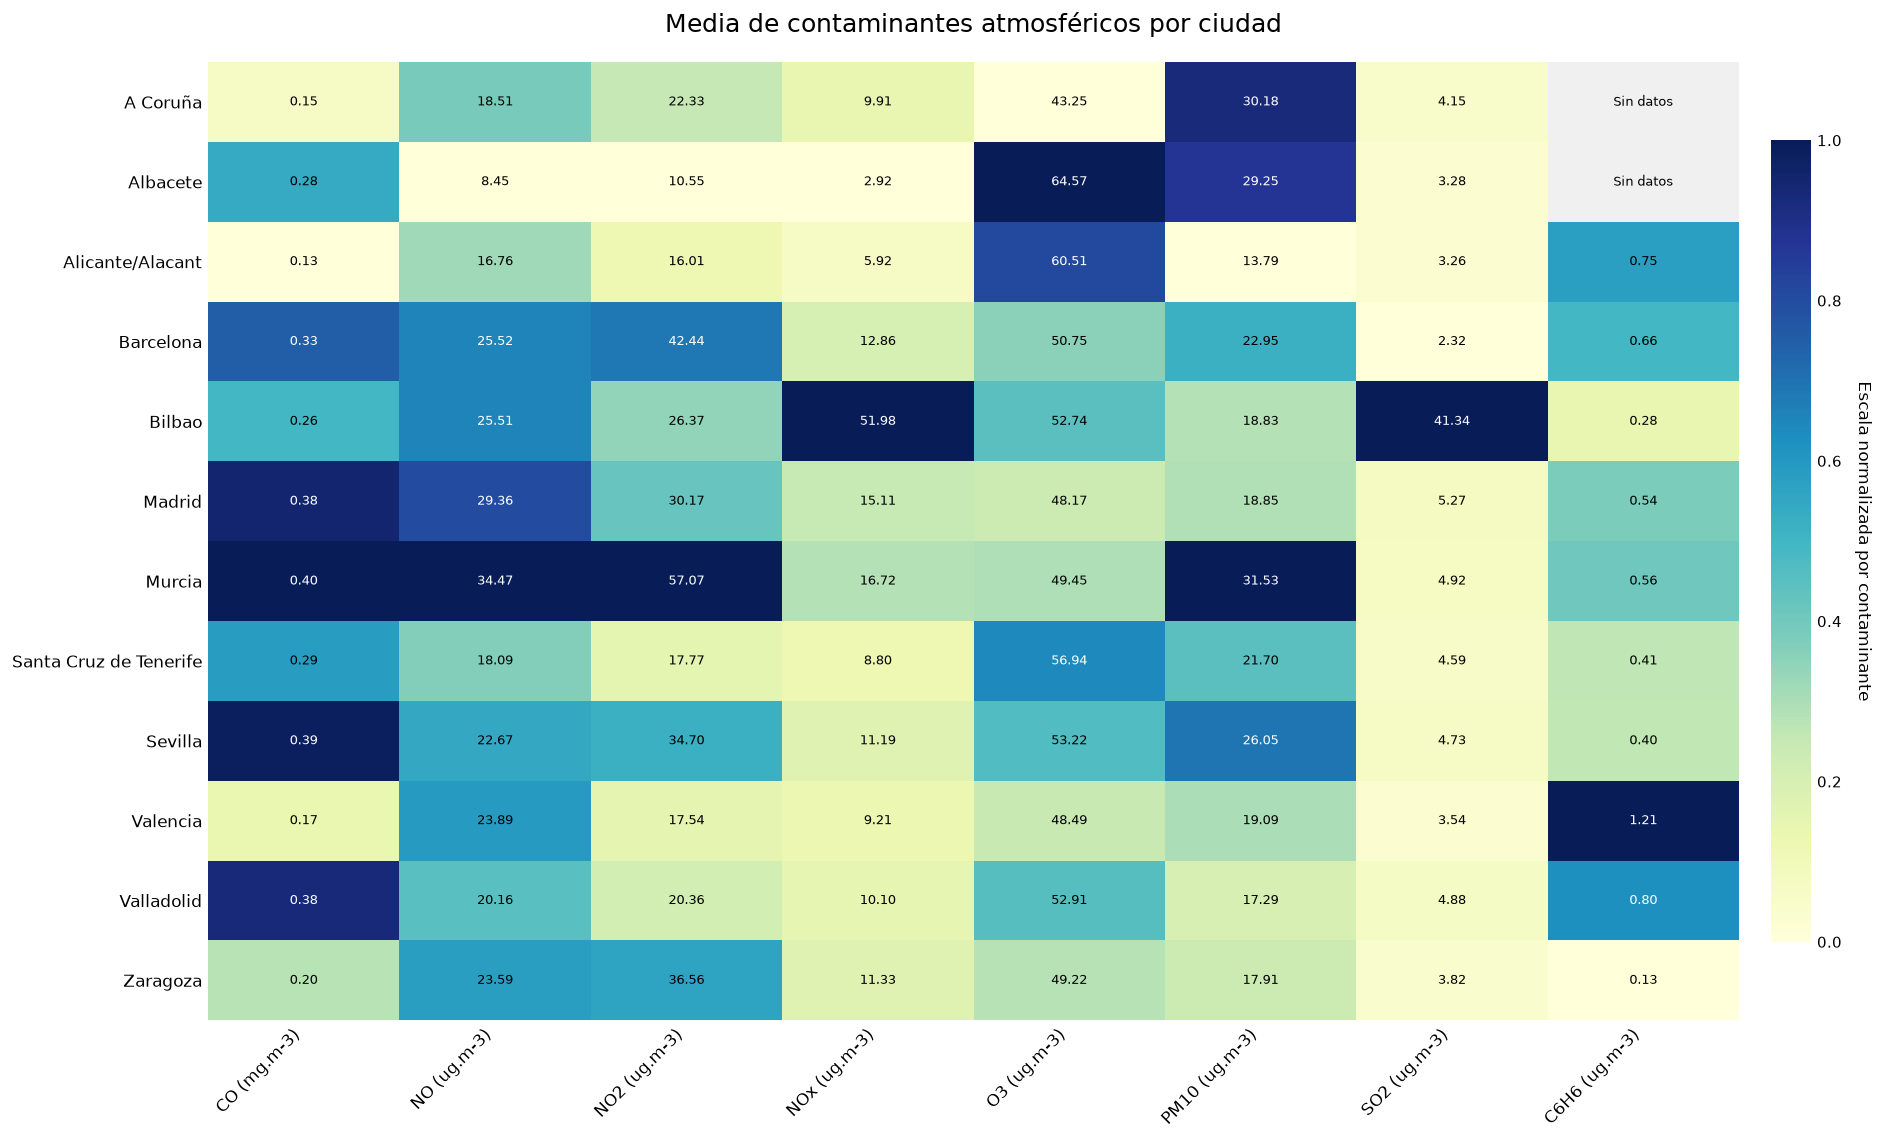

In [40]:
# -----------------------------------------------------------------------------
# 1. CARGA DEL DATASET
# -----------------------------------------------------------------------------

df = pd.read_csv(FOLDER_OUTPUT / "dataset_cont_clima_indices_limpio.csv")

# -----------------------------------------------------------------------------
# 2. CÁLCULO DE LA MEDIA DE CADA CONTAMINANTE POR CIUDAD
# -----------------------------------------------------------------------------

tabla_medias_contaminantes = (
    df
    .groupby("city")[columnas_contaminantes]
    .mean()
    .sort_index()
)


# -----------------------------------------------------------------------------
# 3. NORMALIZACIÓN POR CONTAMINANTE PARA EL COLOR
# -----------------------------------------------------------------------------

# Esta tabla solo se usa para colorear.
# Los valores reales que se escribirán en cada celda se toman de
# tabla_medias_contaminantes.

tabla_colores = tabla_medias_contaminantes.copy().astype(float)

for contaminante in tabla_colores.columns:

    serie = tabla_colores[contaminante]

    # Si no hay datos, dejamos la columna como NaN.
    if serie.notna().sum() == 0:
        tabla_colores[contaminante] = np.nan
        continue

    vmin = serie.min()
    vmax = serie.max()

    # Si todas las ciudades tienen el mismo valor medio,
    # asignamos un color intermedio.
    if vmin == vmax:
        tabla_colores[contaminante] = 0.5
    else:
        tabla_colores[contaminante] = (serie - vmin) / (vmax - vmin)


# -----------------------------------------------------------------------------
# 4. CONSTRUCCIÓN DEL MAPA DE CALOR
# -----------------------------------------------------------------------------

# Elegimos un mapa de color suave y claro.
cmap = plt.colormaps["YlGnBu"].copy()

# Color para celdas sin datos.
cmap.set_bad(color="#f0f0f0")

# Convertimos la tabla de colores a matriz enmascarada para que los NaN
# se pinten con el color definido en set_bad.
matriz_colores = np.ma.masked_invalid(tabla_colores.values)

fig, ax = plt.subplots(
    figsize=(1.35 * len(tabla_medias_contaminantes.columns) + 5,
             0.55 * len(tabla_medias_contaminantes.index) + 3)
)

fig.patch.set_facecolor("white")

im = ax.imshow(
    matriz_colores,
    aspect="auto",
    cmap=cmap,
    vmin=0,
    vmax=1,
    interpolation="nearest"
)

# Quitamos cuadrícula.
ax.grid(False)

# Etiquetas del eje X: contaminantes.
ax.set_xticks(np.arange(len(tabla_medias_contaminantes.columns)))
ax.set_xticklabels(
    tabla_medias_contaminantes.columns,
    rotation=45,
    ha="right",
    fontsize=10
)

# Etiquetas del eje Y: ciudades.
ax.set_yticks(np.arange(len(tabla_medias_contaminantes.index)))
ax.set_yticklabels(
    tabla_medias_contaminantes.index,
    fontsize=10
)

# Quitamos marcas de los ejes.
ax.tick_params(axis="both", length=0)

# Quitamos bordes.
for spine in ax.spines.values():
    spine.set_visible(False)

# Título.
ax.set_title(
    "Media de contaminantes atmosféricos por ciudad",
    fontsize=15,
    pad=18
)


# -----------------------------------------------------------------------------
# 5. AÑADIMOS LOS VALORES REALES DENTRO DE CADA CELDA
# -----------------------------------------------------------------------------

for i in range(tabla_medias_contaminantes.shape[0]):
    for j in range(tabla_medias_contaminantes.shape[1]):

        valor_real = tabla_medias_contaminantes.iloc[i, j]
        valor_color = tabla_colores.iloc[i, j]

        if pd.isna(valor_real):
            texto = "Sin datos"
            color_texto = "black"
        else:
            texto = f"{valor_real:.2f}"

            # Si el fondo es más oscuro, usamos texto blanco.
            if pd.isna(valor_color):
                color_texto = "black"
            elif valor_color > 0.62:
                color_texto = "white"
            else:
                color_texto = "black"

        ax.text(
            j,
            i,
            texto,
            ha="center",
            va="center",
            fontsize=8,
            color=color_texto
        )


# -----------------------------------------------------------------------------
# 8. BARRA DE COLOR
# -----------------------------------------------------------------------------

cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.outline.set_visible(False)
cbar.ax.tick_params(labelsize=9, length=0)
cbar.ax.set_ylabel(
    "Escala normalizada por contaminante",
    rotation=270,
    labelpad=18
)

plt.tight_layout()


# -----------------------------------------------------------------------------
# 9. GUARDADO Y VISUALIZACIÓN
# -----------------------------------------------------------------------------

plt.savefig(
    FOLDER_FIGS / "heatmap_media_contaminantes_por_ciudad.png",
    bbox_inches="tight",
    dpi=180,
    facecolor="white"
)

plt.show()

En términos generales, observamos diferencias claras entre ciudades. 

1. Para el **CO**, las medias más elevadas aparecen en Murcia, Sevilla, Madrid y Valladolid, mientras que Alicante, A Coruña y Valencia presentan los valores medios más bajos. 

2. En el caso del **NO**, observamos las mayores concentraciones en Murcia, Barcelona, Madrid y Bilbao, mientras que Albacete presenta con diferencia la menor concentración.

3. Respecto al **NO2**, destacan Murcia, Barcelona, Sevilla y Zaragoza con valores medios superiores al resto. En cambio, ciudades como Albacete o Alicante presentan medias más reducidas.

4. El **NOx** muestra un comportamiento especialmente destacado en Bilbao, con una media muy superior al resto de ciudades. También Madrid y Murcia presentan valores relativamente altos. El resto de ciudades muestran medias más bajas para este contaminante.

5. En cuanto al **O3**, las medias más elevadas aparecen en Albacete, Alicante y Santa Cruz de Tenerife. El resto de ciudades presentan valores más o menos similares, pero menores a los de las 3 ciudades anteriores.

6. Para la **PM10**, apreciamos medias altas en Murcia, Albacete, Sevilla y A Coruña, mientras que Alicante presenta una media más reducida.

7. En el caso del **SO2**, destaca especialmente Bilbao, con una media muy superior a la del resto de ciudades. El resto de ciudades presentan valores mucho menores. 

8. Por último, en cuanto al **C6H6**, Valencia, Valladolid, Barcelona y Alicante muestran las medias más elevadas.

### **EVOLUCIÓN ANUAL MEDIA POR CONTAMINANTE**

Mostramos la evolución anual media de cada contaminante atmosférico entre 2013 y 2024 para las ciudades analizadas. Cada línea representa una ciudad, lo que permite comparar tanto la evolución temporal de cada contaminante como las diferencias entre áreas urbanas.

Generando gráfica para: CO (mg.m-3)


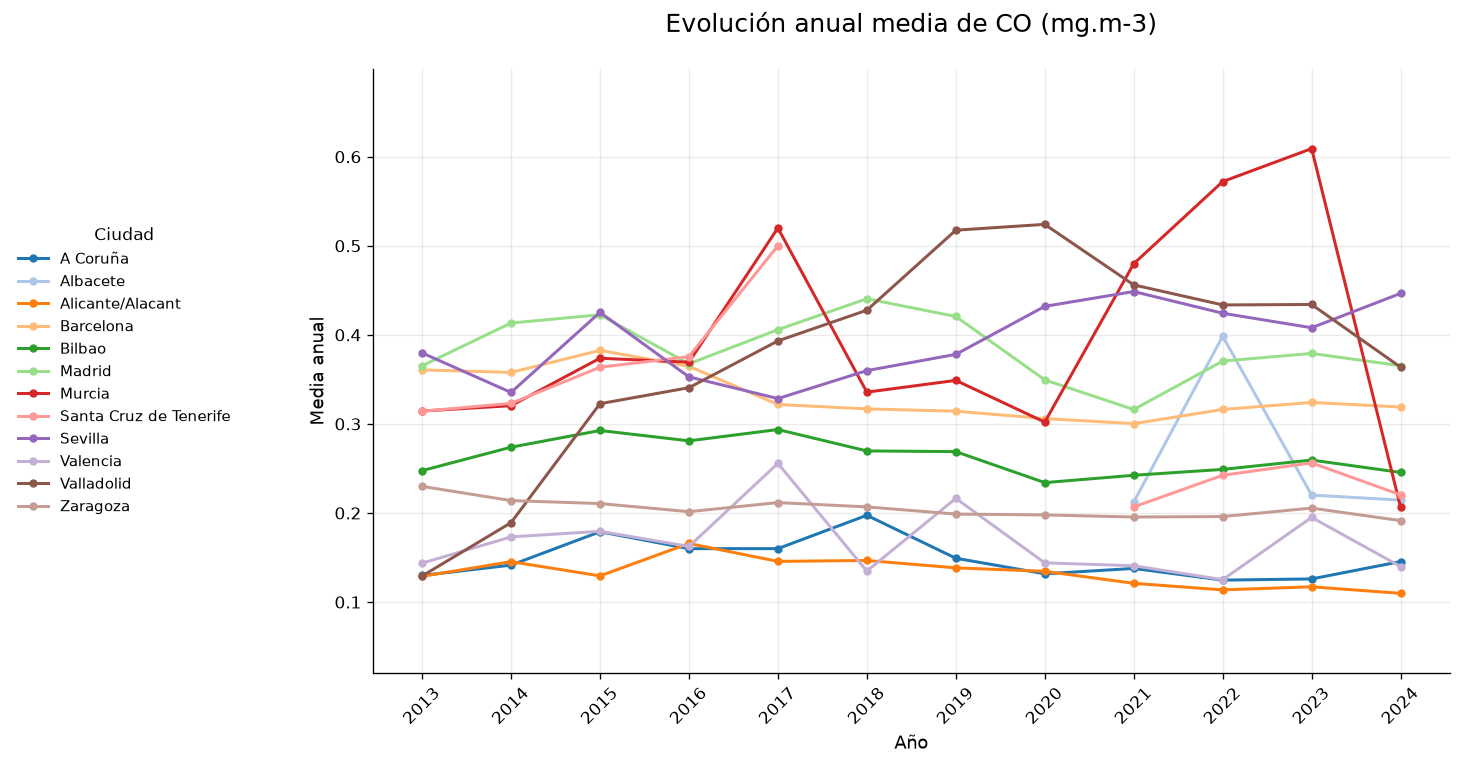

Generando gráfica para: NO (ug.m-3)


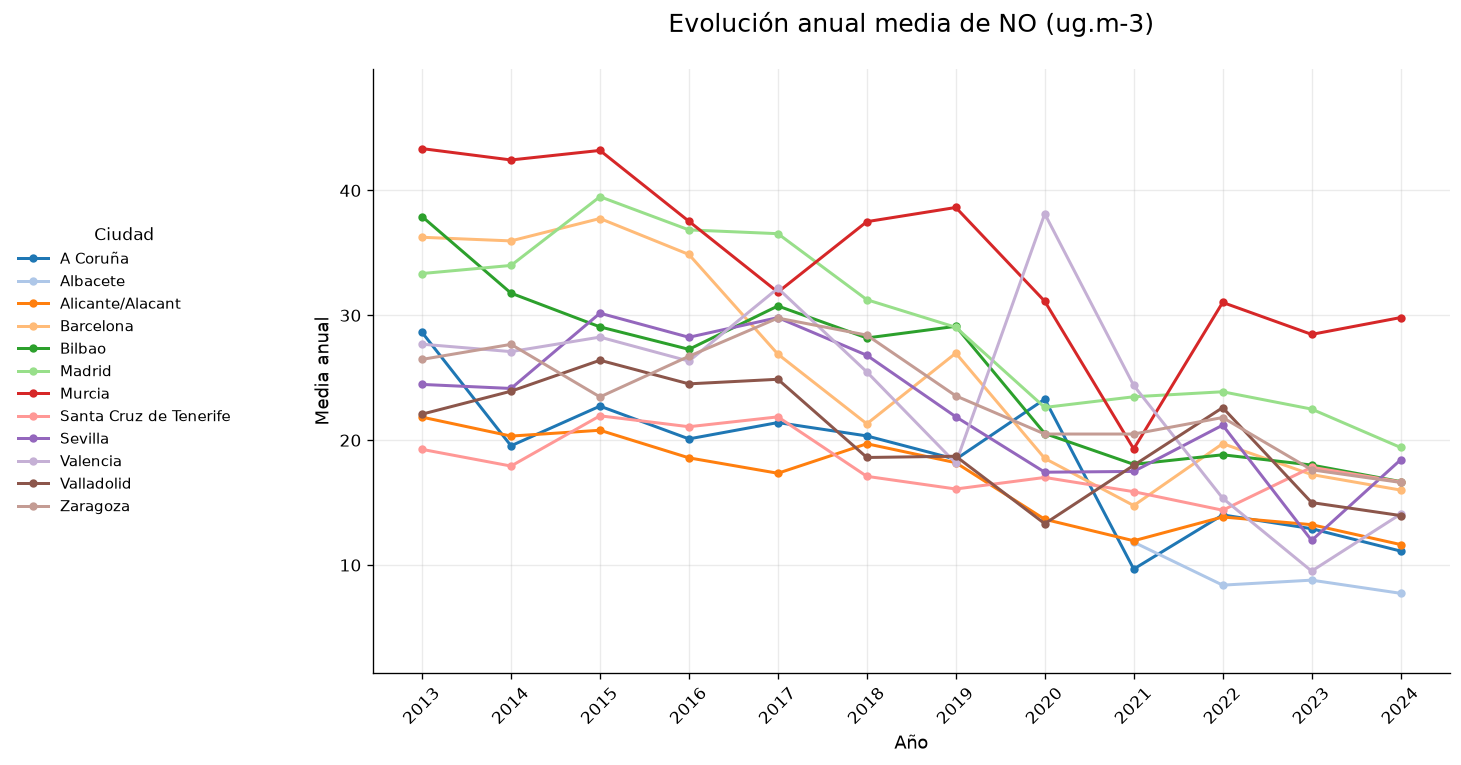

Generando gráfica para: NO2 (ug.m-3)


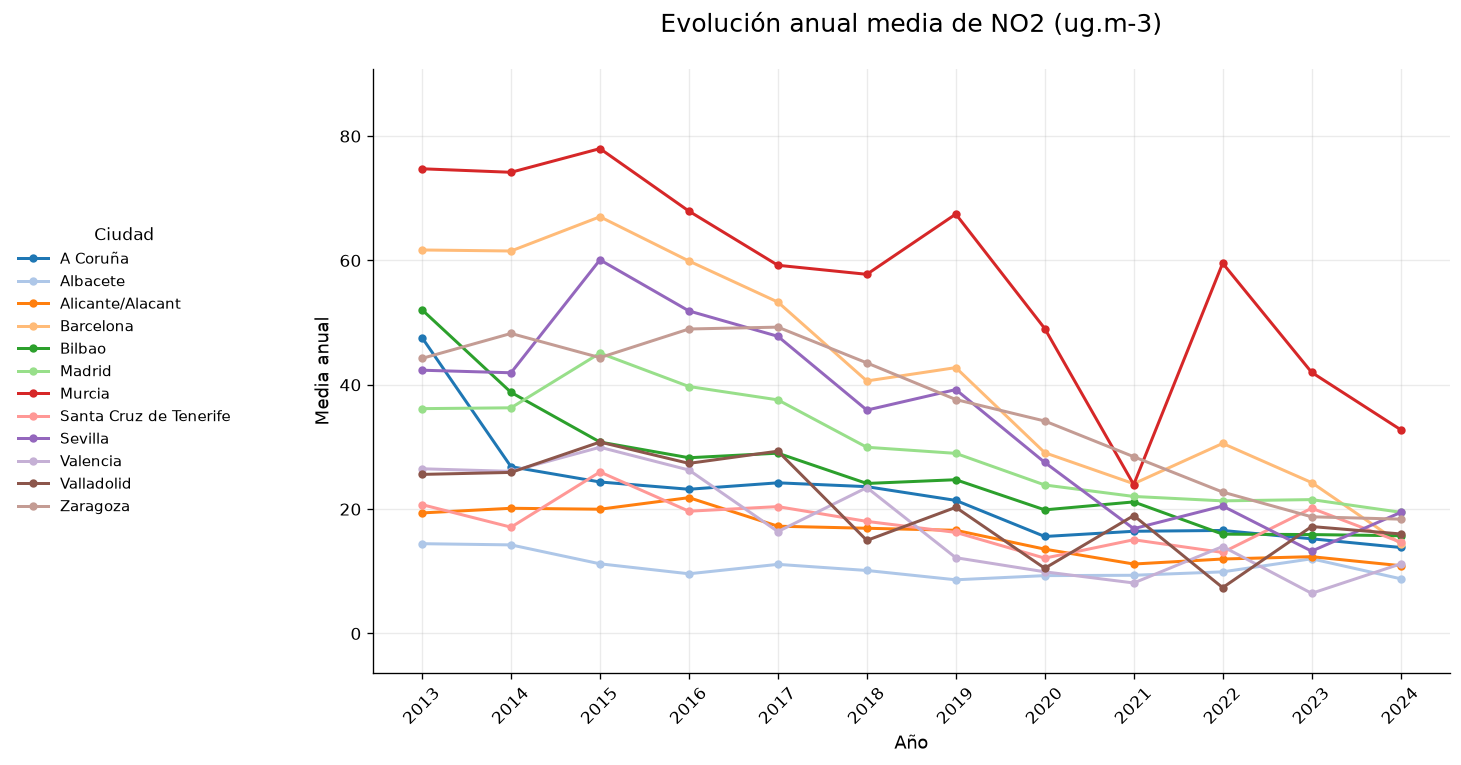

Generando gráfica para: NOx (ug.m-3)


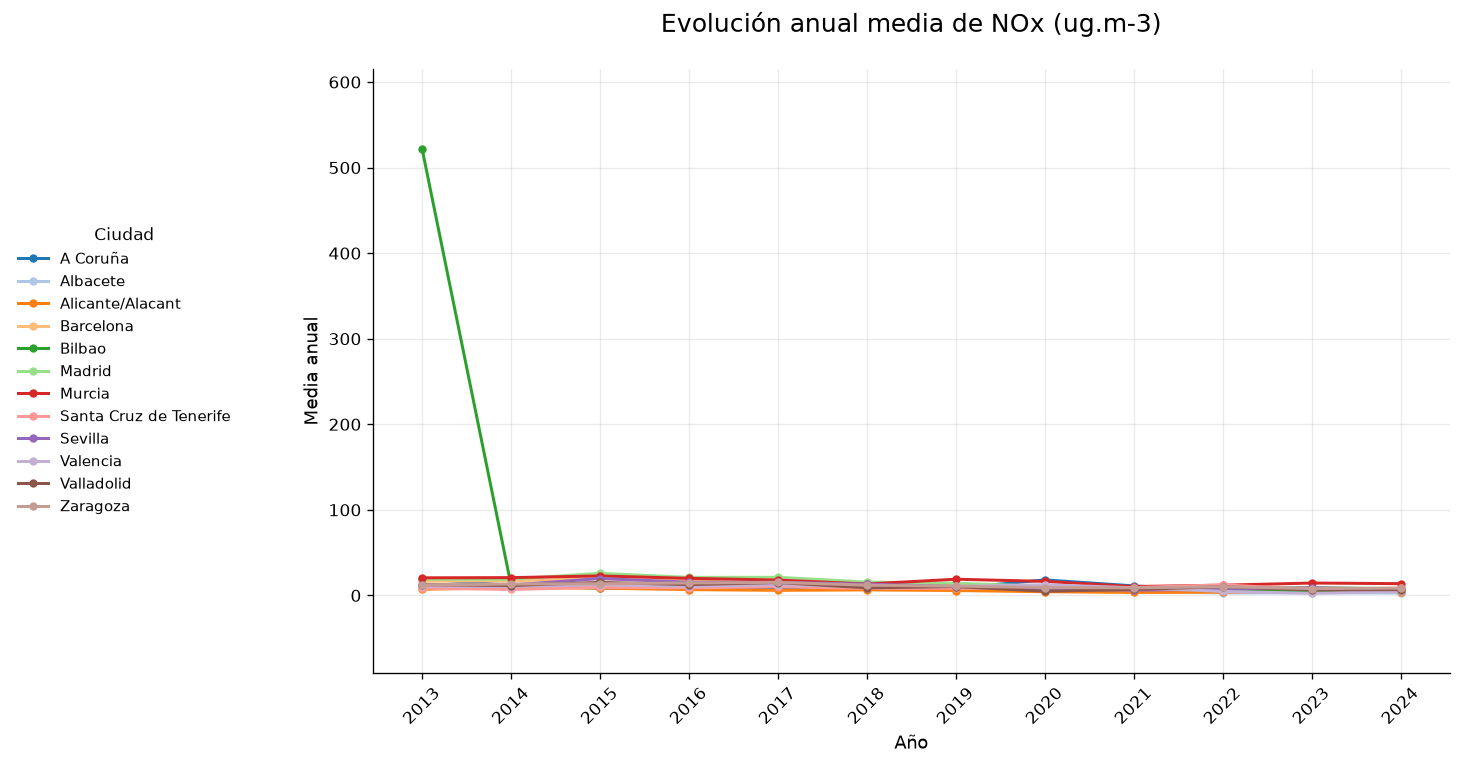

Generando gráfica para: O3 (ug.m-3)


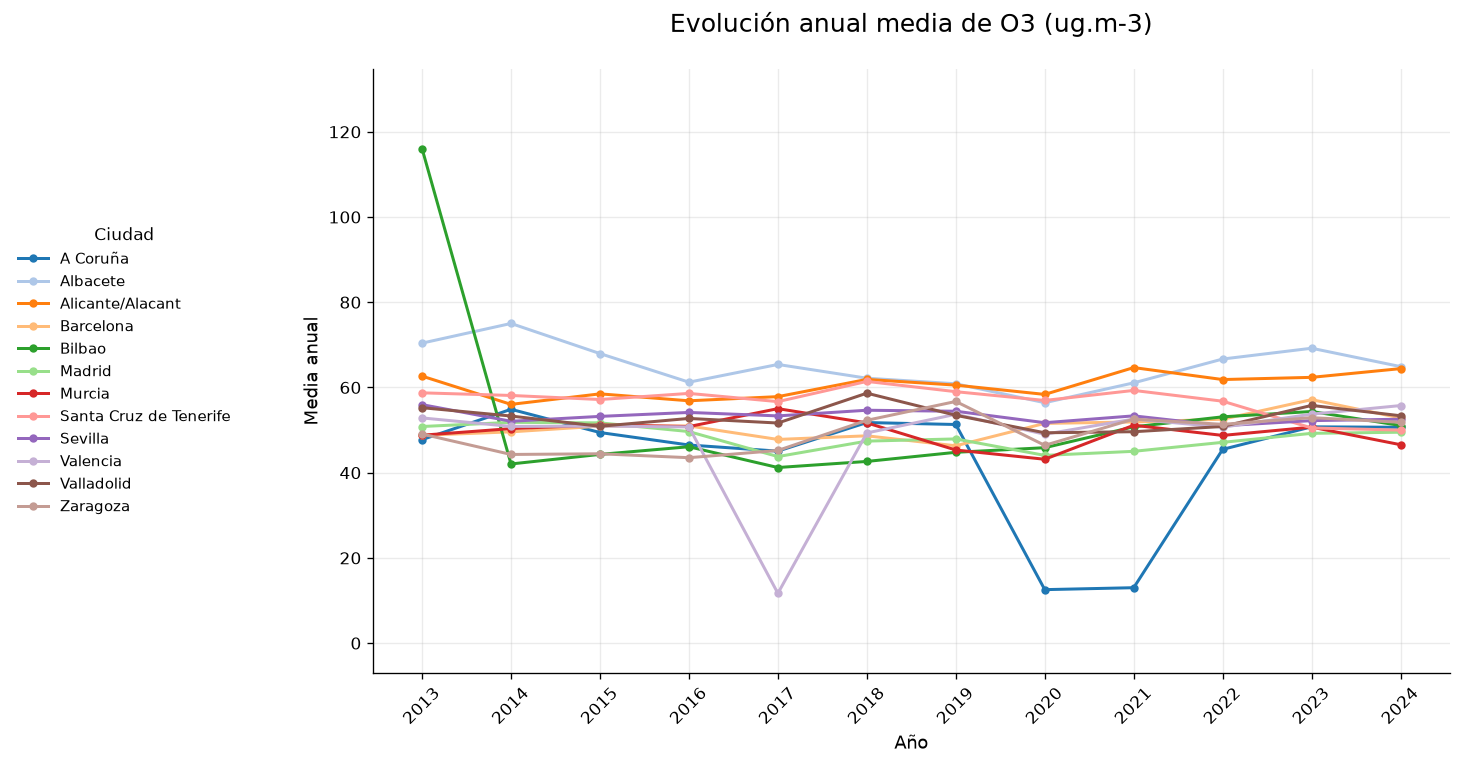

Generando gráfica para: PM10 (ug.m-3)


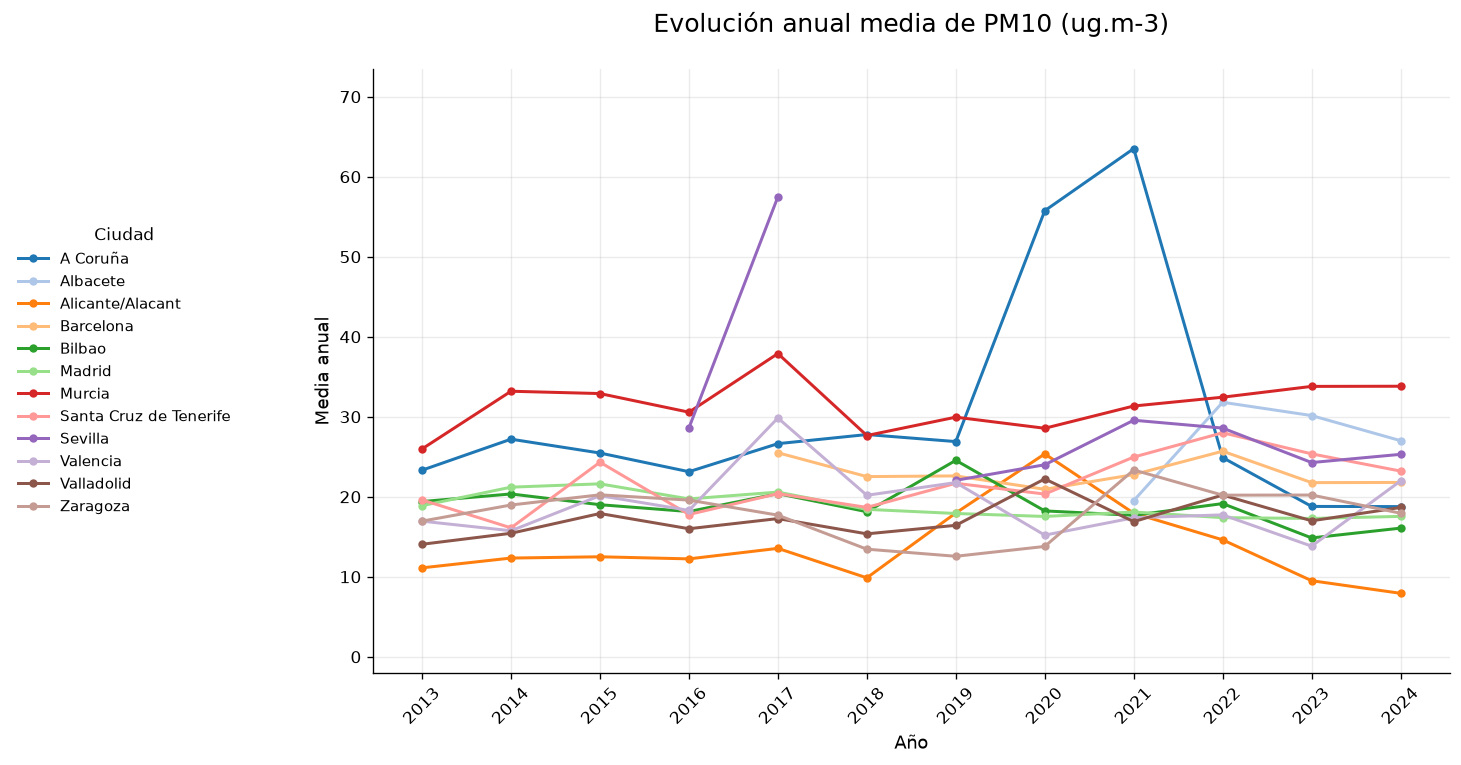

Generando gráfica para: SO2 (ug.m-3)


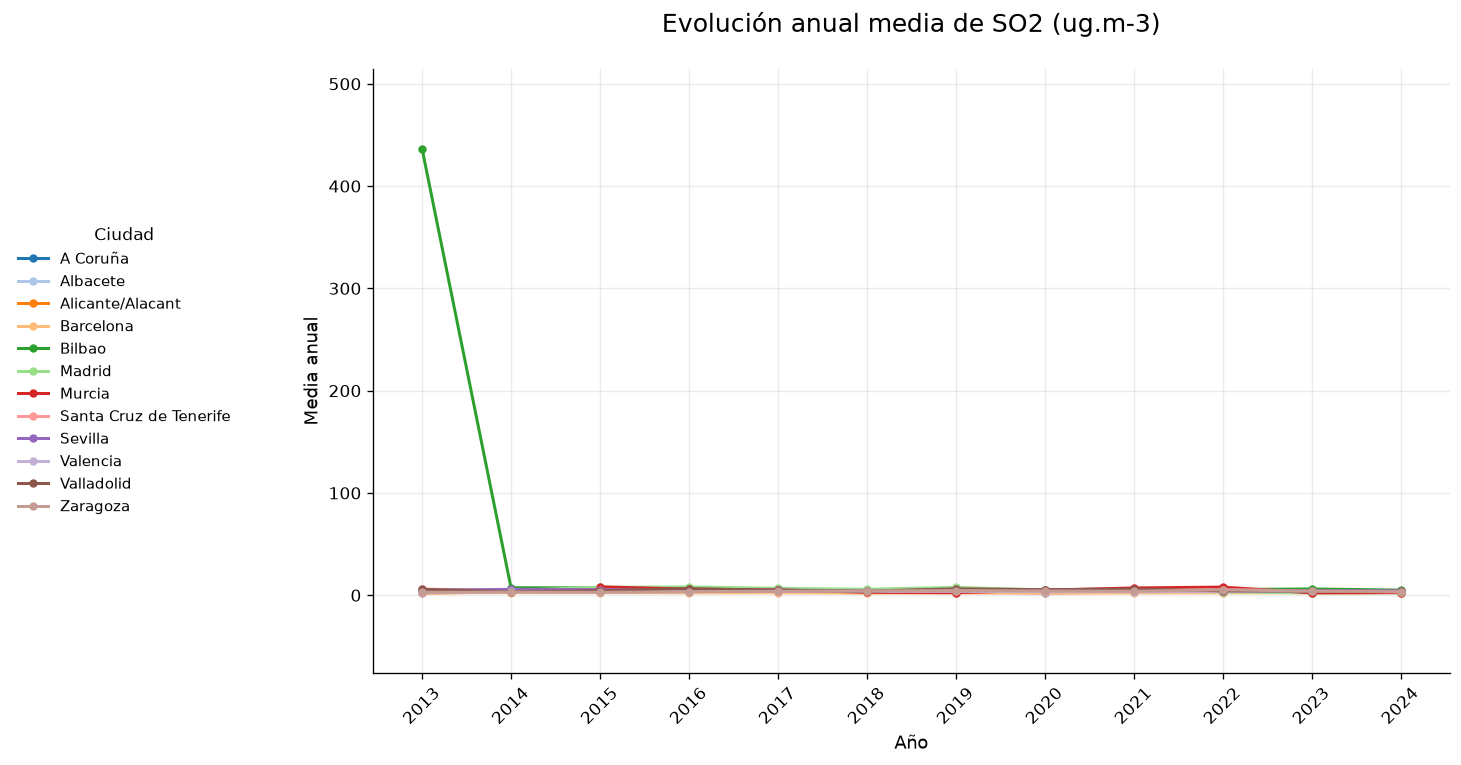

Generando gráfica para: C6H6 (ug.m-3)


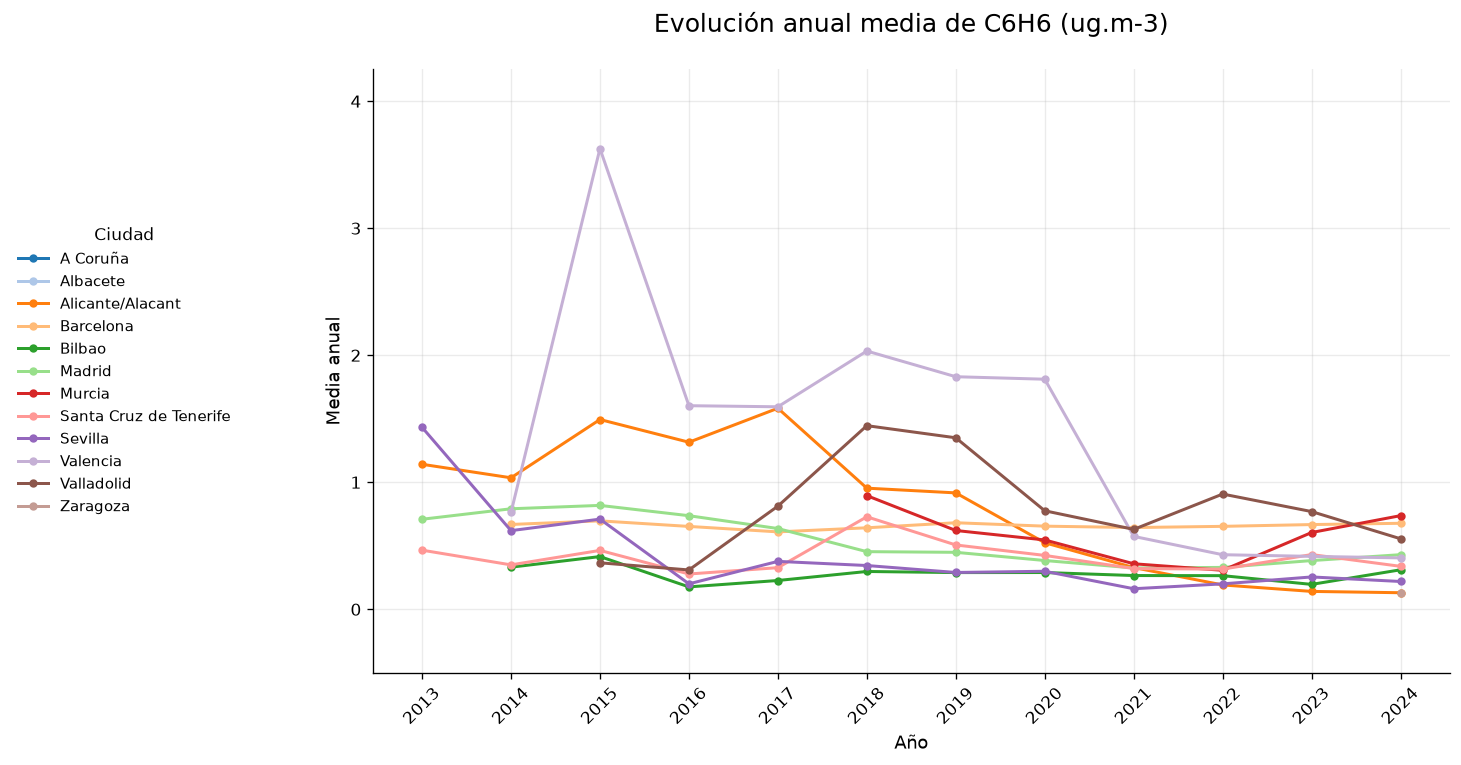

In [41]:
# -----------------------------------------------------------------------------
# 1. CÁLCULO DE LA MEDIA ANUAL POR CIUDAD Y CONTAMINANTE
# -----------------------------------------------------------------------------

df_media_anual = (
    df
    .groupby(["city", "Año"])[columnas_contaminantes]
    .mean()
    .reset_index()
)

ciudades_ordenadas = sorted(df_media_anual["city"].dropna().unique())
anios_ordenados = sorted(df_media_anual["Año"].dropna().unique())


# -----------------------------------------------------------------------------
# 2. COLORES CONSISTENTES POR CIUDAD
# -----------------------------------------------------------------------------

cmap_ciudades = plt.get_cmap("tab20")

colores_ciudades = {
    ciudad: cmap_ciudades(i)
    for i, ciudad in enumerate(ciudades_ordenadas)
}


# -----------------------------------------------------------------------------
# 3. FUNCIÓN PARA DAR MARGEN AL EJE Y
# -----------------------------------------------------------------------------

def obtener_limites_y_con_margen(serie, margen=0.15):
    """
    Calcula los límites del eje Y usando el mínimo y máximo reales,
    añadiendo margen arriba y abajo para que no se corten los extremos.
    """

    serie = pd.to_numeric(serie, errors="coerce").dropna()

    if len(serie) == 0:
        return None, None

    y_min = serie.min()
    y_max = serie.max()

    if y_min == y_max:
        delta = abs(y_min) * 0.1 if y_min != 0 else 1
        return y_min - delta, y_max + delta

    rango = y_max - y_min

    return y_min - margen * rango, y_max + margen * rango


# -----------------------------------------------------------------------------
# 4. GENERACIÓN DE UNA GRÁFICA POR CONTAMINANTE
# -----------------------------------------------------------------------------

for contaminante in columnas_contaminantes:

    print(f"Generando gráfica para: {contaminante}")

    fig, ax = plt.subplots(figsize=(13, 7))

    fig.patch.set_facecolor("white")

    df_plot = df_media_anual[["city", "Año", contaminante]].copy()

    # -------------------------------------------------------------------------
    # Dibujamos una línea por ciudad
    # -------------------------------------------------------------------------

    for ciudad in ciudades_ordenadas:

        df_ciudad = (
            df_plot[df_plot["city"] == ciudad]
            .sort_values("Año")
        )

        ax.plot(
            df_ciudad["Año"],
            df_ciudad[contaminante],
            marker="o",
            linewidth=1.8,
            markersize=4,
            color=colores_ciudades[ciudad],
            label=ciudad
        )

    # -------------------------------------------------------------------------
    # Título y etiquetas
    # -------------------------------------------------------------------------

    ax.set_title(
        f"Evolución anual media de {contaminante}",
        fontsize=15,
        pad=22
    )

    ax.set_xlabel("Año", fontsize=11)
    ax.set_ylabel("Media anual", fontsize=11)

    # -------------------------------------------------------------------------
    # Formato de ejes
    # -------------------------------------------------------------------------

    ax.set_xticks(anios_ordenados)
    ax.tick_params(axis="x", rotation=45, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)

    ax.grid(True, alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # -------------------------------------------------------------------------
    # Margen del eje Y para que no se salga por arriba
    # -------------------------------------------------------------------------

    y_min, y_max = obtener_limites_y_con_margen(
        df_plot[contaminante],
        margen=0.18
    )

    if y_min is not None and y_max is not None:
        ax.set_ylim(y_min, y_max)

    # -------------------------------------------------------------------------
    # Leyenda / índice de ciudades a la izquierda
    # -------------------------------------------------------------------------

    ax.legend(
        loc="center right",
        bbox_to_anchor=(-0.12, 0.5),
        frameon=False,
        title="Ciudad",
        fontsize=9,
        title_fontsize=10
    )

    # -------------------------------------------------------------------------
    # Ajuste manual de márgenes
    # -------------------------------------------------------------------------

    plt.subplots_adjust(
        left=0.28,
        right=0.97,
        top=0.88,
        bottom=0.16
    )

    # -----------------------------------------------------------------------------
    # Guardado
    # -----------------------------------------------------------------------------

    nombre_limpio = normalizar_texto(contaminante)

    # Define la ruta del directorio de destino
    ruta_destino = FOLDER_FIGS / "estacionalidad anual"

    # Crea la carpeta y subcarpetas si no existen
    ruta_destino.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        ruta_destino / f"evolucion_anual_media_{nombre_limpio}.png",
        bbox_inches="tight",
        dpi=180,
        facecolor="white"
    )

    plt.show()

Generando gráfica para: NOx (ug.m-3)


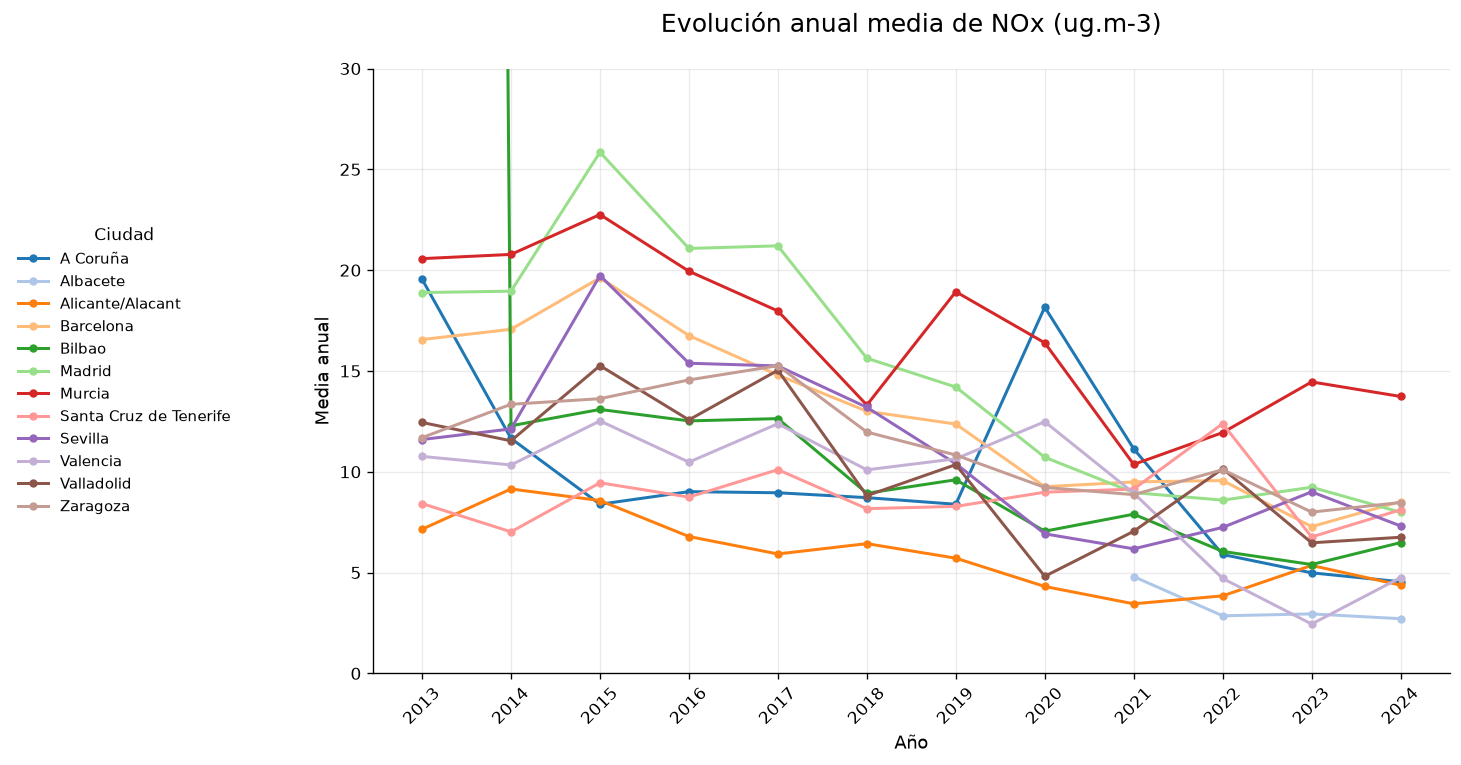

Generando gráfica para: SO2 (ug.m-3)


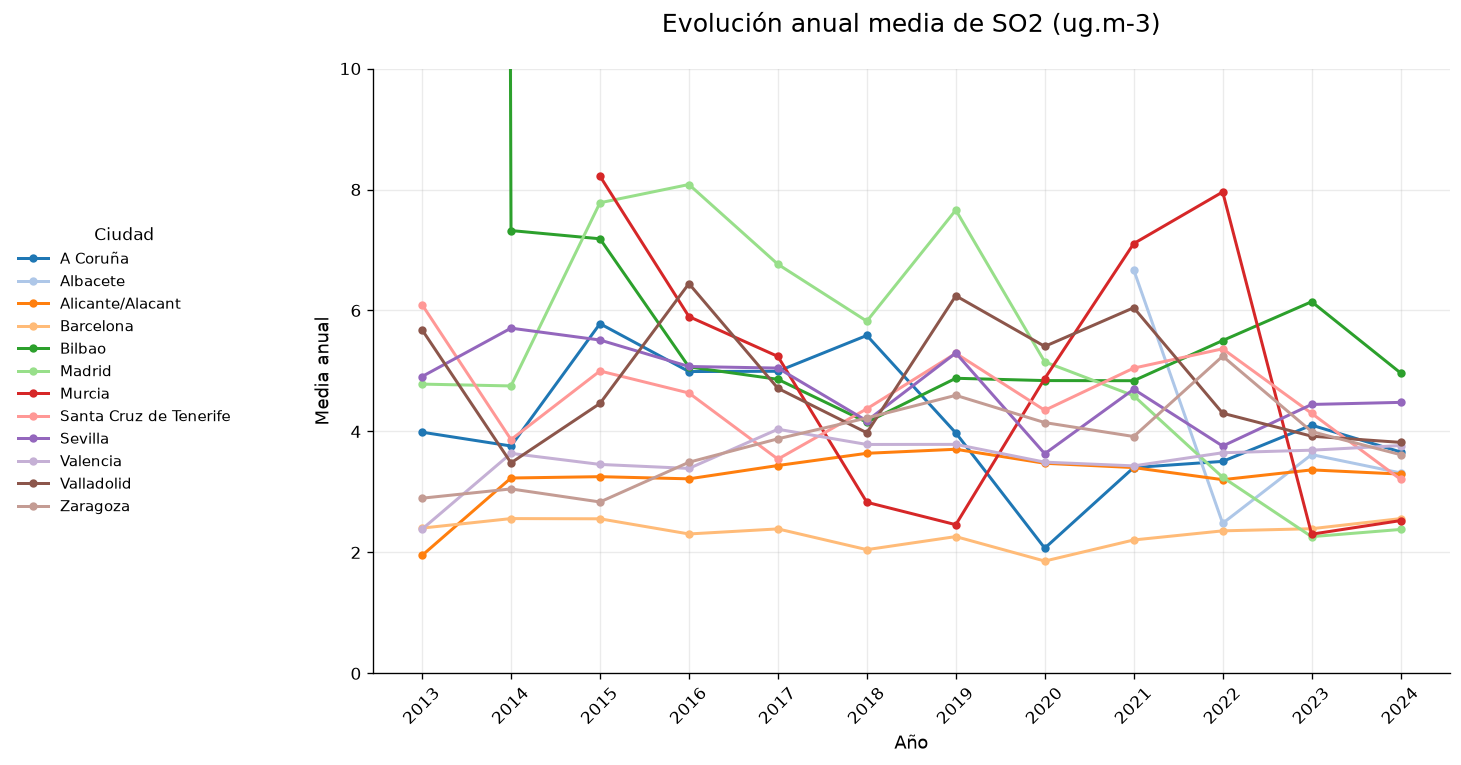

In [42]:
# =============================================================================
# EVOLUCIÓN ANUAL MEDIA SOLO PARA NOx Y SO2
# NOx: RANGO 0-30
# SO2: RANGO 0-10
# =============================================================================

# En esta celda generamos únicamente dos gráficas:
# - NOx (ug.m-3), con eje Y entre 0 y 30
# - SO2 (ug.m-3), con eje Y entre 0 y 10
#
# En ambas:
# - Eje X: año
# - Eje Y: media anual
# - Una línea por ciudad

# -----------------------------------------------------------------------------
# 1. CONTAMINANTES A REPRESENTAR
# -----------------------------------------------------------------------------

contaminantes_objetivo = [
    "NOx (ug.m-3)",
    "SO2 (ug.m-3)"
]


# -----------------------------------------------------------------------------
# 42 CÁLCULO DE LA MEDIA ANUAL POR CIUDAD Y CONTAMINANTE
# -----------------------------------------------------------------------------

df_media_anual = (
    df
    .groupby(["city", "Año"])[contaminantes_objetivo]
    .mean()
    .reset_index()
)

ciudades_ordenadas = sorted(df_media_anual["city"].dropna().unique())
anios_ordenados = sorted(df_media_anual["Año"].dropna().unique())


# -----------------------------------------------------------------------------
# 3. COLORES CONSISTENTES POR CIUDAD
# -----------------------------------------------------------------------------

cmap_ciudades = plt.get_cmap("tab20")

colores_ciudades = {
    ciudad: cmap_ciudades(i)
    for i, ciudad in enumerate(ciudades_ordenadas)
}


# -----------------------------------------------------------------------------
# 4. GENERACIÓN DE UNA FIGURA POR CONTAMINANTE
# -----------------------------------------------------------------------------

for contaminante in contaminantes_objetivo:

    print(f"Generando gráfica para: {contaminante}")

    fig, ax = plt.subplots(figsize=(13, 7))
    fig.patch.set_facecolor("white")

    df_plot = df_media_anual[["city", "Año", contaminante]].copy()

    for ciudad in ciudades_ordenadas:

        df_ciudad = (
            df_plot[df_plot["city"] == ciudad]
            .sort_values("Año")
        )

        ax.plot(
            df_ciudad["Año"],
            df_ciudad[contaminante],
            marker="o",
            linewidth=1.8,
            markersize=4,
            color=colores_ciudades[ciudad],
            label=ciudad
        )

    # Título y etiquetas
    ax.set_title(
        f"Evolución anual media de {contaminante}",
        fontsize=15,
        pad=22
    )

    ax.set_xlabel("Año", fontsize=11)
    ax.set_ylabel("Media anual", fontsize=11)

    # Eje X
    ax.set_xticks(anios_ordenados)
    ax.tick_params(axis="x", rotation=45, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)

    # Eje Y específico según contaminante
    if contaminante == "NOx (ug.m-3)":
        ax.set_ylim(0, 30)

    elif contaminante == "SO2 (ug.m-3)":
        ax.set_ylim(0, 10)

    # Rejilla y bordes
    ax.grid(True, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Leyenda a la izquierda
    ax.legend(
        loc="center right",
        bbox_to_anchor=(-0.12, 0.5),
        frameon=False,
        title="Ciudad",
        fontsize=9,
        title_fontsize=10
    )

    # Ajuste de márgenes
    plt.subplots_adjust(
        left=0.28,
        right=0.97,
        top=0.88,
        bottom=0.16
    )

    # Guardado
    nombre_limpio = normalizar_texto(contaminante)

    # Define la ruta del directorio de destino
    ruta_destino = FOLDER_FIGS / "estacionalidad anual"

    # Crea la carpeta y subcarpetas si no existen
    ruta_destino.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        ruta_destino / f"evolucion_anual_media_{nombre_limpio}(1).png",
        bbox_inches="tight",
        dpi=180,
        facecolor="white"
    )

    plt.show()

En primer lugar, observamos que los contaminantes asociados principalmente a procesos de combustión y tráfico urbano, como **NO**, **NO2** y **NOx**, presentan una tendencia descendente para todas las ciudades a lo largo del periodo de estudio. Para el contaminante NOx, destaca el año 2014, donde hubo una concentración desmesurada y muy superior a la norma.

En el caso del **CO**, las medias anuales muestran una evolución más heterogénea. Algunas ciudades presentan niveles relativamente estables, mientras que otras muestran incrementos puntuales en determinados años, como Sevilla en 2015, Murcia en 2017 y 2023, Valencia en 2017, 2019 y 2023 y Albacete en 2023. Además, a diferencia del resto, Valladolid muestra una tendencia creciente con los años.

Para el **O3**, sus valores medios anuales son más estables en la mayoría de ciudades. No obstante, observamos un pico alto para Bilbao en 2013 y valores muy inferiores a los usuales para Valencia en 2017 y A Coruña en 2020 y 2021.

En el caso de **PM10**, también observamos valores relativamente estables a lo largo de los años. Sin embargo, algunas series presentan picos bien pronunciados, como Sevilla en 2017, A Coruña en 2020 y 2021, Alicante en 2020 o Valencia en 2017.

Para **SO2**, observamos que por ciudades no se sigue un patrón claro. Hay ciudades con valores estables durante el tiempo, como Barcelona y Alicante; ciudades que comienzan con una tendencia descendiente para pasar a una ascendente, como Murcia o Bilbao (que presenta un pico altísimo en 2013); o ciudades que no siguen ningún patrón, que son el resto de ciudades.

Por último, el **C6H6** presenta valores medios generalmente bajos y una tendencia ligeramente descendente, especialmente a partir de los años centrales del periodo.

### **EVOLUCIÓN MENSUAL MEDIA POR CONTAMINANTE**

Analizamos el patrón mensual medio de cada contaminante atmosférico para las ciudades elegidas. Cada línea representa una ciudad y permite observar cómo varía la concentración media de cada contaminante a lo largo de los meses del año.

Generando gráfica mensual para: CO (mg.m-3)


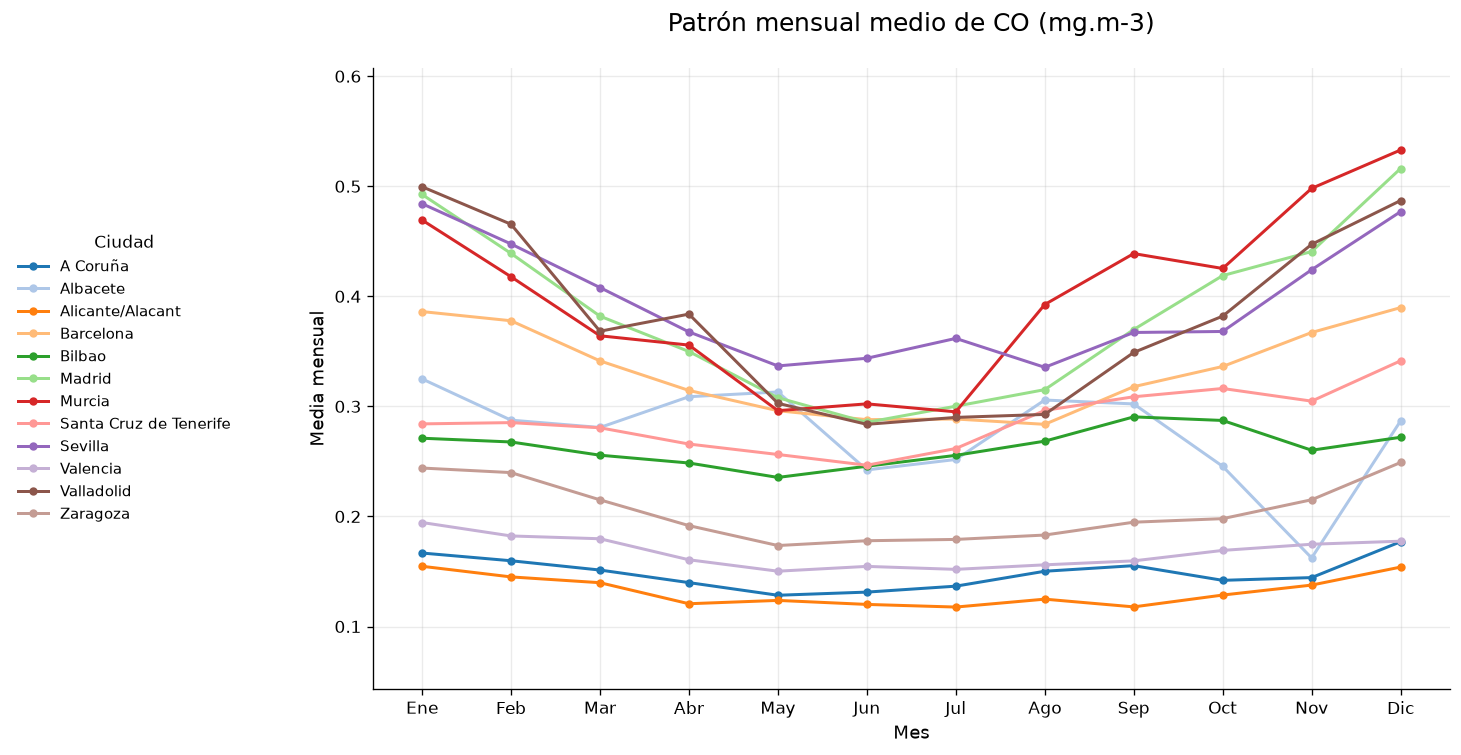

Generando gráfica mensual para: NO (ug.m-3)


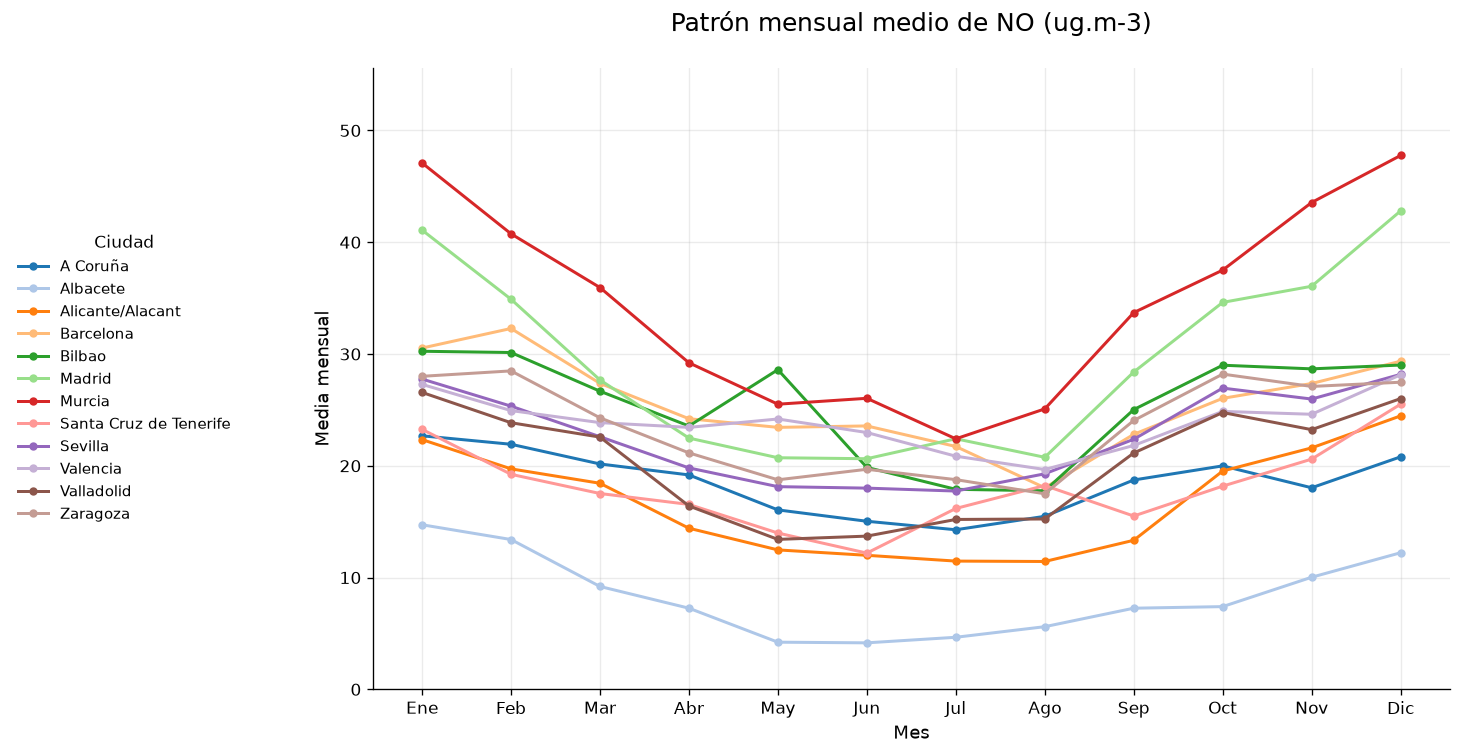

Generando gráfica mensual para: NO2 (ug.m-3)


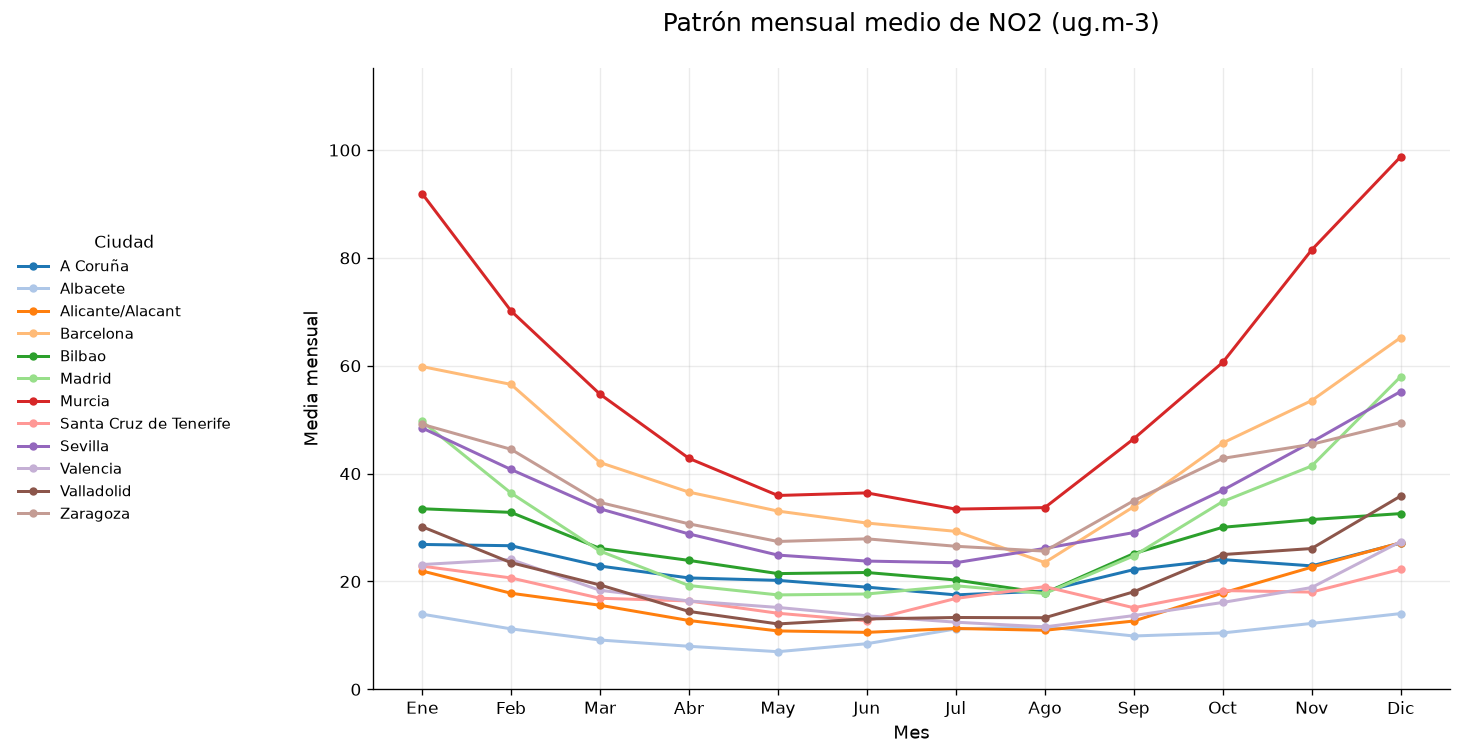

Generando gráfica mensual para: NOx (ug.m-3)


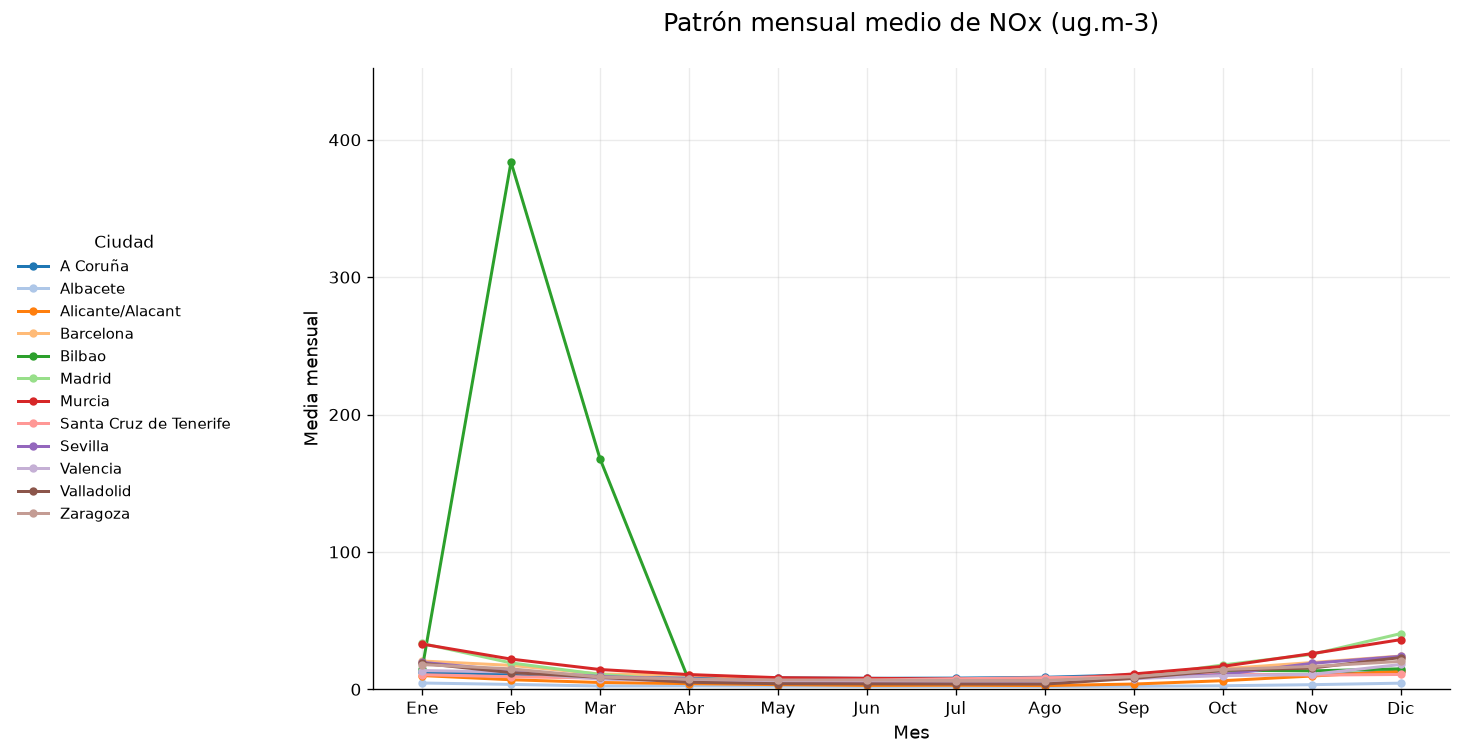

Generando gráfica mensual para: O3 (ug.m-3)


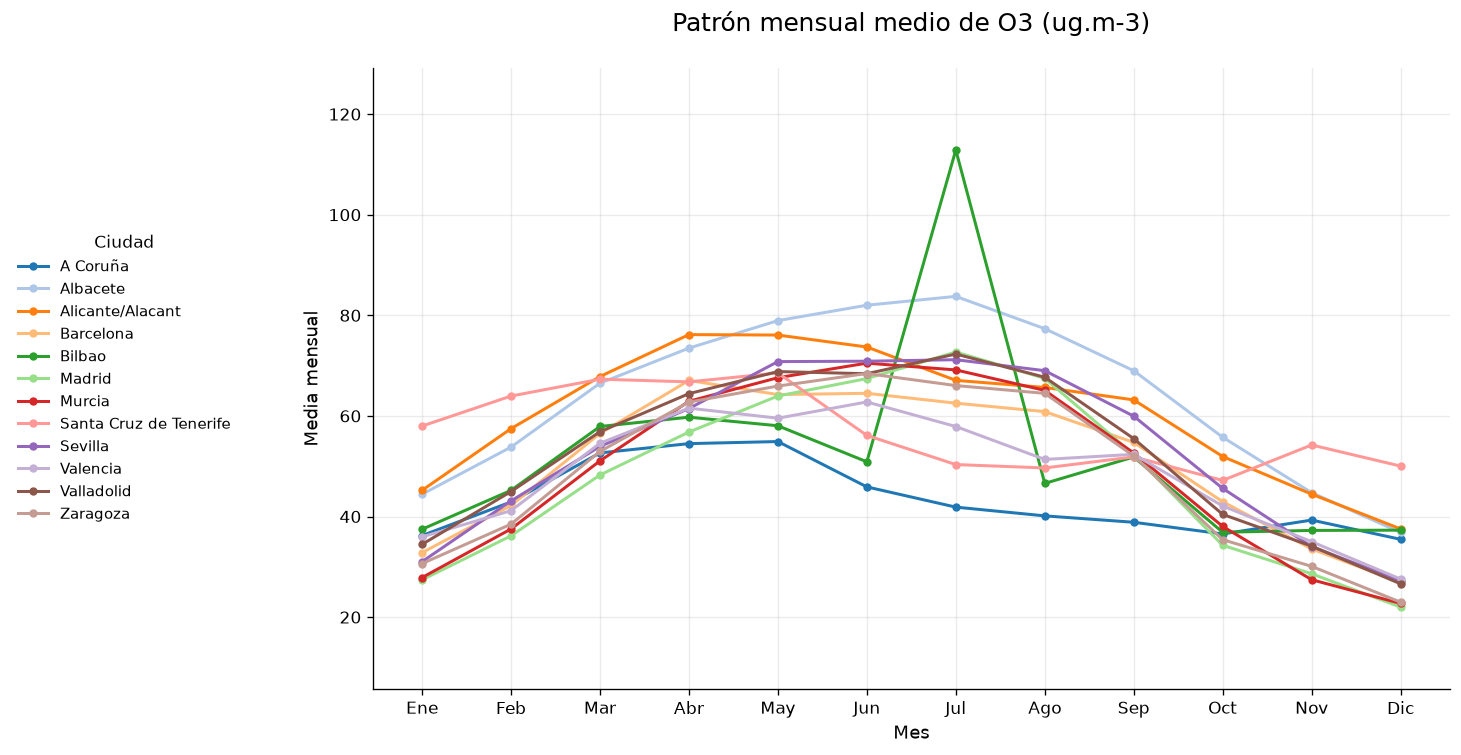

Generando gráfica mensual para: PM10 (ug.m-3)


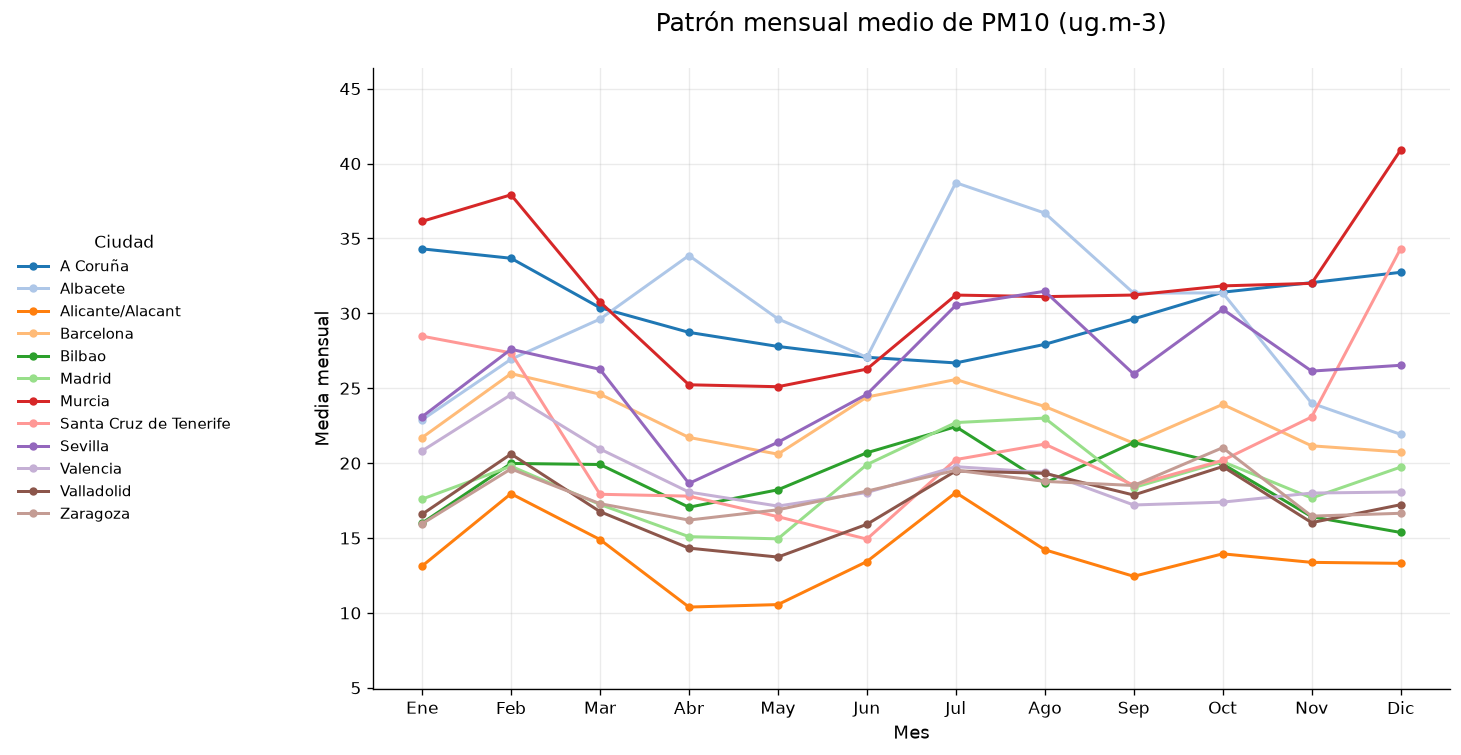

Generando gráfica mensual para: SO2 (ug.m-3)


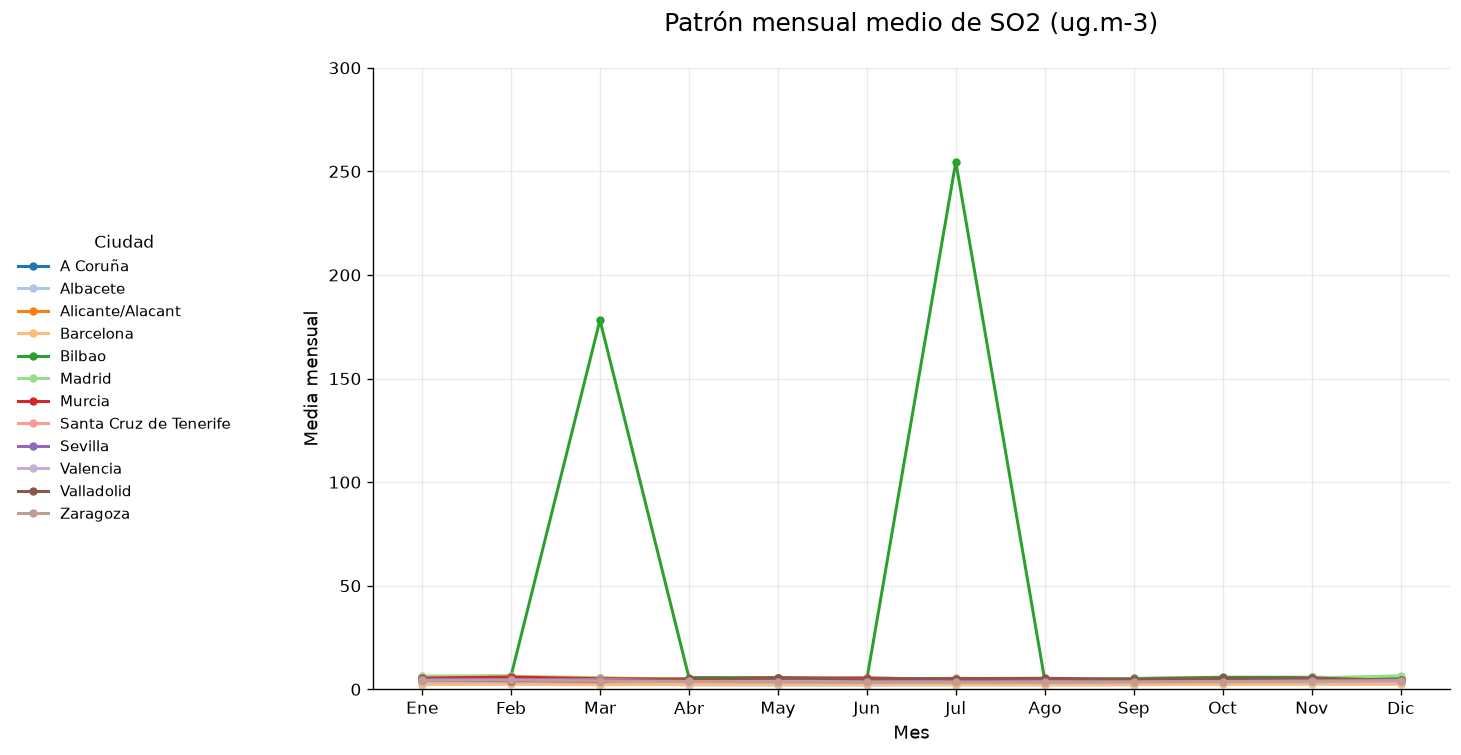

Generando gráfica mensual para: C6H6 (ug.m-3)


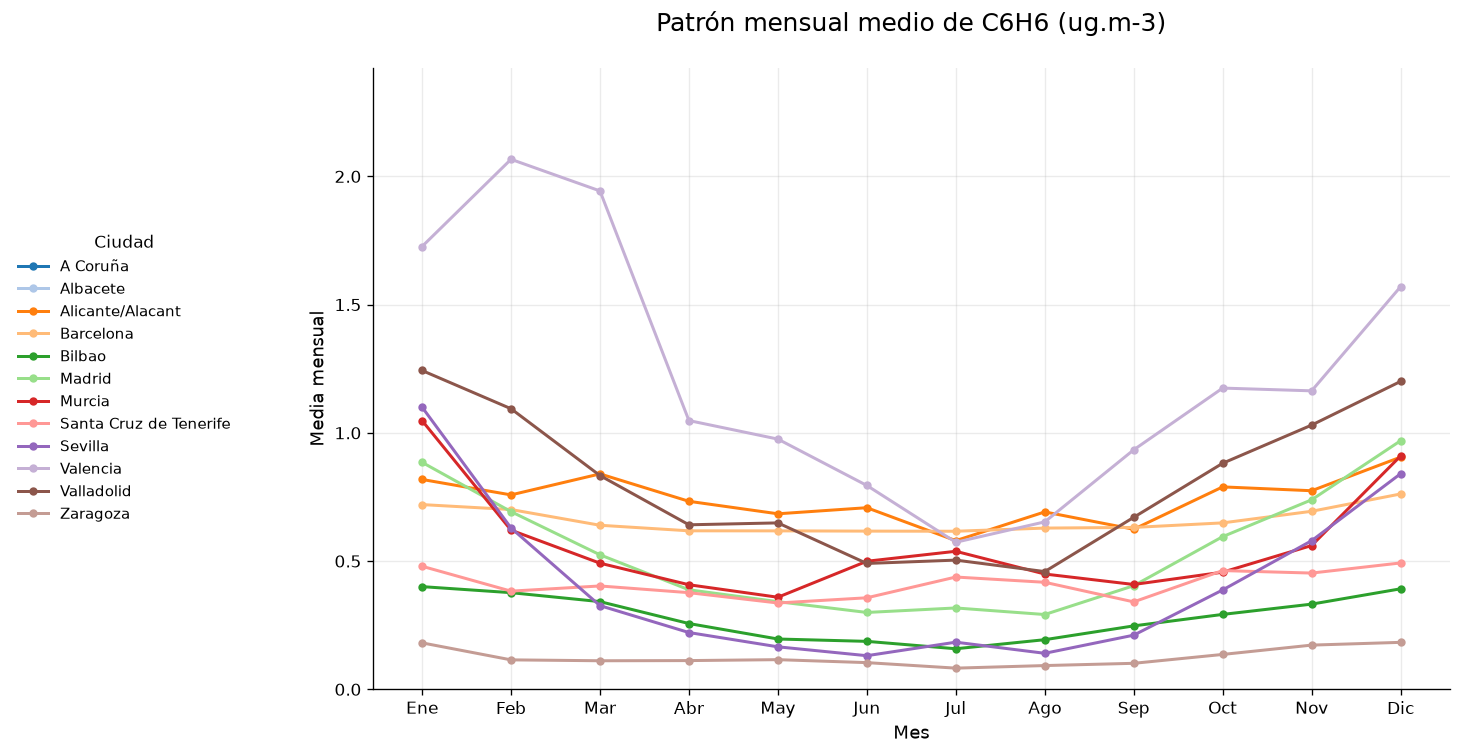

In [43]:
# -----------------------------------------------------------------------------
# 1. CÁLCULO DE LA MEDIA MENSUAL POR CIUDAD Y CONTAMINANTE
# -----------------------------------------------------------------------------

df_media_mensual = (
    df
    .groupby(["city", "Mes"])[columnas_contaminantes]
    .mean()
    .reset_index()
)

ciudades_ordenadas = sorted(df_media_mensual["city"].dropna().unique())

meses_ordenados = list(range(1, 13))

nombres_meses = [
    "Ene", "Feb", "Mar", "Abr", "May", "Jun",
    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"
]


# -----------------------------------------------------------------------------
# 2. COLORES CONSISTENTES POR CIUDAD
# -----------------------------------------------------------------------------

cmap_ciudades = plt.get_cmap("tab20")

colores_ciudades = {
    ciudad: cmap_ciudades(i)
    for i, ciudad in enumerate(ciudades_ordenadas)
}


# -----------------------------------------------------------------------------
# 3. FUNCIÓN PARA DAR MARGEN AL EJE Y
# -----------------------------------------------------------------------------

def obtener_limites_y_con_margen(serie, margen=0.15):
    """
    Calcula los límites del eje Y usando el mínimo y máximo reales,
    añadiendo margen para que no se corten los extremos.
    """

    serie = pd.to_numeric(serie, errors="coerce").dropna()

    if len(serie) == 0:
        return None, None

    y_min = serie.min()
    y_max = serie.max()

    if y_min == y_max:
        delta = abs(y_min) * 0.1 if y_min != 0 else 1
        return max(0, y_min - delta), y_max + delta

    rango = y_max - y_min

    limite_inferior = max(0, y_min - margen * rango)
    limite_superior = y_max + margen * rango

    return limite_inferior, limite_superior


# -----------------------------------------------------------------------------
# 4. GENERACIÓN DE UNA GRÁFICA POR CONTAMINANTE
# -----------------------------------------------------------------------------

for contaminante in columnas_contaminantes:

    print(f"Generando gráfica mensual para: {contaminante}")

    fig, ax = plt.subplots(figsize=(13, 7))

    fig.patch.set_facecolor("white")

    df_plot = df_media_mensual[["city", "Mes", contaminante]].copy()

    # -------------------------------------------------------------------------
    # Dibujamos una línea por ciudad
    # -------------------------------------------------------------------------

    for ciudad in ciudades_ordenadas:

        df_ciudad = (
            df_plot[df_plot["city"] == ciudad]
            .sort_values("Mes")
        )

        ax.plot(
            df_ciudad["Mes"],
            df_ciudad[contaminante],
            marker="o",
            linewidth=1.8,
            markersize=4,
            color=colores_ciudades[ciudad],
            label=ciudad
        )

    # -------------------------------------------------------------------------
    # Título y etiquetas
    # -------------------------------------------------------------------------

    ax.set_title(
        f"Patrón mensual medio de {contaminante}",
        fontsize=15,
        pad=22
    )

    ax.set_xlabel("Mes", fontsize=11)
    ax.set_ylabel("Media mensual", fontsize=11)

    # -------------------------------------------------------------------------
    # Formato de ejes
    # -------------------------------------------------------------------------

    ax.set_xticks(meses_ordenados)
    ax.set_xticklabels(nombres_meses, fontsize=10)

    ax.tick_params(axis="y", labelsize=10)

    ax.grid(True, alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # -------------------------------------------------------------------------
    # Ajuste del eje Y
    # -------------------------------------------------------------------------

    y_min, y_max = obtener_limites_y_con_margen(
        df_plot[contaminante],
        margen=0.18
    )

    if y_min is not None and y_max is not None:
        ax.set_ylim(y_min, y_max)

    # -------------------------------------------------------------------------
    # Leyenda / índice de ciudades a la izquierda
    # -------------------------------------------------------------------------

    ax.legend(
        loc="center right",
        bbox_to_anchor=(-0.12, 0.5),
        frameon=False,
        title="Ciudad",
        fontsize=9,
        title_fontsize=10
    )

    # -------------------------------------------------------------------------
    # Ajuste manual de márgenes
    # -------------------------------------------------------------------------

    plt.subplots_adjust(
        left=0.28,
        right=0.97,
        top=0.88,
        bottom=0.14
    )

    # -------------------------------------------------------------------------
    # Guardado
    # -------------------------------------------------------------------------

    nombre_limpio = normalizar_texto(contaminante)

    # Define la ruta del directorio de destino
    ruta_destino = FOLDER_FIGS / "estacionalidad mensual"

    # Crea la carpeta y subcarpetas si no existen
    ruta_destino.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        ruta_destino / f"patron_mensual_medio_{nombre_limpio}.png",
        bbox_inches="tight",
        dpi=180,
        facecolor="white"
    )

    plt.show()

Generando gráfica mensual para: NOx (ug.m-3)


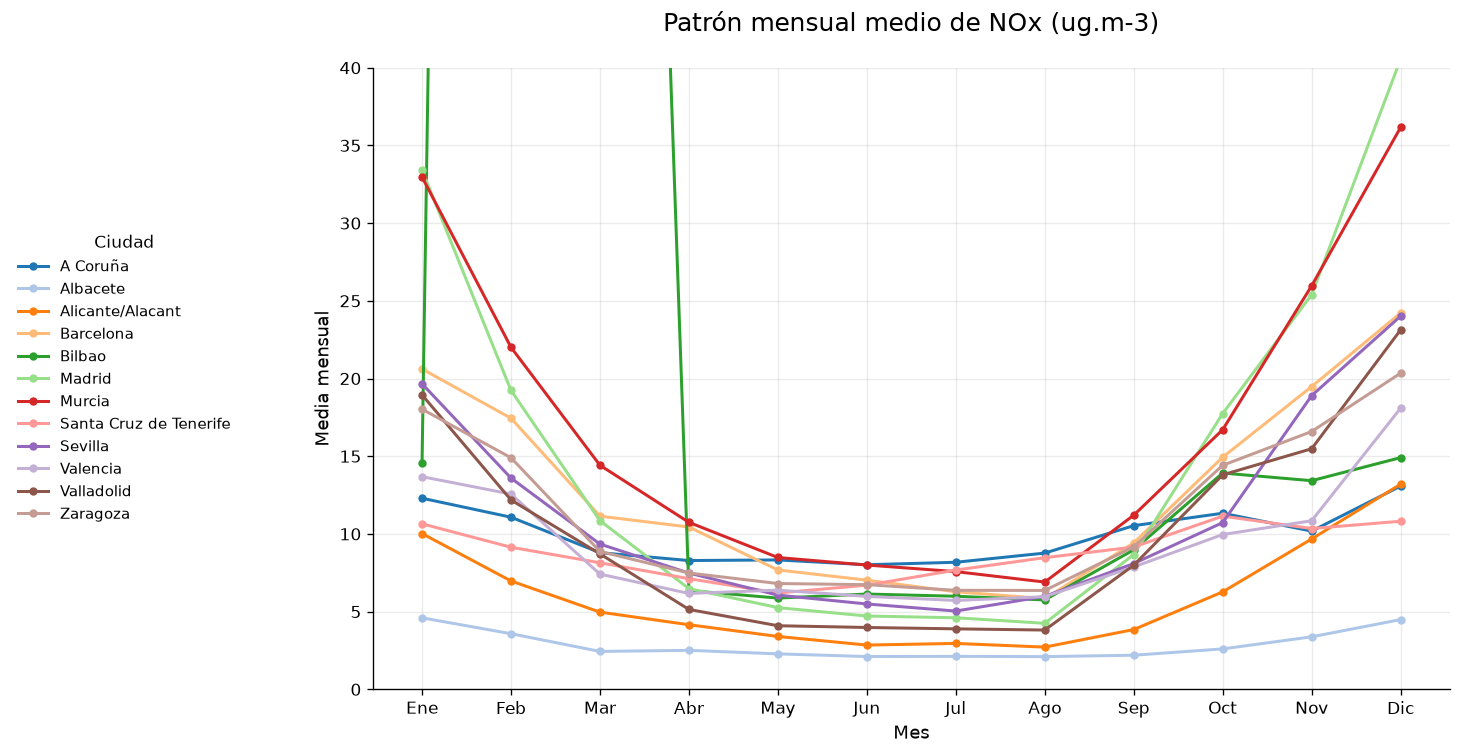

Generando gráfica mensual para: SO2 (ug.m-3)


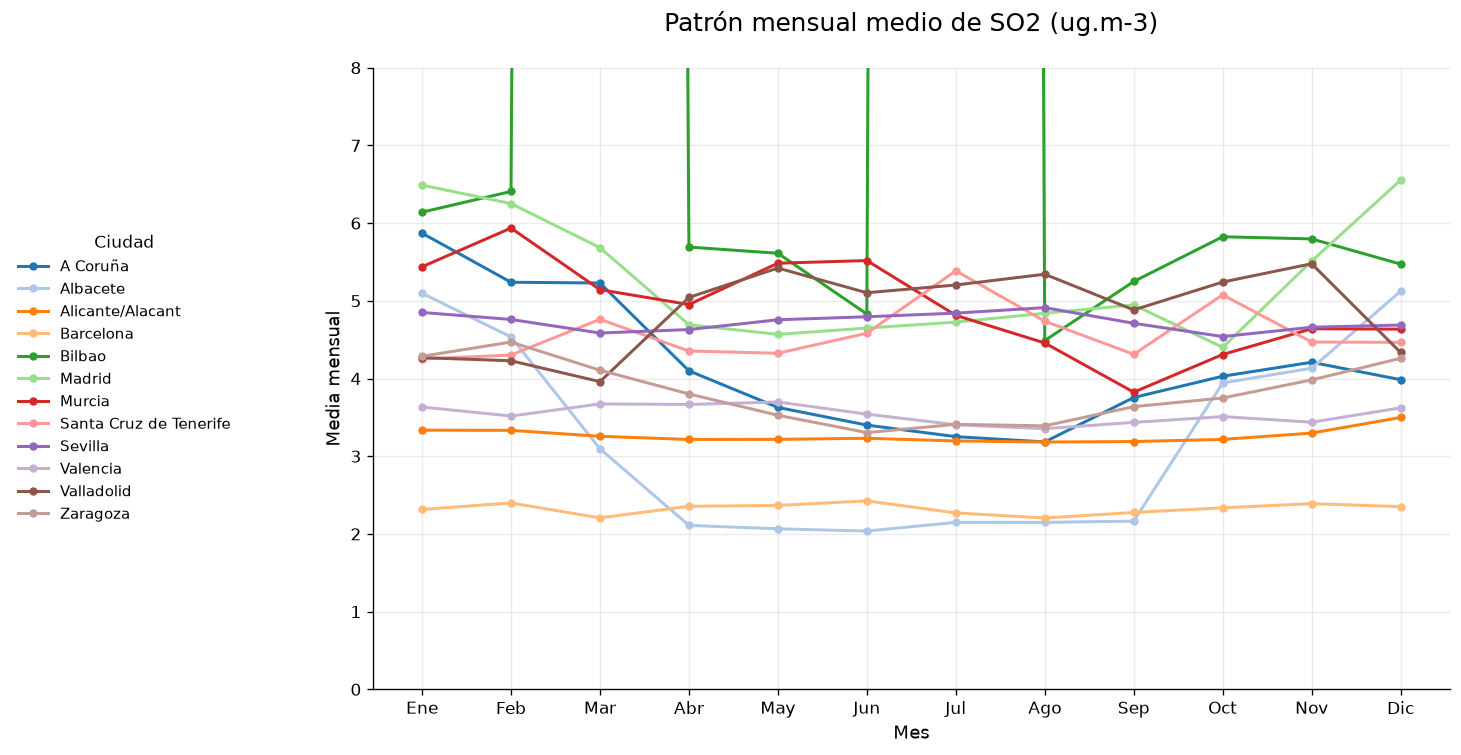

In [44]:
# =============================================================================
# PATRÓN MENSUAL MEDIO SOLO PARA NOx Y SO2
# NOx: RANGO 0-35
# SO2: RANGO 0-15
# =============================================================================

# En esta celda generamos únicamente dos gráficas:
# - NOx (ug.m-3), con eje Y entre 0 y 35
# - SO2 (ug.m-3), con eje Y entre 0 y 15

# -----------------------------------------------------------------------------
# 1. CONTAMINANTES A REPRESENTAR
# -----------------------------------------------------------------------------

contaminantes_objetivo = [
    "NOx (ug.m-3)",
    "SO2 (ug.m-3)"
]


# -----------------------------------------------------------------------------
# 2. CÁLCULO DE LA MEDIA MENSUAL POR CIUDAD Y CONTAMINANTE
# -----------------------------------------------------------------------------

df_media_mensual = (
    df
    .groupby(["city", "Mes"])[contaminantes_objetivo]
    .mean()
    .reset_index()
)

ciudades_ordenadas = sorted(df_media_mensual["city"].dropna().unique())

meses_ordenados = list(range(1, 13))

nombres_meses = [
    "Ene", "Feb", "Mar", "Abr", "May", "Jun",
    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"
]


# -----------------------------------------------------------------------------
# 3. COLORES CONSISTENTES POR CIUDAD
# -----------------------------------------------------------------------------

cmap_ciudades = plt.get_cmap("tab20")

colores_ciudades = {
    ciudad: cmap_ciudades(i)
    for i, ciudad in enumerate(ciudades_ordenadas)
}


# -----------------------------------------------------------------------------
# 4. GENERACIÓN DE UNA FIGURA POR CONTAMINANTE
# -----------------------------------------------------------------------------

for contaminante in contaminantes_objetivo:

    print(f"Generando gráfica mensual para: {contaminante}")

    fig, ax = plt.subplots(figsize=(13, 7))
    fig.patch.set_facecolor("white")

    df_plot = df_media_mensual[["city", "Mes", contaminante]].copy()

    for ciudad in ciudades_ordenadas:

        df_ciudad = (
            df_plot[df_plot["city"] == ciudad]
            .sort_values("Mes")
        )

        ax.plot(
            df_ciudad["Mes"],
            df_ciudad[contaminante],
            marker="o",
            linewidth=1.8,
            markersize=4,
            color=colores_ciudades[ciudad],
            label=ciudad
        )

    # Título y etiquetas
    ax.set_title(
        f"Patrón mensual medio de {contaminante}",
        fontsize=15,
        pad=22
    )

    ax.set_xlabel("Mes", fontsize=11)
    ax.set_ylabel("Media mensual", fontsize=11)

    # Eje X
    ax.set_xticks(meses_ordenados)
    ax.set_xticklabels(nombres_meses, fontsize=10)
    ax.tick_params(axis="y", labelsize=10)

    # Eje Y específico según contaminante
    if contaminante == "NOx (ug.m-3)":
        ax.set_ylim(0, 40)

    elif contaminante == "SO2 (ug.m-3)":
        ax.set_ylim(0, 8)

    # Rejilla y bordes
    ax.grid(True, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Leyenda a la izquierda
    ax.legend(
        loc="center right",
        bbox_to_anchor=(-0.12, 0.5),
        frameon=False,
        title="Ciudad",
        fontsize=9,
        title_fontsize=10
    )

    # Ajuste de márgenes
    plt.subplots_adjust(
        left=0.28,
        right=0.97,
        top=0.88,
        bottom=0.14
    )

    # Guardado
    nombre_limpio = normalizar_texto(contaminante)

    # Define la ruta del directorio de destino
    ruta_destino = FOLDER_FIGS / "estacionalidad anual"

    # Crea la carpeta y subcarpetas si no existen
    ruta_destino.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        ruta_destino / f"patron_mensual_medio_{nombre_limpio}(1).png",
        bbox_inches="tight",
        dpi=180,
        facecolor="white"
    )

    plt.show()

En el caso del **CO**, apreciamos un patrón repetido en todas las ciudades: tendencia descendiente desde enero hasta la primavera/verano (entre mayo y julio), seguida de una posterior tendencia creciente. Murcia, Madrid, Valladolid, Sevilla y Barcelona presentan los valores medios más altos, mientras que Alicante, A Coruña y Valencia muestran niveles más bajos.

El **NO** sigue los mismos patrones que el CO. Murcia y Madrid destacan con niveles elevados, mientras que Albacete presenta valores inferiores durante todo el año.

El **NO2** muestra un comportamiento similar al NO, aunque con niveles más altos y una estructura estacional aún más marcada. Murcia destaca de nuevo, con valores altos, seguida por ciudades como Barcelona, Madrid, Sevilla y Zaragoza. Valencia vuelve a ser la ciudad con los valores más bajos.

En el caso del **NOx**, ocurre exactamente lo mismo que anteriormente. Destacan Murcia y Madrid por sus elevados niveles para este cotaminante, y de nuevo Valencia por sus bajos niveles. Además, observamos como Bilbao presenta unos niveles desmesurados en los meses de febrero y marzo.

El **O3** presenta un patrón totalmente opuesto al de los contaminantes anteriores. Ahora, apreciamos una tendencia creciente desde enero hasta primavera/verano (entre mayo y julio), seguida de una posterior tendencia descendiente para la mayoría de ciudades. Albacete y Alicante muestran los valores más altos, mientras que Madrid y Murcia presentan los valores más bajos. También observamos un pico puntual para Bilbao en julio.

Para **PM10** no aparece un patrón estacional tan claro como para los contaminantes anteriores. Las series van fluctuando y cambiando a lo largo de los meses. A grandes rasgos, vemos que los valores aumentan desde enero hasta febrero, bajan desde febrero hasta abril/mayo, luego vuelven a subir hasta julio/agosto, comienzan a descender hasta octubre/noviembre y vuelven a subir en diciembre.

Para el **SO2**, algunas ciudades mantiene valores estables por meses, como Barcelona, Alicante, Valencia, Sevilla y Santa Cruz de Tenerife. Otras ciudades, como Albacete, A Coruña, Madrid y Zaragoza repiten el patrón del CO. El resto de ciudades no sigue ningún patrón claro. Además, destaca Bilbao por sus picos extremos en marzo y julio.

Finalmente, el **C6H6** muestra un patrón similar al del O3, a excepción de Zaragoza, Santa Cruz de Tenerife y Barcelona, que muestran valores prácticamente iguales por meses.

### **ANÁLISIS DE LA EVOLUCIÓN HORARIA MEDIO POR CONTAMINANTE**

A continuación, estudiamos el patrón horario medio de cada contaminante atmosférico. Para ello, agrupamos los registros por ciudad y hora del día, calculando la concentración media horaria de cada contaminante. Este análisis permite identificar ciclos diarios asociados a la actividad urbana, el tráfico, la radiación solar y las condiciones de dispersión atmosférica.

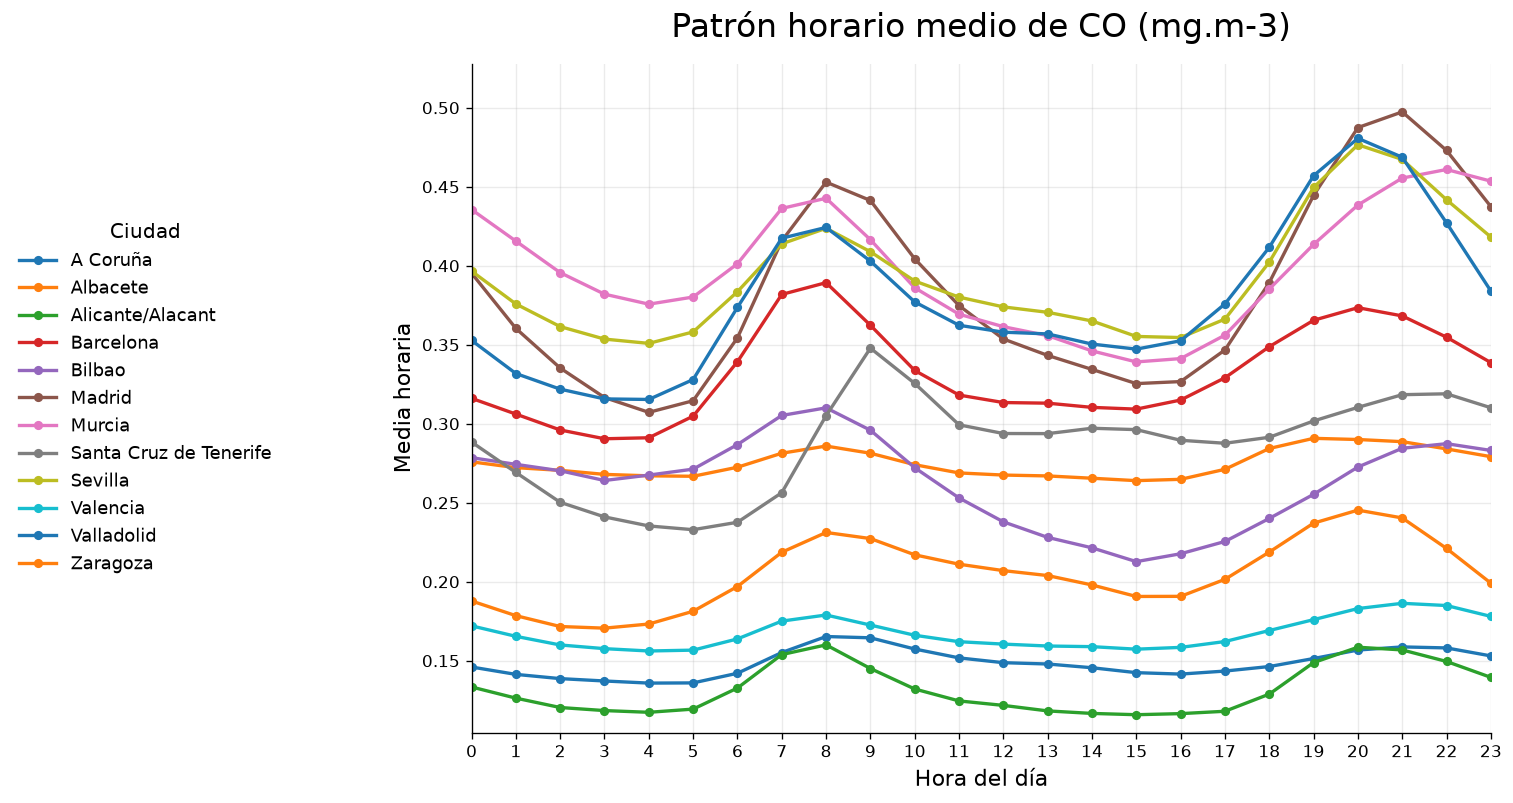

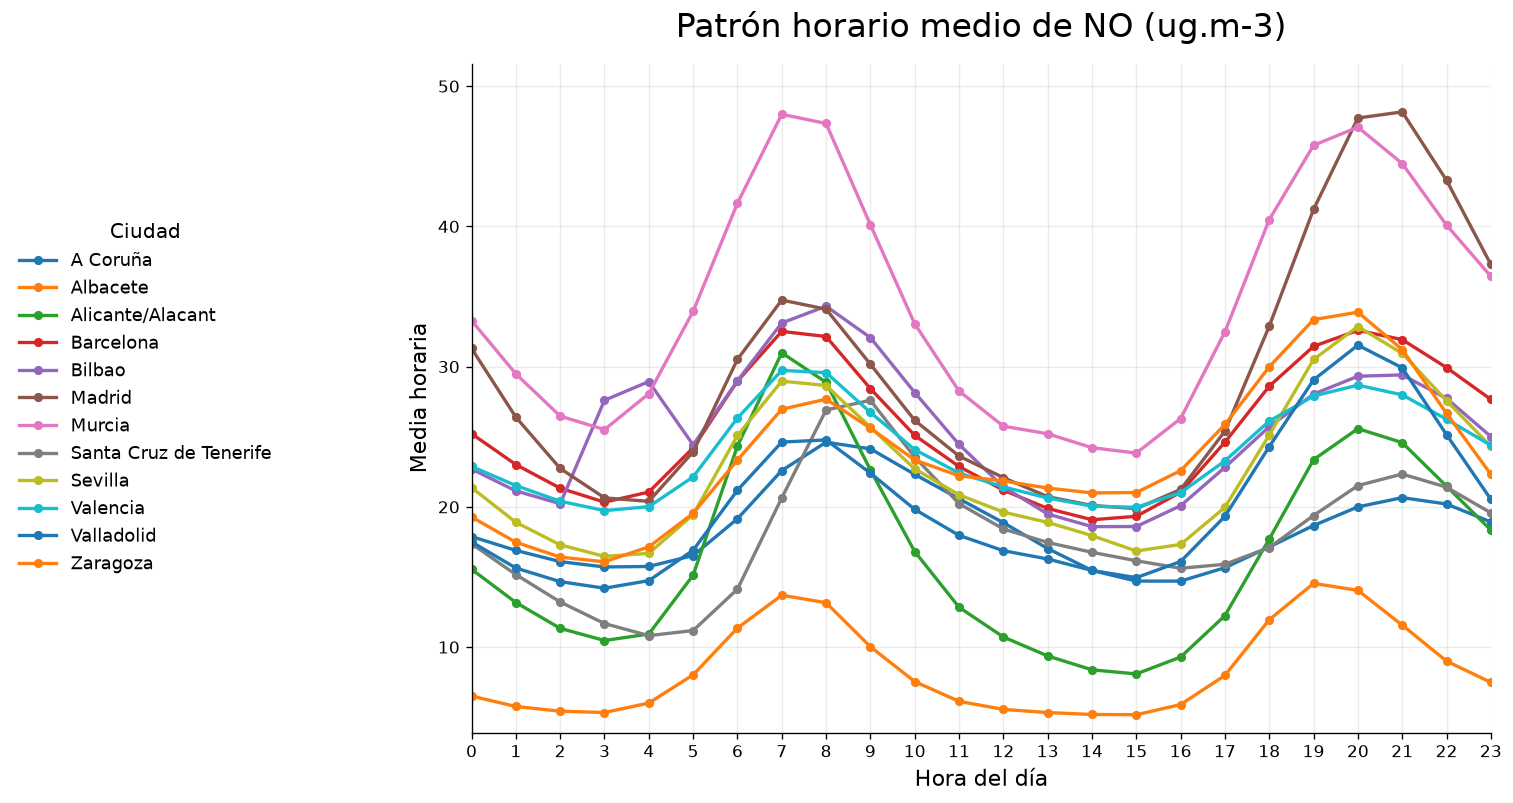

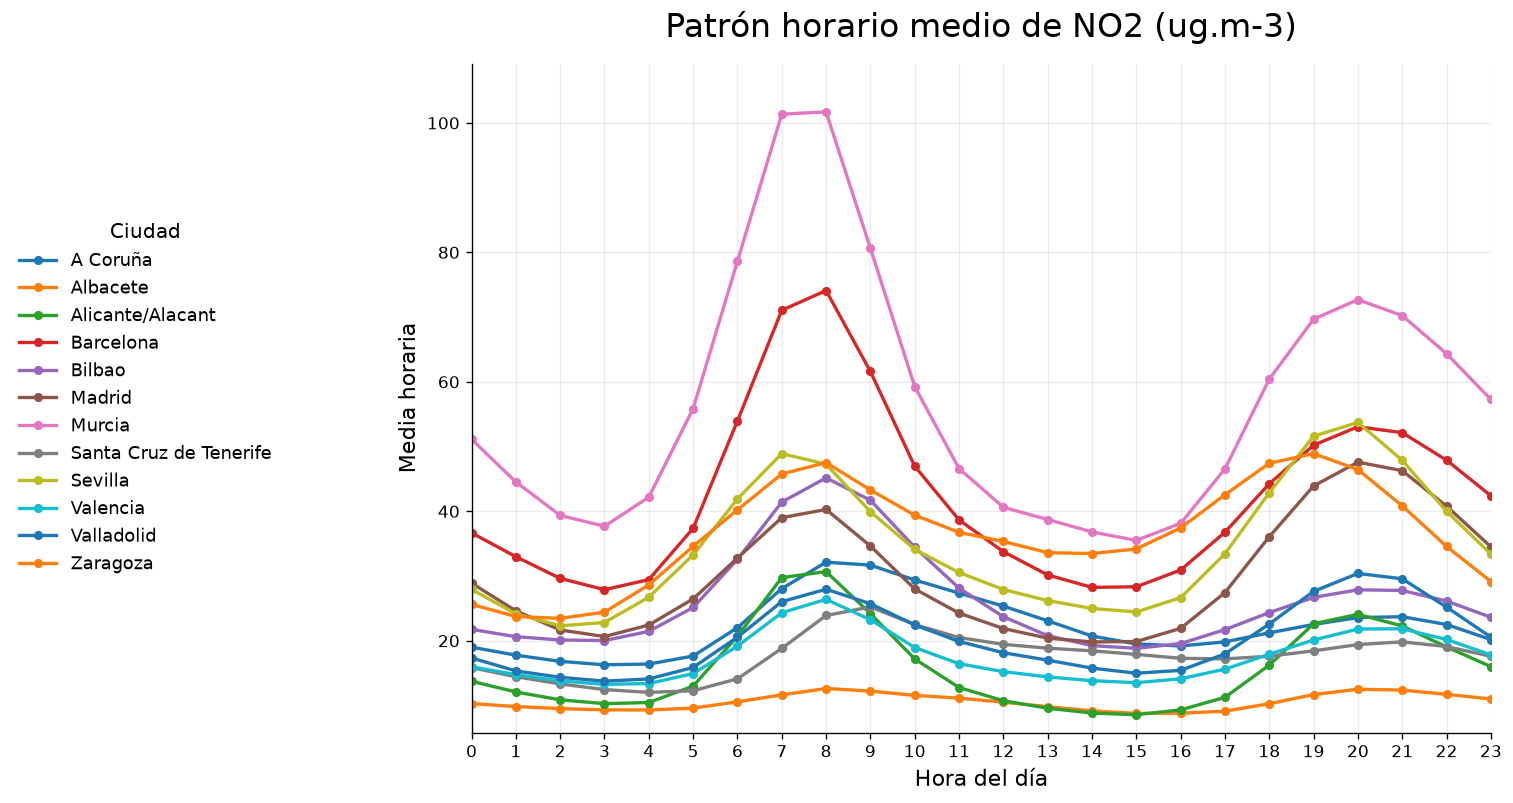

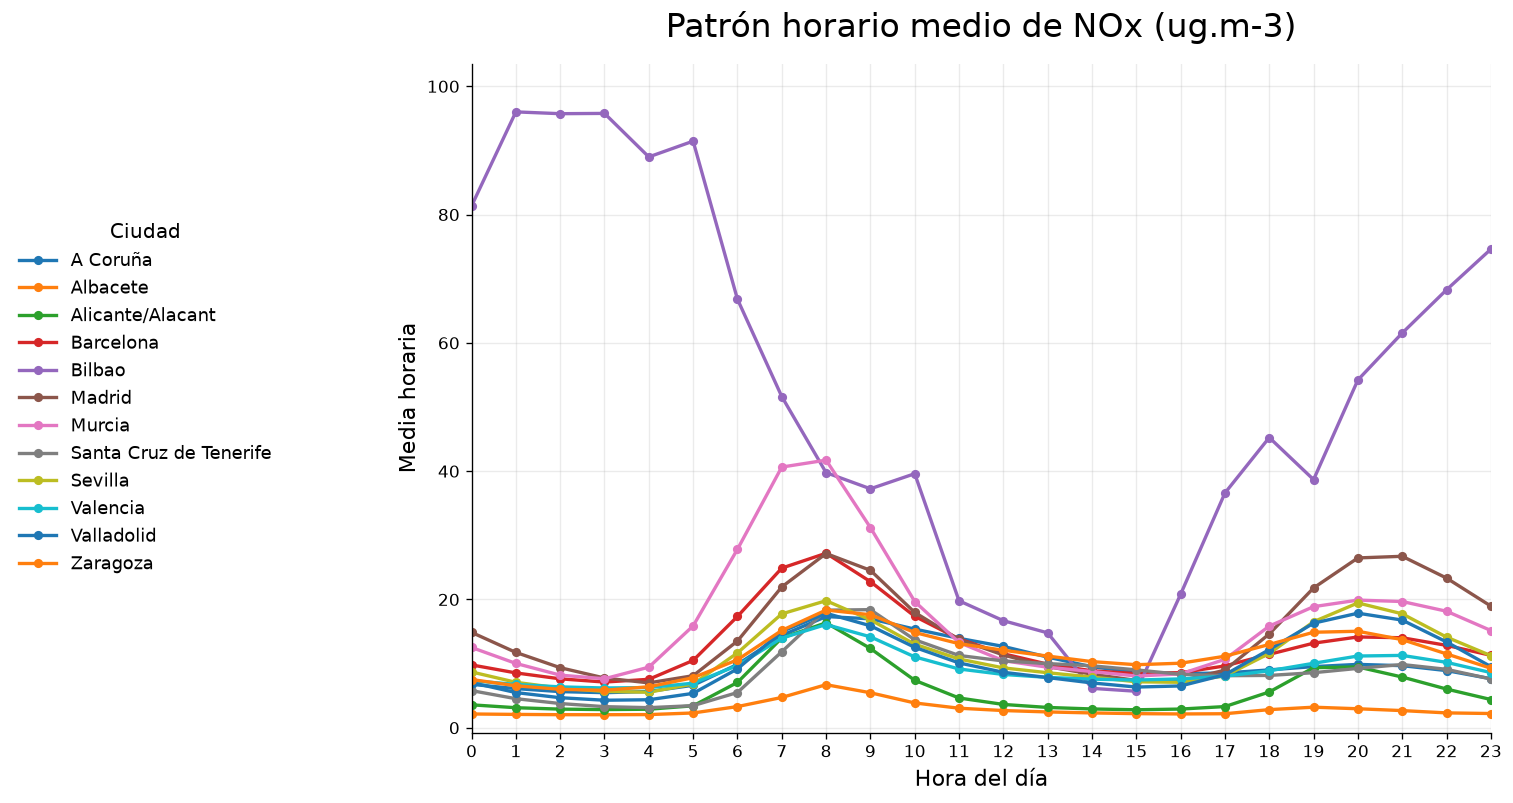

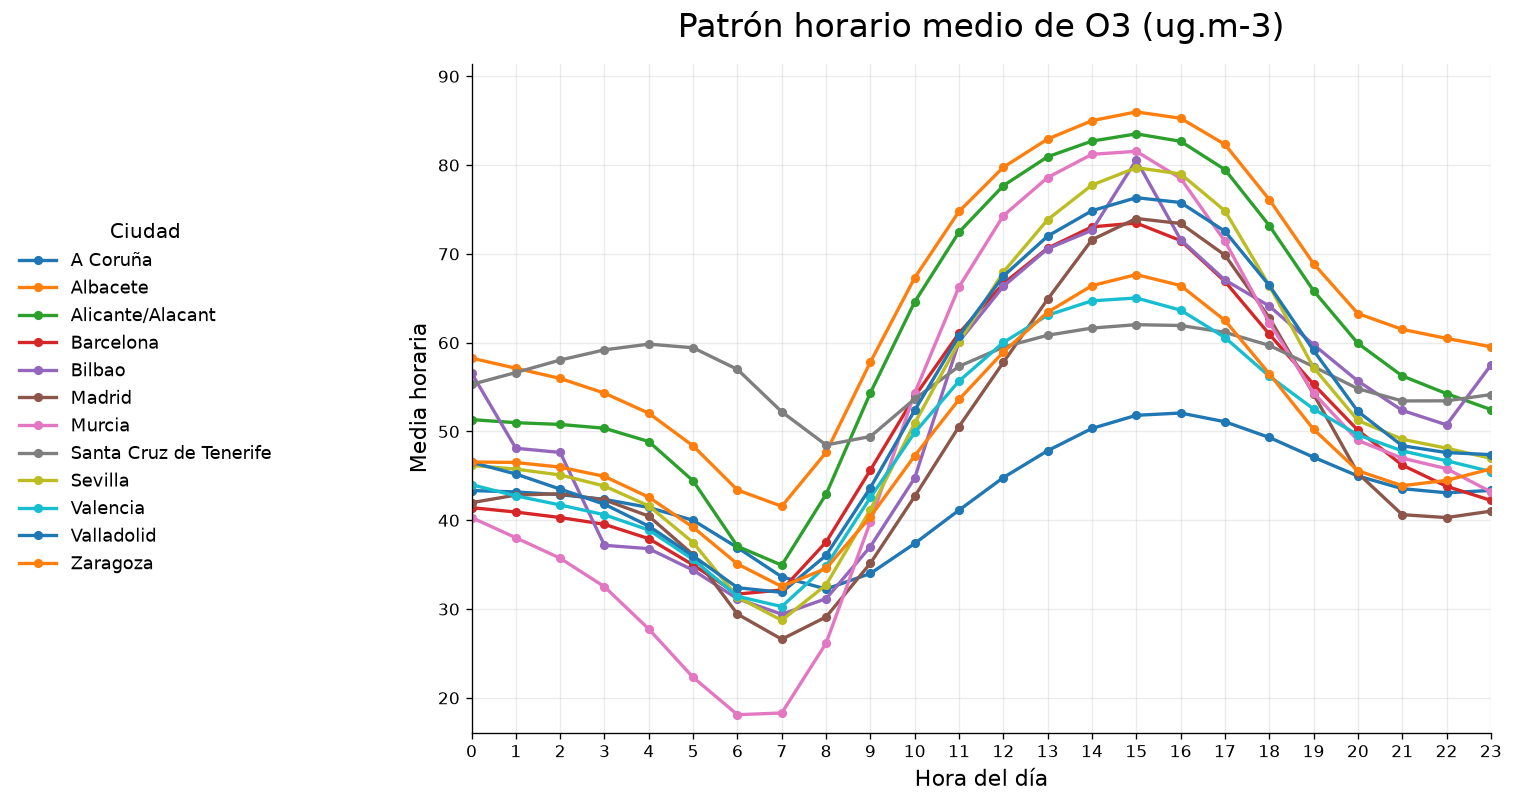

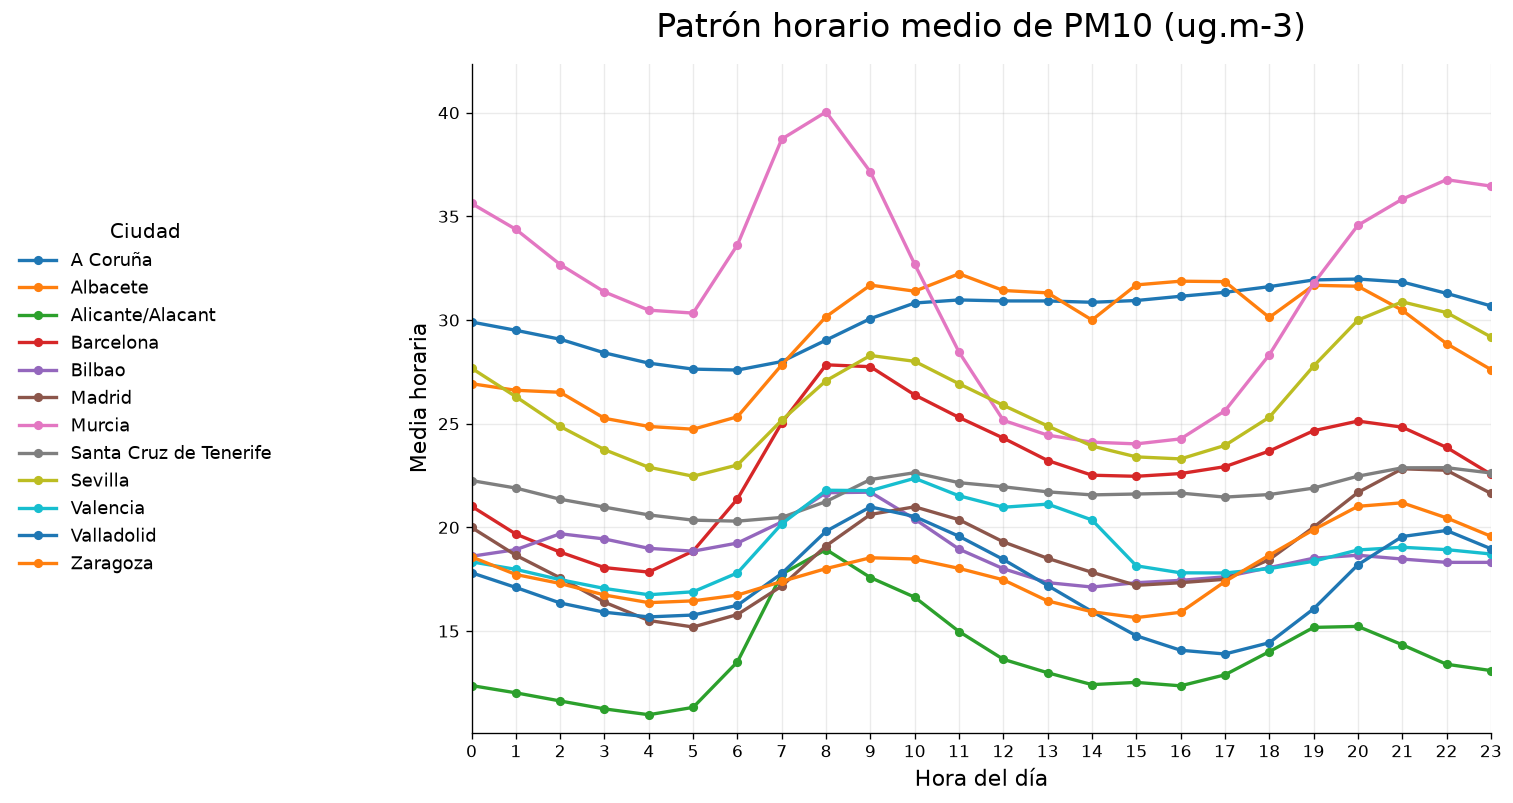

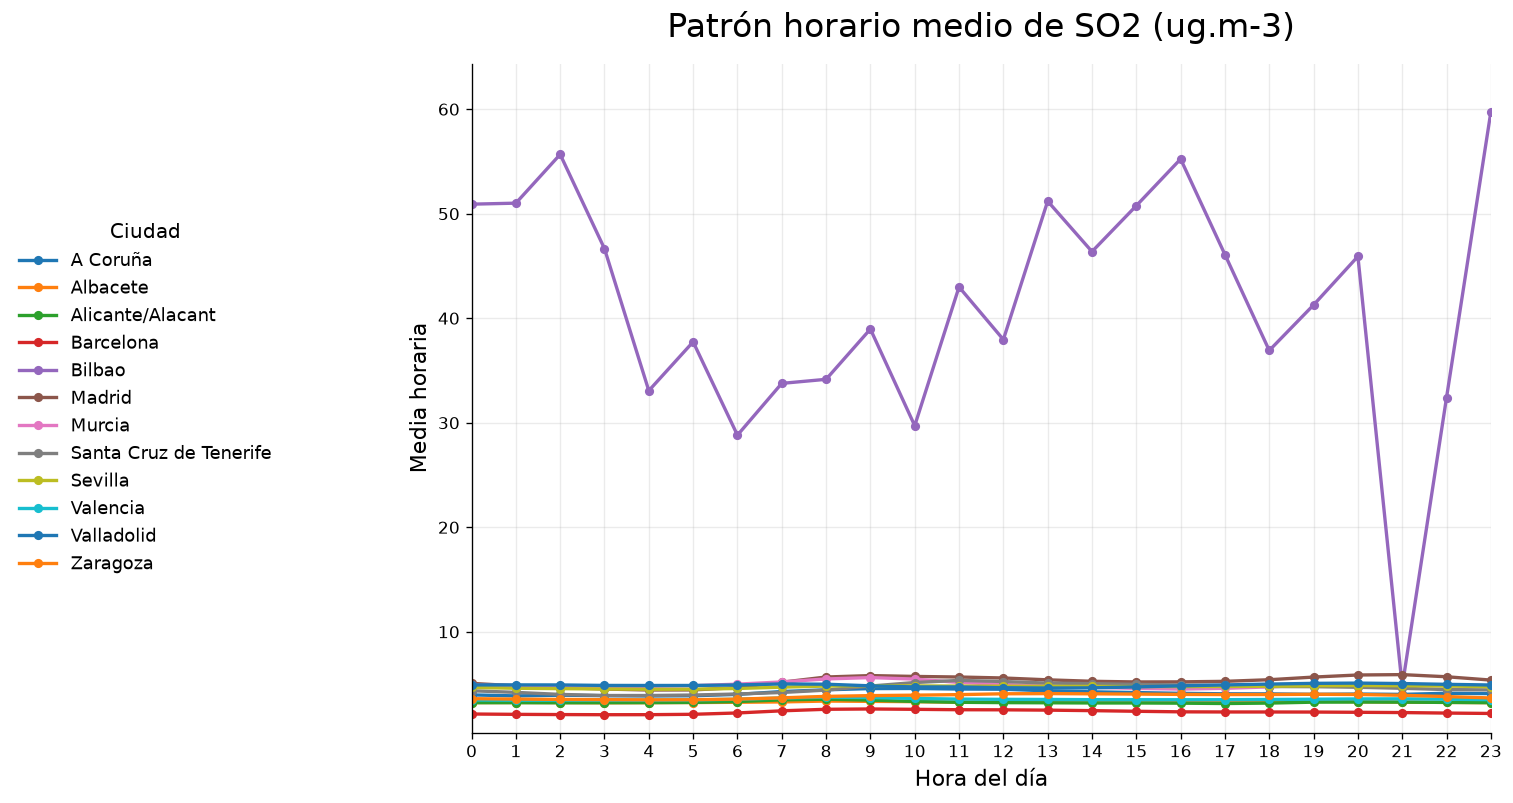

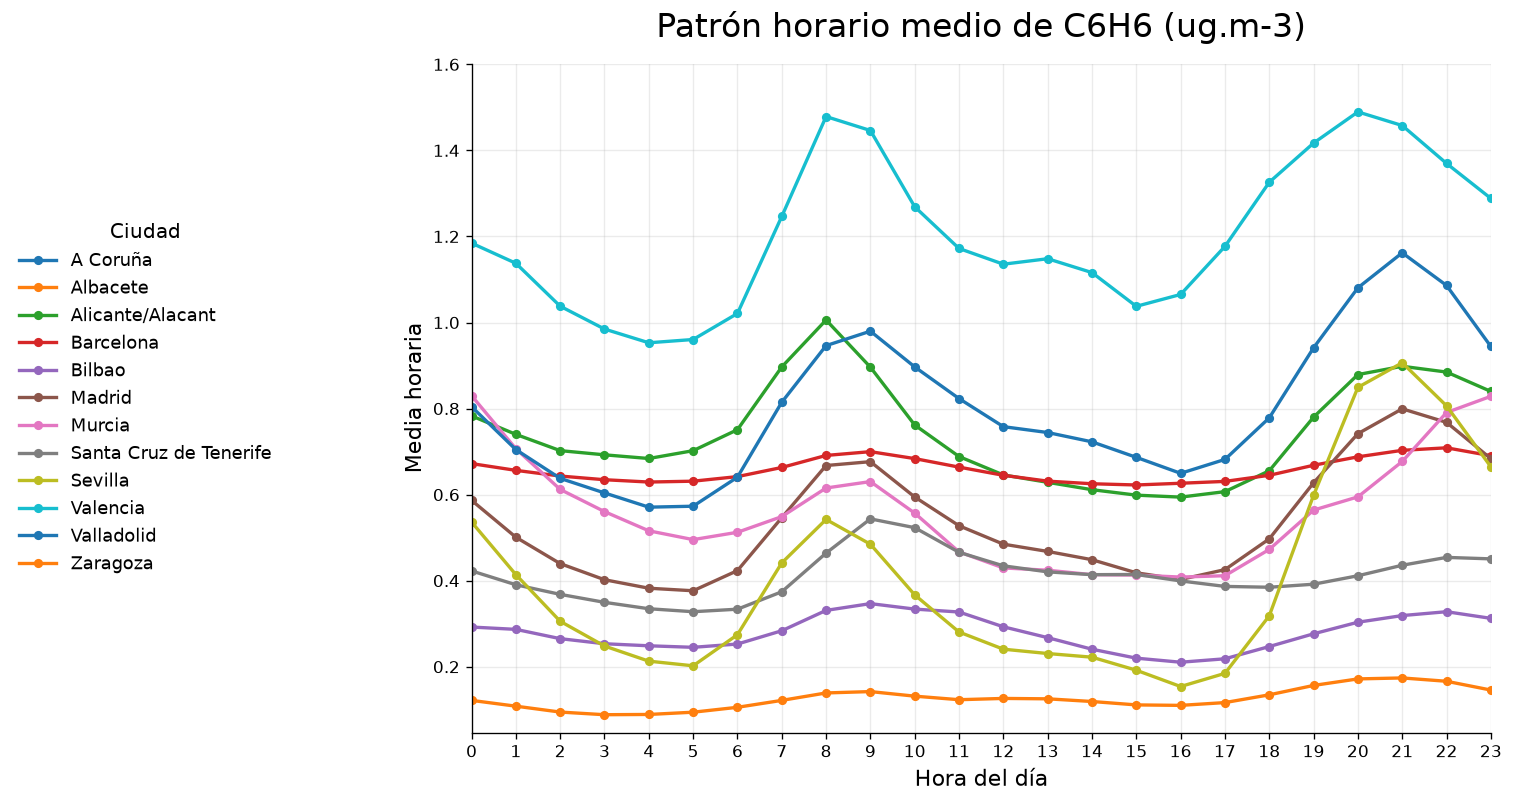

In [45]:
# -----------------------------------------------------------------------------
# 1. CÁLCULO DE LA MEDIA HORARIA POR CIUDAD Y CONTAMINANTE
# -----------------------------------------------------------------------------

df_media_horaria = (
    df
    .groupby(["city", "Hora"])[columnas_contaminantes]
    .mean()
    .reset_index()
)

# Orden de ciudades y horas para que todas las figuras mantengan consistencia.
ciudades_ordenadas = sorted(df_media_horaria["city"].dropna().unique())
horas_ordenadas = list(range(24))


# -----------------------------------------------------------------------------
# 2. GENERACIÓN DE UNA FIGURA POR CADA CONTAMINANTE
# -----------------------------------------------------------------------------

for contaminante in columnas_contaminantes:

    # Filtramos únicamente la información necesaria para el contaminante actual.
    df_plot = df_media_horaria[["city", "Hora", contaminante]].copy()

    # Creamos figura.
    fig, ax = plt.subplots(figsize=(13, 6.8))
    fig.patch.set_facecolor("white")

    # Dibujamos una línea por ciudad.
    for ciudad in ciudades_ordenadas:

        df_ciudad = (
            df_plot[df_plot["city"] == ciudad]
            .sort_values("Hora")
        )

        ax.plot(
            df_ciudad["Hora"],
            df_ciudad[contaminante],
            marker="o",
            linewidth=2,
            markersize=4.5,
            label=ciudad
        )

    # -------------------------------------------------------------------------
    # 3. FORMATO DEL GRÁFICO
    # -------------------------------------------------------------------------

    ax.set_title(
        f"Patrón horario medio de {contaminante}",
        fontsize=20,
        pad=16
    )

    ax.set_xlabel("Hora del día", fontsize=13)
    ax.set_ylabel("Media horaria", fontsize=13)

    ax.set_xticks(horas_ordenadas)
    ax.set_xlim(0, 23)

    # Cuadrícula suave para facilitar lectura.
    ax.grid(True, alpha=0.25)

    # Quitamos bordes superiores y derechos para una visualización más limpia.
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Ajuste automático del eje Y para que no se corte por arriba.
    serie_valores = df_plot[contaminante].dropna()

    if len(serie_valores) > 0:
        ymin = serie_valores.min()
        ymax = serie_valores.max()
        margen = 0.08 * (ymax - ymin) if ymax > ymin else 0.1 * ymax if ymax != 0 else 1
        ax.set_ylim(ymin - 0.03 * (ymax - ymin), ymax + margen)

    # Leyenda a la izquierda, fuera del gráfico.
    ax.legend(
        title="Ciudad",
        loc="center right",
        bbox_to_anchor=(-0.18, 0.5),
        frameon=False,
        fontsize=11,
        title_fontsize=12
    )

    plt.tight_layout()

    # -------------------------------------------------------------------------
    # 4. GUARDADO
    # -------------------------------------------------------------------------

    nombre_limpio = normalizar_texto(contaminante)

    # Define la ruta del directorio de destino
    ruta_destino = FOLDER_FIGS / "estacionalidad horaria"

    # Crea la carpeta y subcarpetas si no existen
    ruta_destino.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        ruta_destino / f"patron_horario_{nombre_limpio}.png",
        bbox_inches="tight",
        dpi=180,
        facecolor="white"
    )

    plt.show()

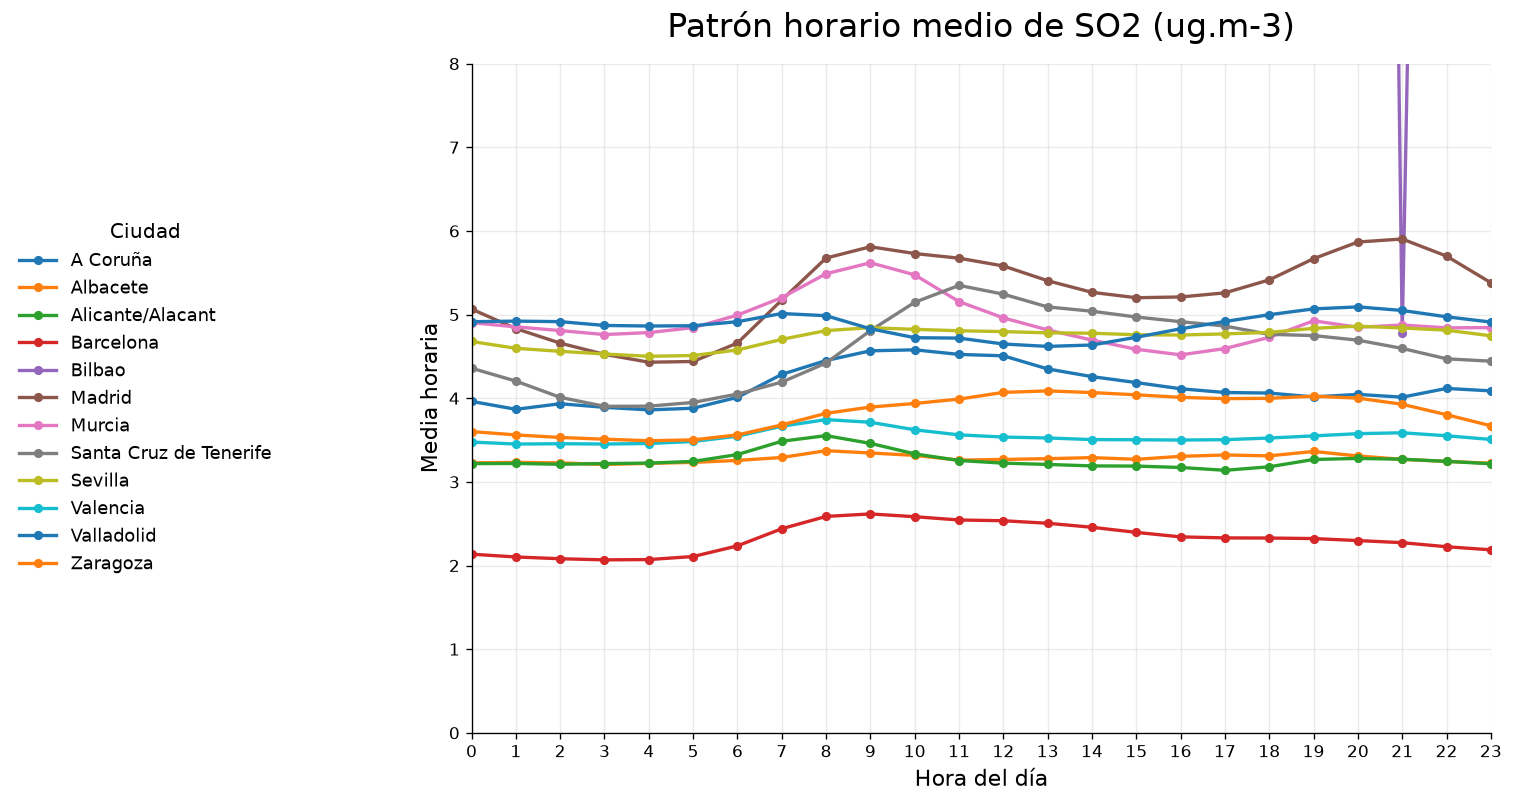

In [46]:
# =============================================================================
# PATRÓN HORARIO MEDIO DE SO2 CON EJE Y ENTRE 0 Y 8
# =============================================================================

# En esta celda generamos únicamente la gráfica del patrón horario medio
# del contaminante SO2.
#
# - Eje X: hora del día
# - Eje Y: media horaria
# - Una línea por ciudad
# - Rango del eje Y fijado entre 0 y 8

# -----------------------------------------------------------------------------
# 1. CONTAMINANTE OBJETIVO
# -----------------------------------------------------------------------------

contaminante = "SO2 (ug.m-3)"


# -----------------------------------------------------------------------------
# 2. CÁLCULO DE LA MEDIA HORARIA POR CIUDAD
# -----------------------------------------------------------------------------

df_media_horaria = (
    df
    .groupby(["city", "Hora"])[contaminante]
    .mean()
    .reset_index()
)

ciudades_ordenadas = sorted(df_media_horaria["city"].dropna().unique())
horas_ordenadas = list(range(24))


# -----------------------------------------------------------------------------
# 3. CREACIÓN DE LA FIGURA
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 6.8))
fig.patch.set_facecolor("white")

for ciudad in ciudades_ordenadas:

    df_ciudad = (
        df_media_horaria[df_media_horaria["city"] == ciudad]
        .sort_values("Hora")
    )

    ax.plot(
        df_ciudad["Hora"],
        df_ciudad[contaminante],
        marker="o",
        linewidth=2,
        markersize=4.5,
        label=ciudad
    )


# -----------------------------------------------------------------------------
# 4. FORMATO DEL GRÁFICO
# -----------------------------------------------------------------------------

ax.set_title(
    "Patrón horario medio de SO2 (ug.m-3)",
    fontsize=20,
    pad=16
)

ax.set_xlabel("Hora del día", fontsize=13)
ax.set_ylabel("Media horaria", fontsize=13)

ax.set_xticks(horas_ordenadas)
ax.set_xlim(0, 23)

# Fijamos el rango del eje Y.
ax.set_ylim(0, 8)

ax.grid(True, alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Ciudad",
    loc="center right",
    bbox_to_anchor=(-0.18, 0.5),
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

plt.tight_layout()

plt.savefig(
    ruta_destino / "patron_horario_SO2_ugm-3(1).png",
    bbox_inches="tight",
    dpi=180,
    facecolor="white"
)

plt.show()

En el caso del **CO**, observamos un patrón horario que se repite para todas las ciudades: los niveles bajan desde las 00:00 hasta las 04:00/05:00, suben hasta las 08:00/09:00, descienden ligeramente hasta las 15:00/16:00, vuelven a aumentar hasta las 20:00/21:00, para acabar descendiendo de nuevo. Ciudades como Madrid, Murcia, Sevilla y A Coruña muestran niveles horarios relativamente elevados, mientras que Alicante, Valladolid y Valencia presentan valores más bajos y estables.

El **NO** presenta el mismo patrón horario anterior, a excepción de Bilbao, que aumenta desde las 02:00 hasta las 05:00 y baja hasta las 06:00. Murcia y Madrid destacan con valores elevados, mientras que Albacete muestra valores más bajos durante todo el día.

El **NO2** también presenta el mismo patrón horario anterior. Ciudades como Barcelona y Murcia presentan los valores más altos, mientras que los menores le vuelven a corresponder a Albacete.

El **NOx** muestra un patrón similar a los anteriores para todas las ciudades, salvo para Bilbao, que presenta un patrón totalmente distinto: en general, bajan desde las 00:00 hasta las 14:00/15:00, para subir hasta el fin del día.

En el caso de **O3**, el patrón horario es totalmente el opuesto. Sus concentraciones bajan hasta las 06:00/07:00, suben hasta las 16:00 para volver a bajar hasta las 00:00. Ciudades como Albacete, Alicante, Sevilla o Murcia muestran valores elevados durante estas horas centrales.

En el caso de **PM10**, el patrón horario de NO, NO2 u O3 se mantiene, aunque de manera menos marcada y con valores más estables para A Coruña, Zaragoza, Bilbao y Santa Cruz de Tenerife a partir de la tarde.

Para **SO2**, observamos que la mayoría de ciudades presentan valores relativamente estables a lo largo del día, con pequeñas variaciones horarias. Madrid, Murcia, Santa Cruz de Tenerife, Sevilla y A Coruña muestran niveles algo superiores en determinados tramos, mientras que Barcelona se mantiene en valores mucho más bajos. Para Bilbao, observamos valores extremos y muy superiores al resto de ciudades.

Finalmente, el **C6H6** muestra un patrón diario bastante similar al del CO. Valencia destaca con niveles superiores al resto en gran parte del día, mientras que otras ciudades como Zaragoza o Bilbao presentan valores más bajos.

### **MAPA DE CALOR CON CORRELACIONES**

Acabamos este EDA analizando las correlaciones de Pearson calculadas de forma independiente para cada ciudad entre los contaminantes atmosféricos, las variables meteorológicas y los índices urbanos, con el fin de encontrar relaciones entre las distintas variables para cada ciudad.

Generando matriz de correlación para: A Coruña


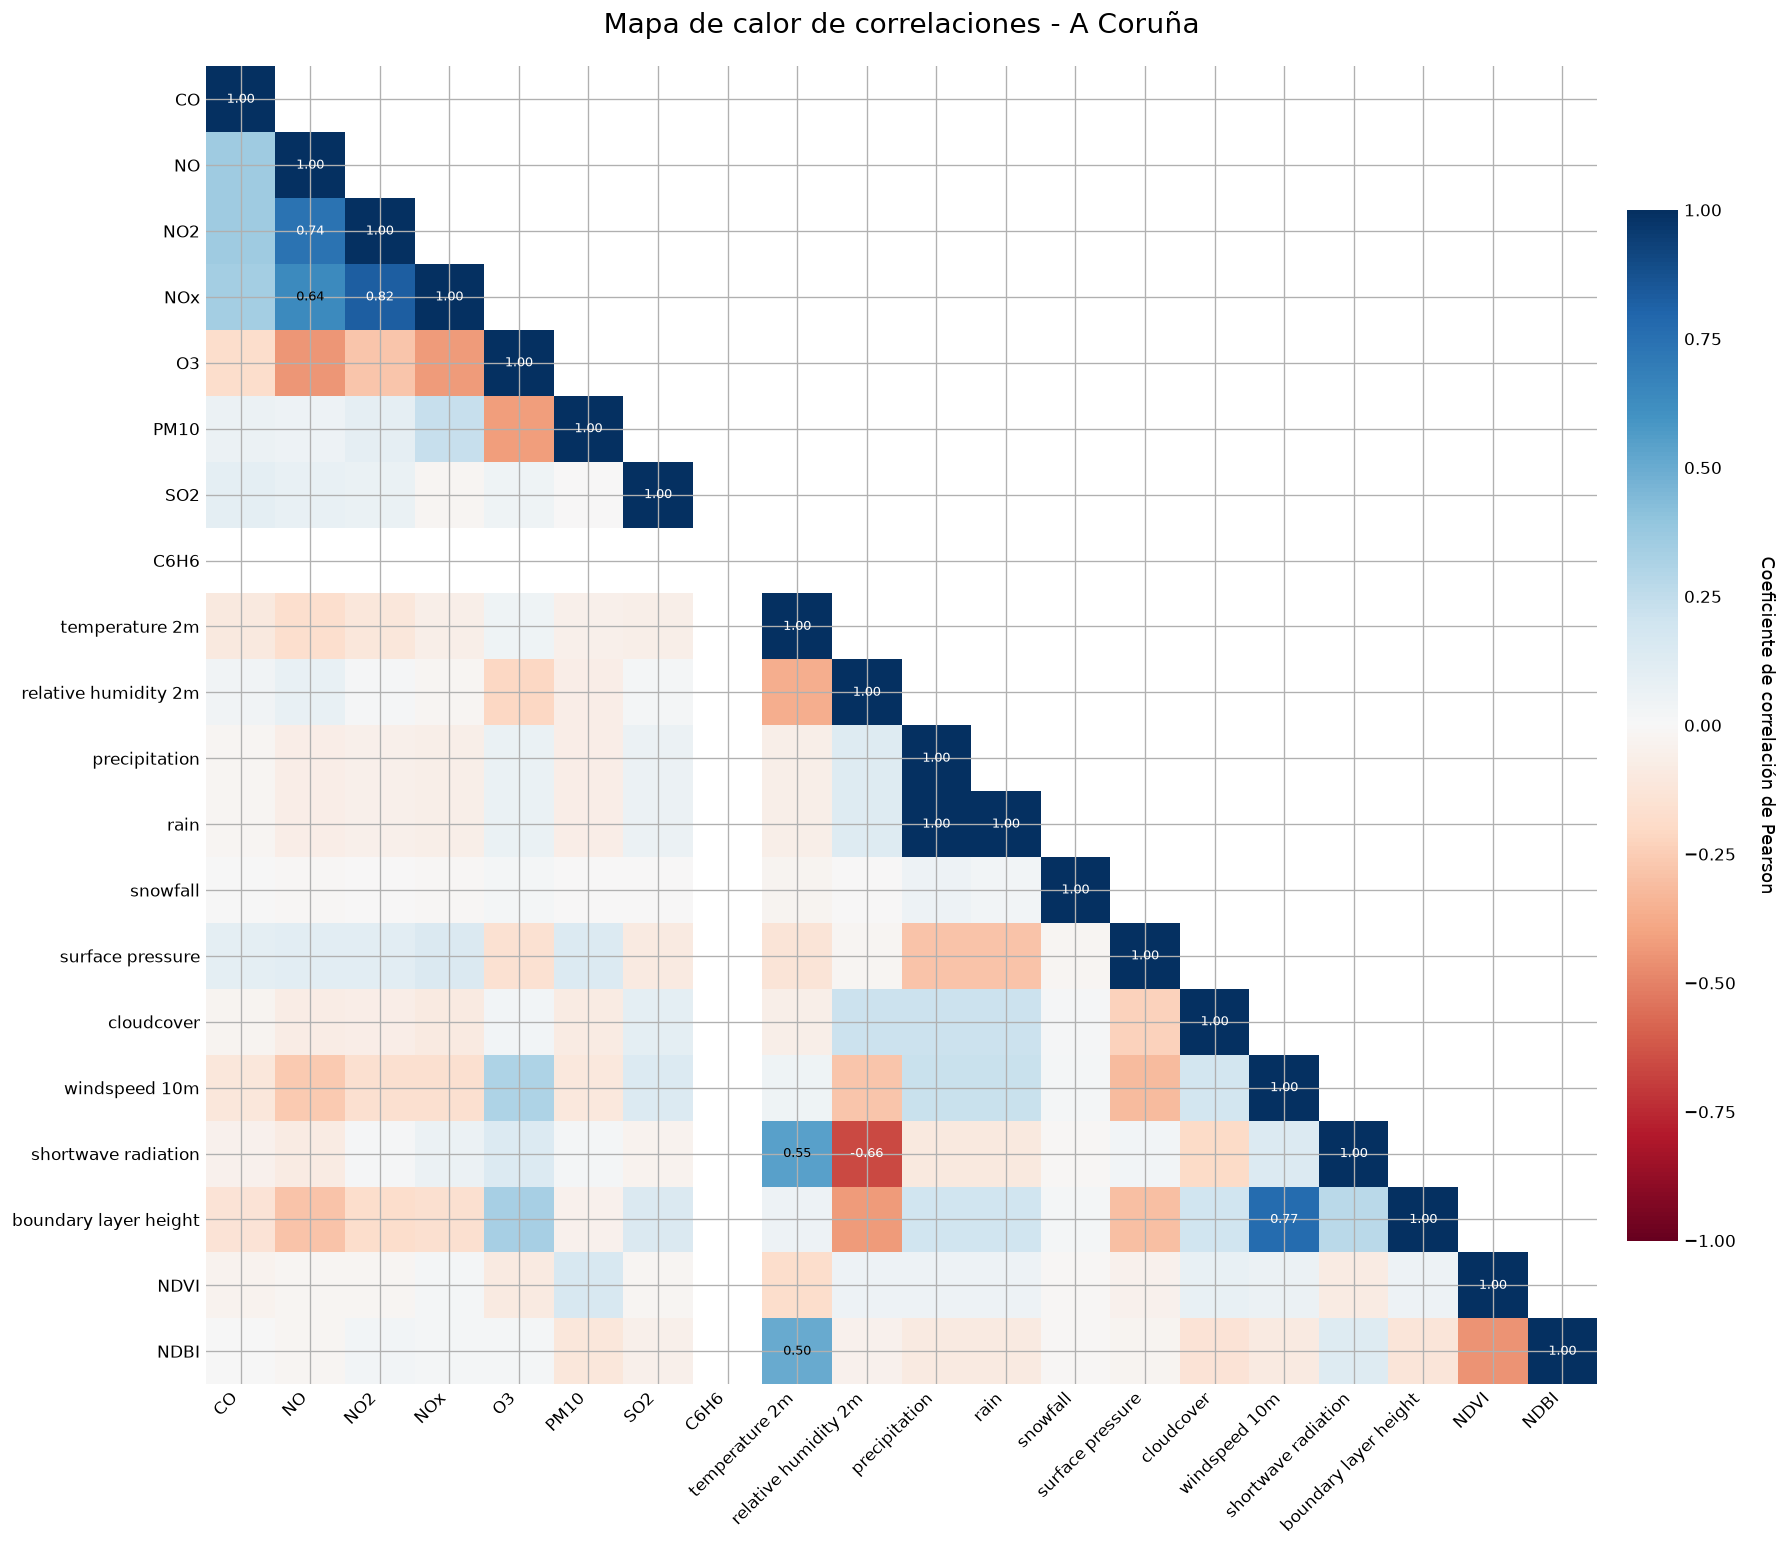

Generando matriz de correlación para: Albacete


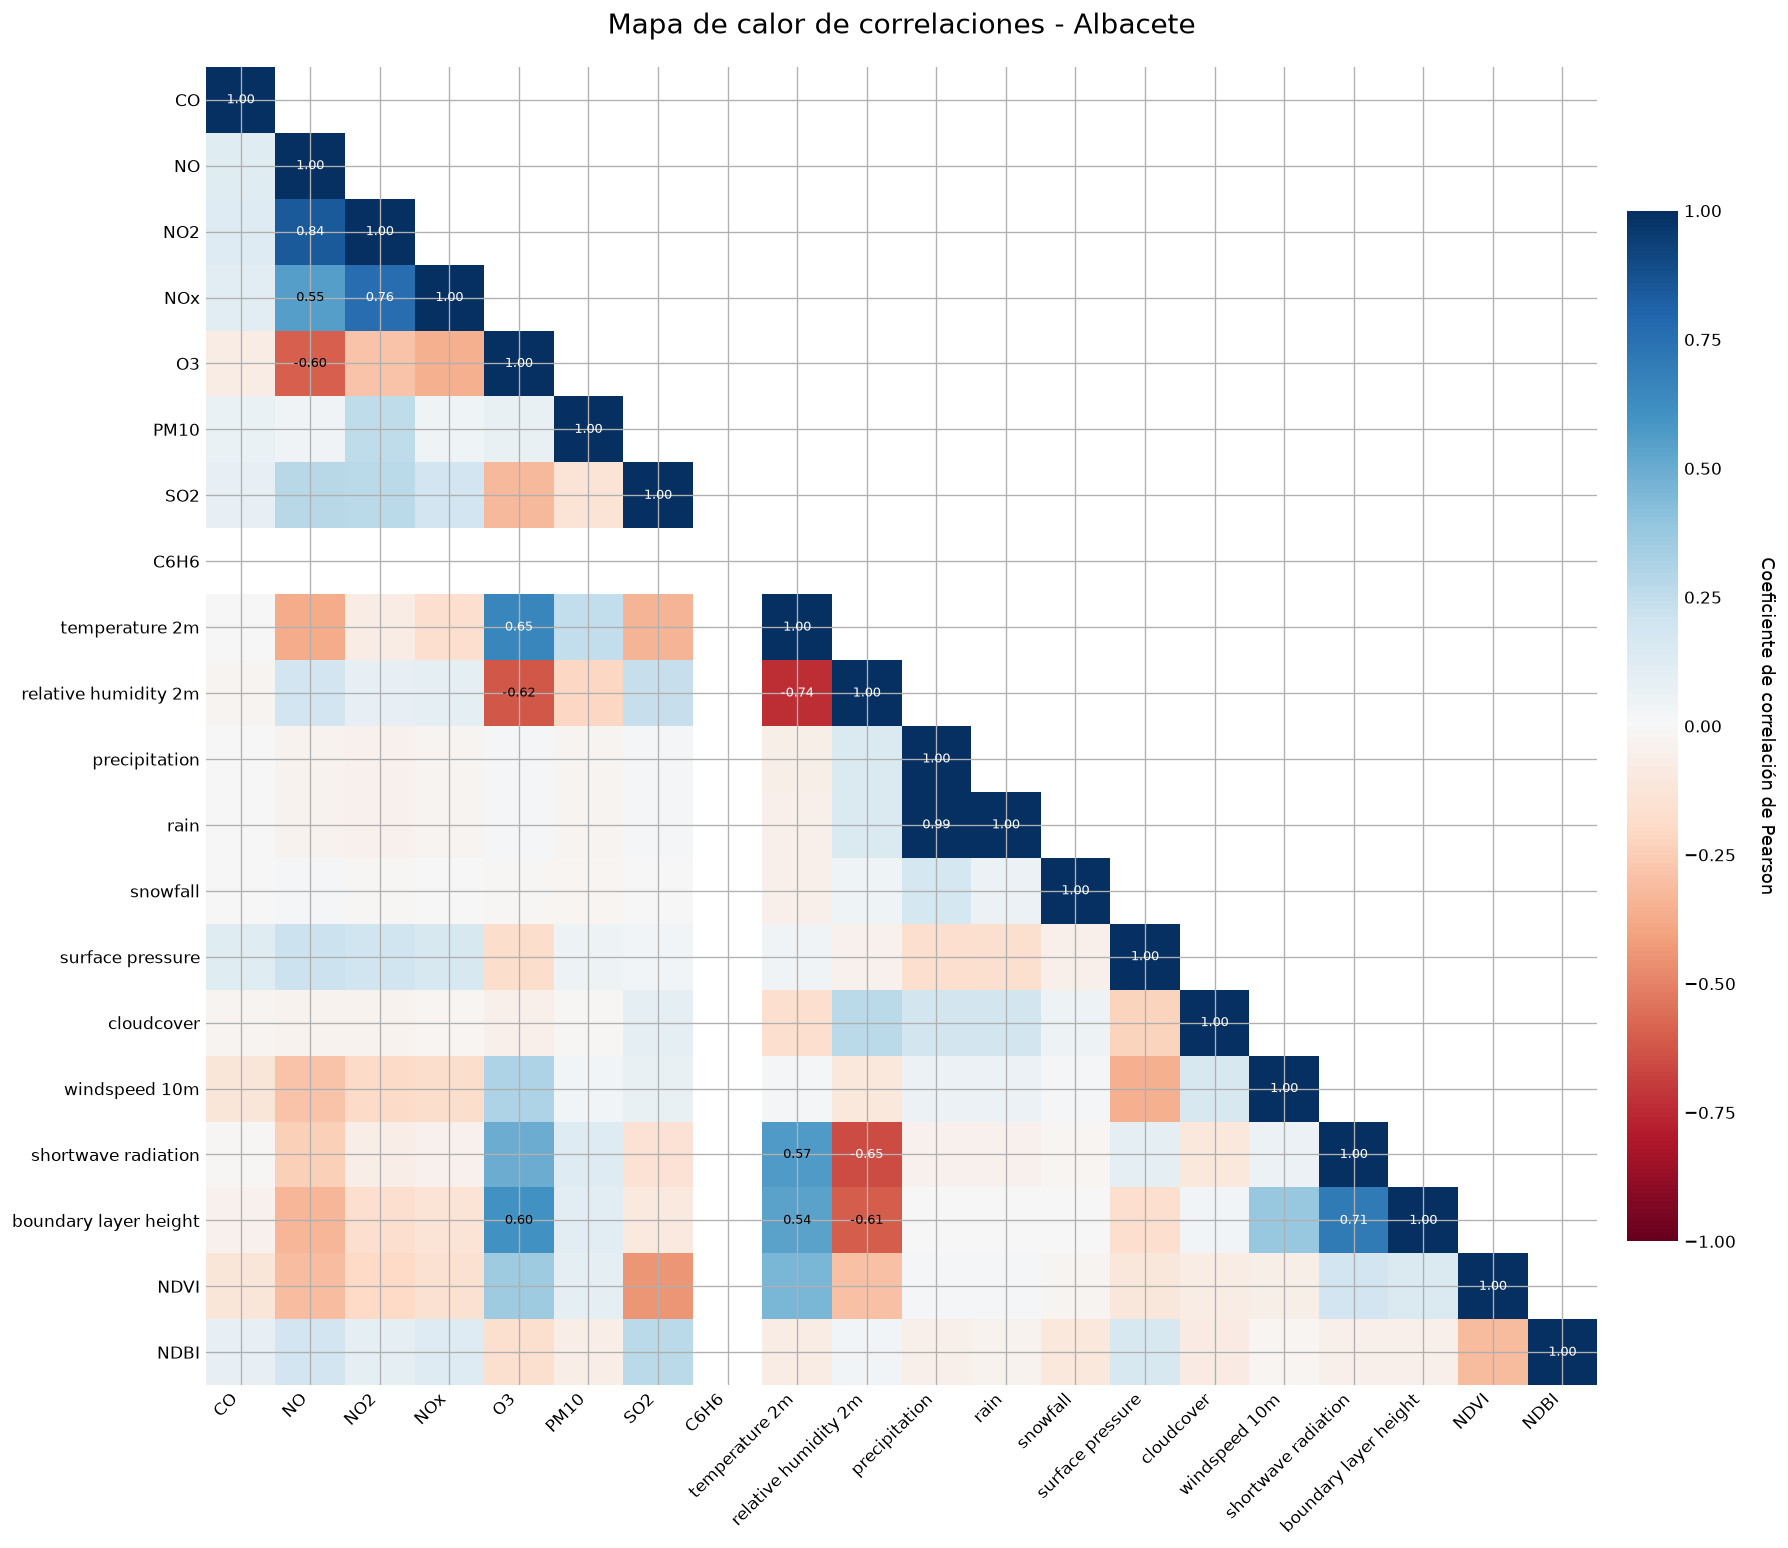

Generando matriz de correlación para: Alicante/Alacant


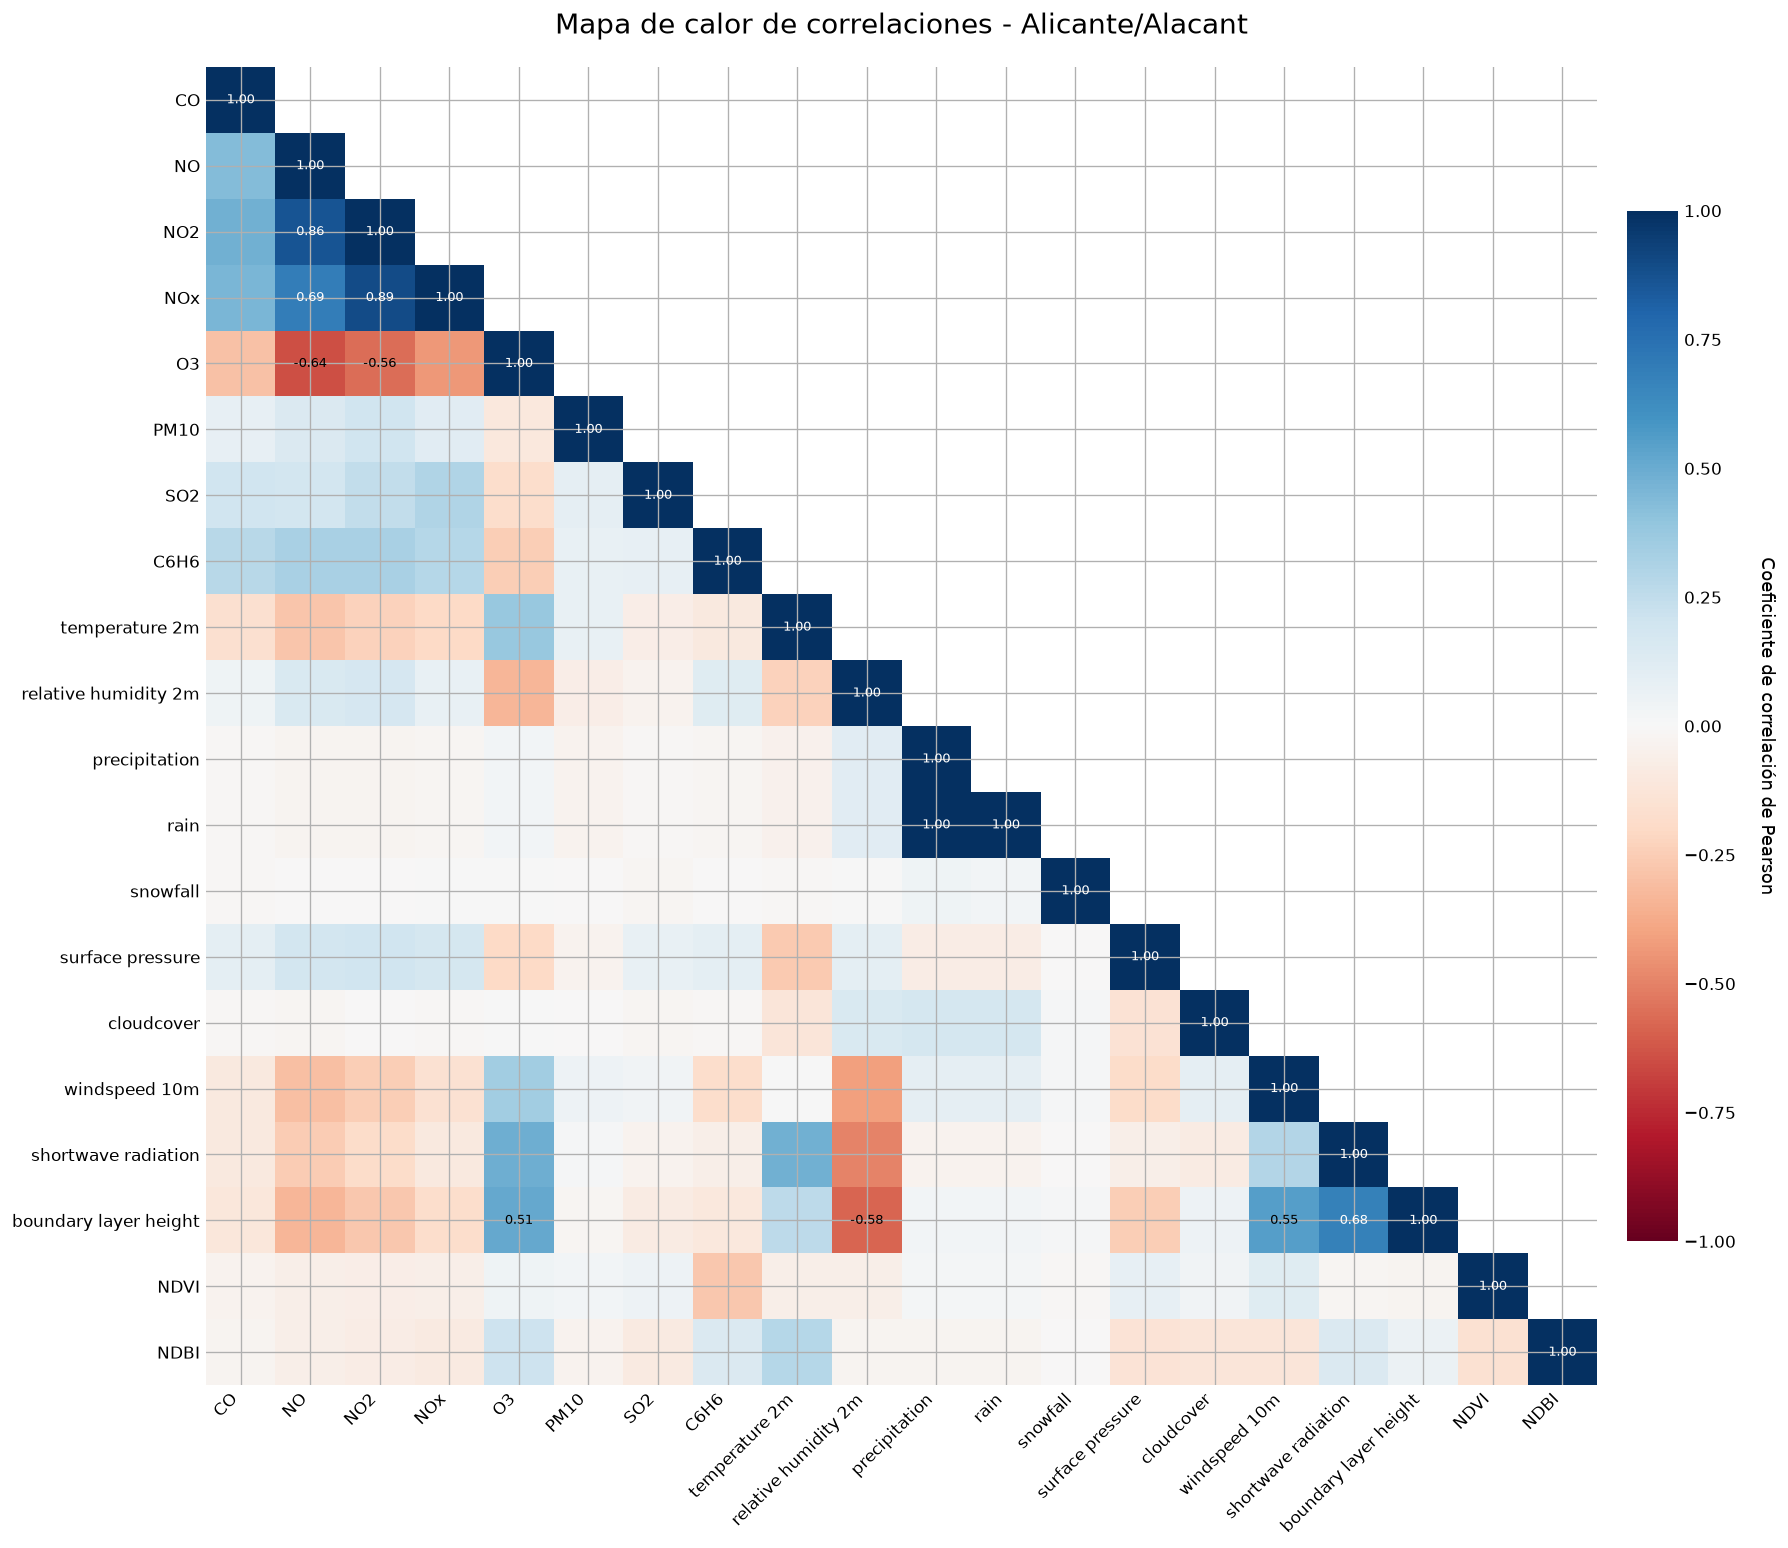

Generando matriz de correlación para: Barcelona


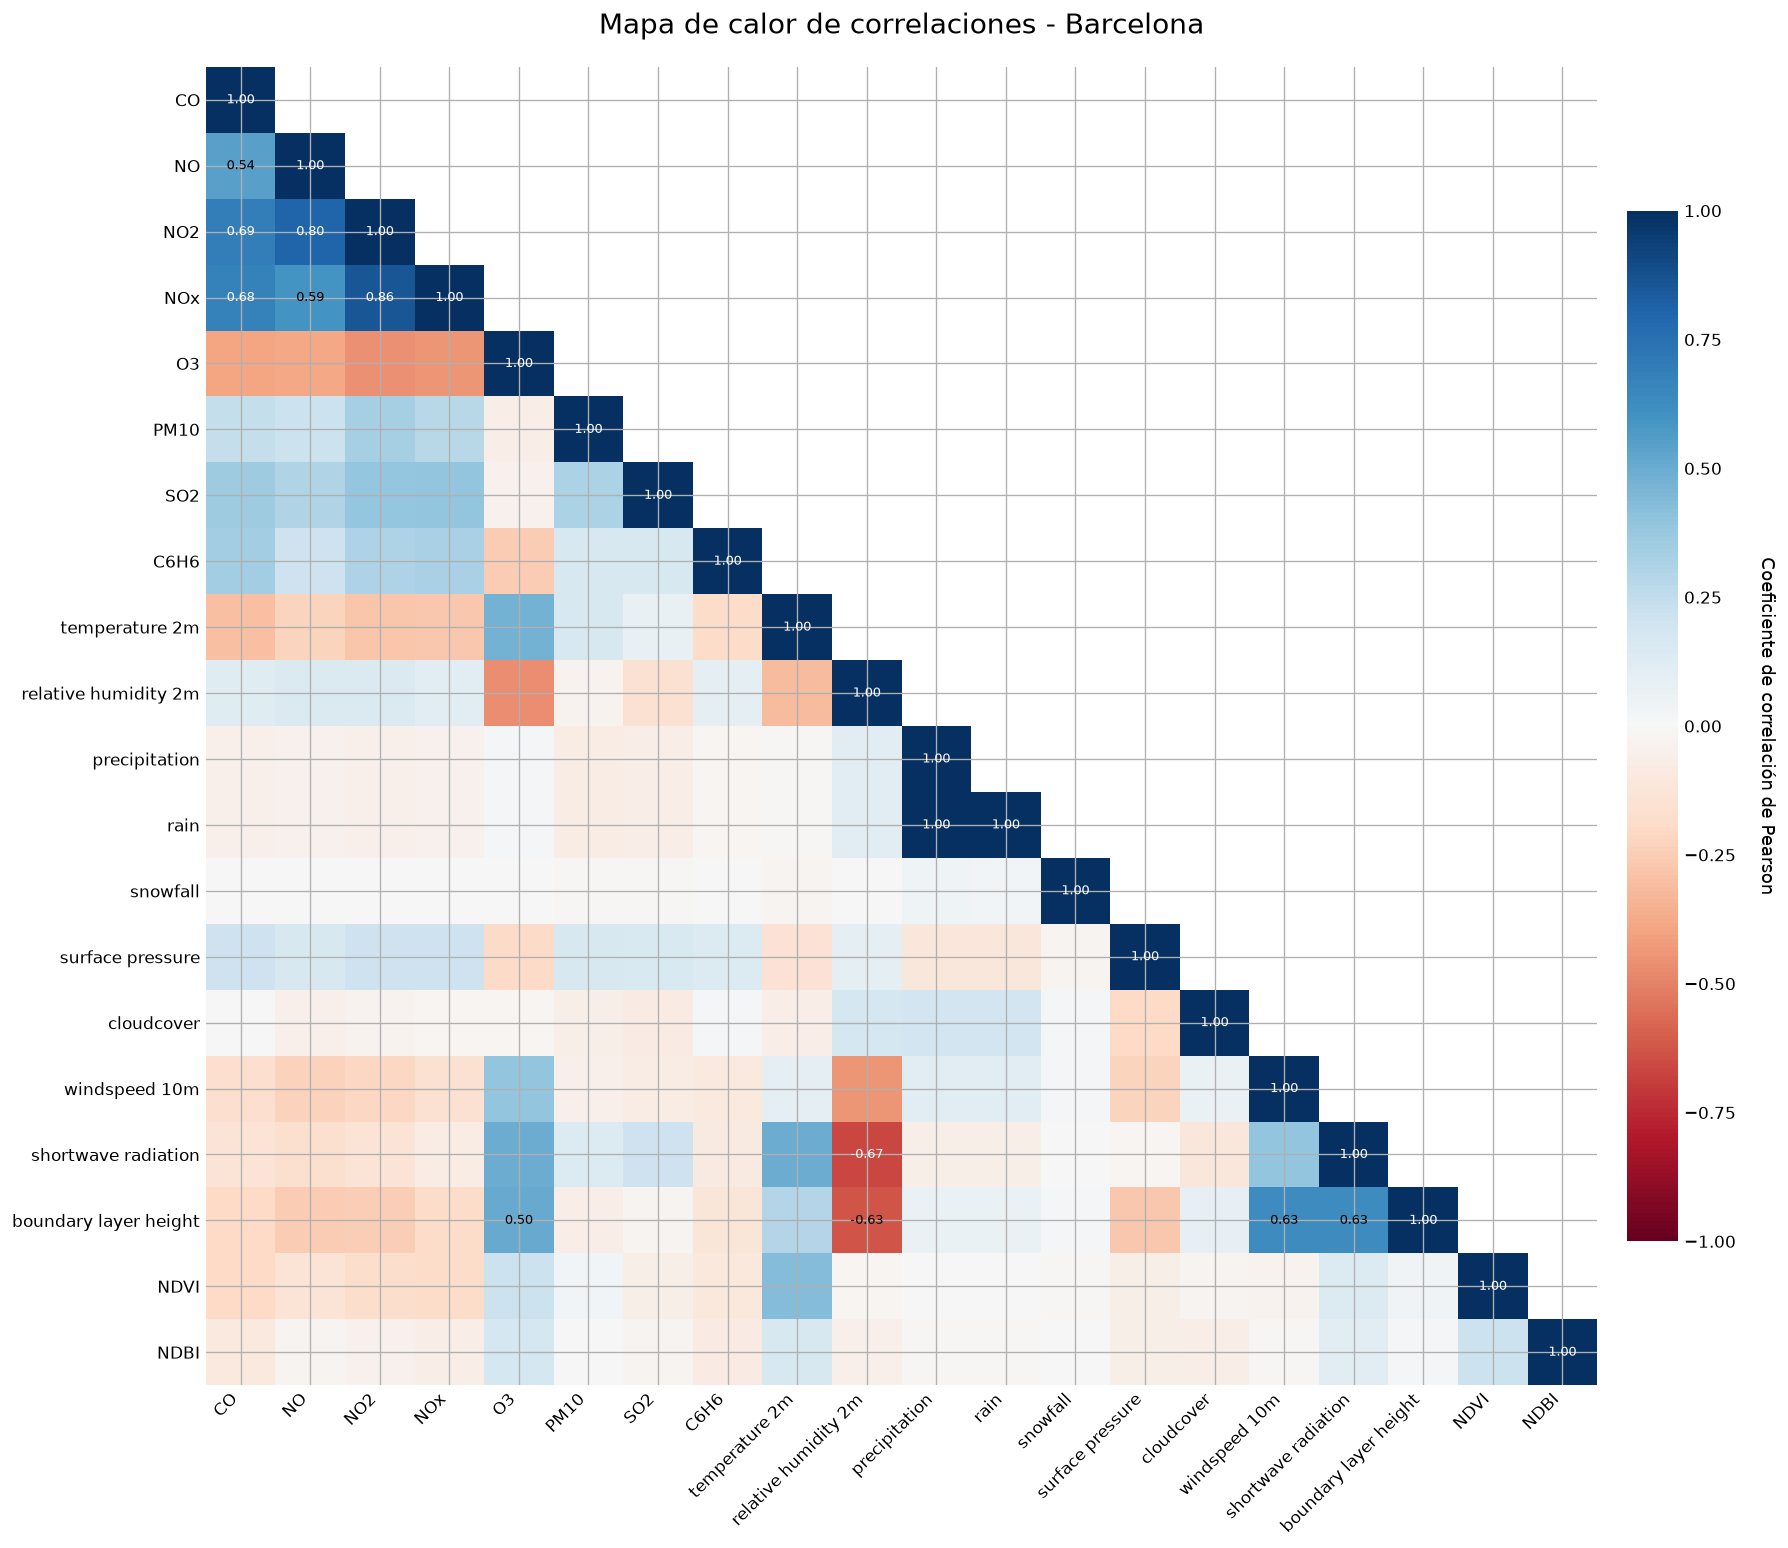

Generando matriz de correlación para: Bilbao


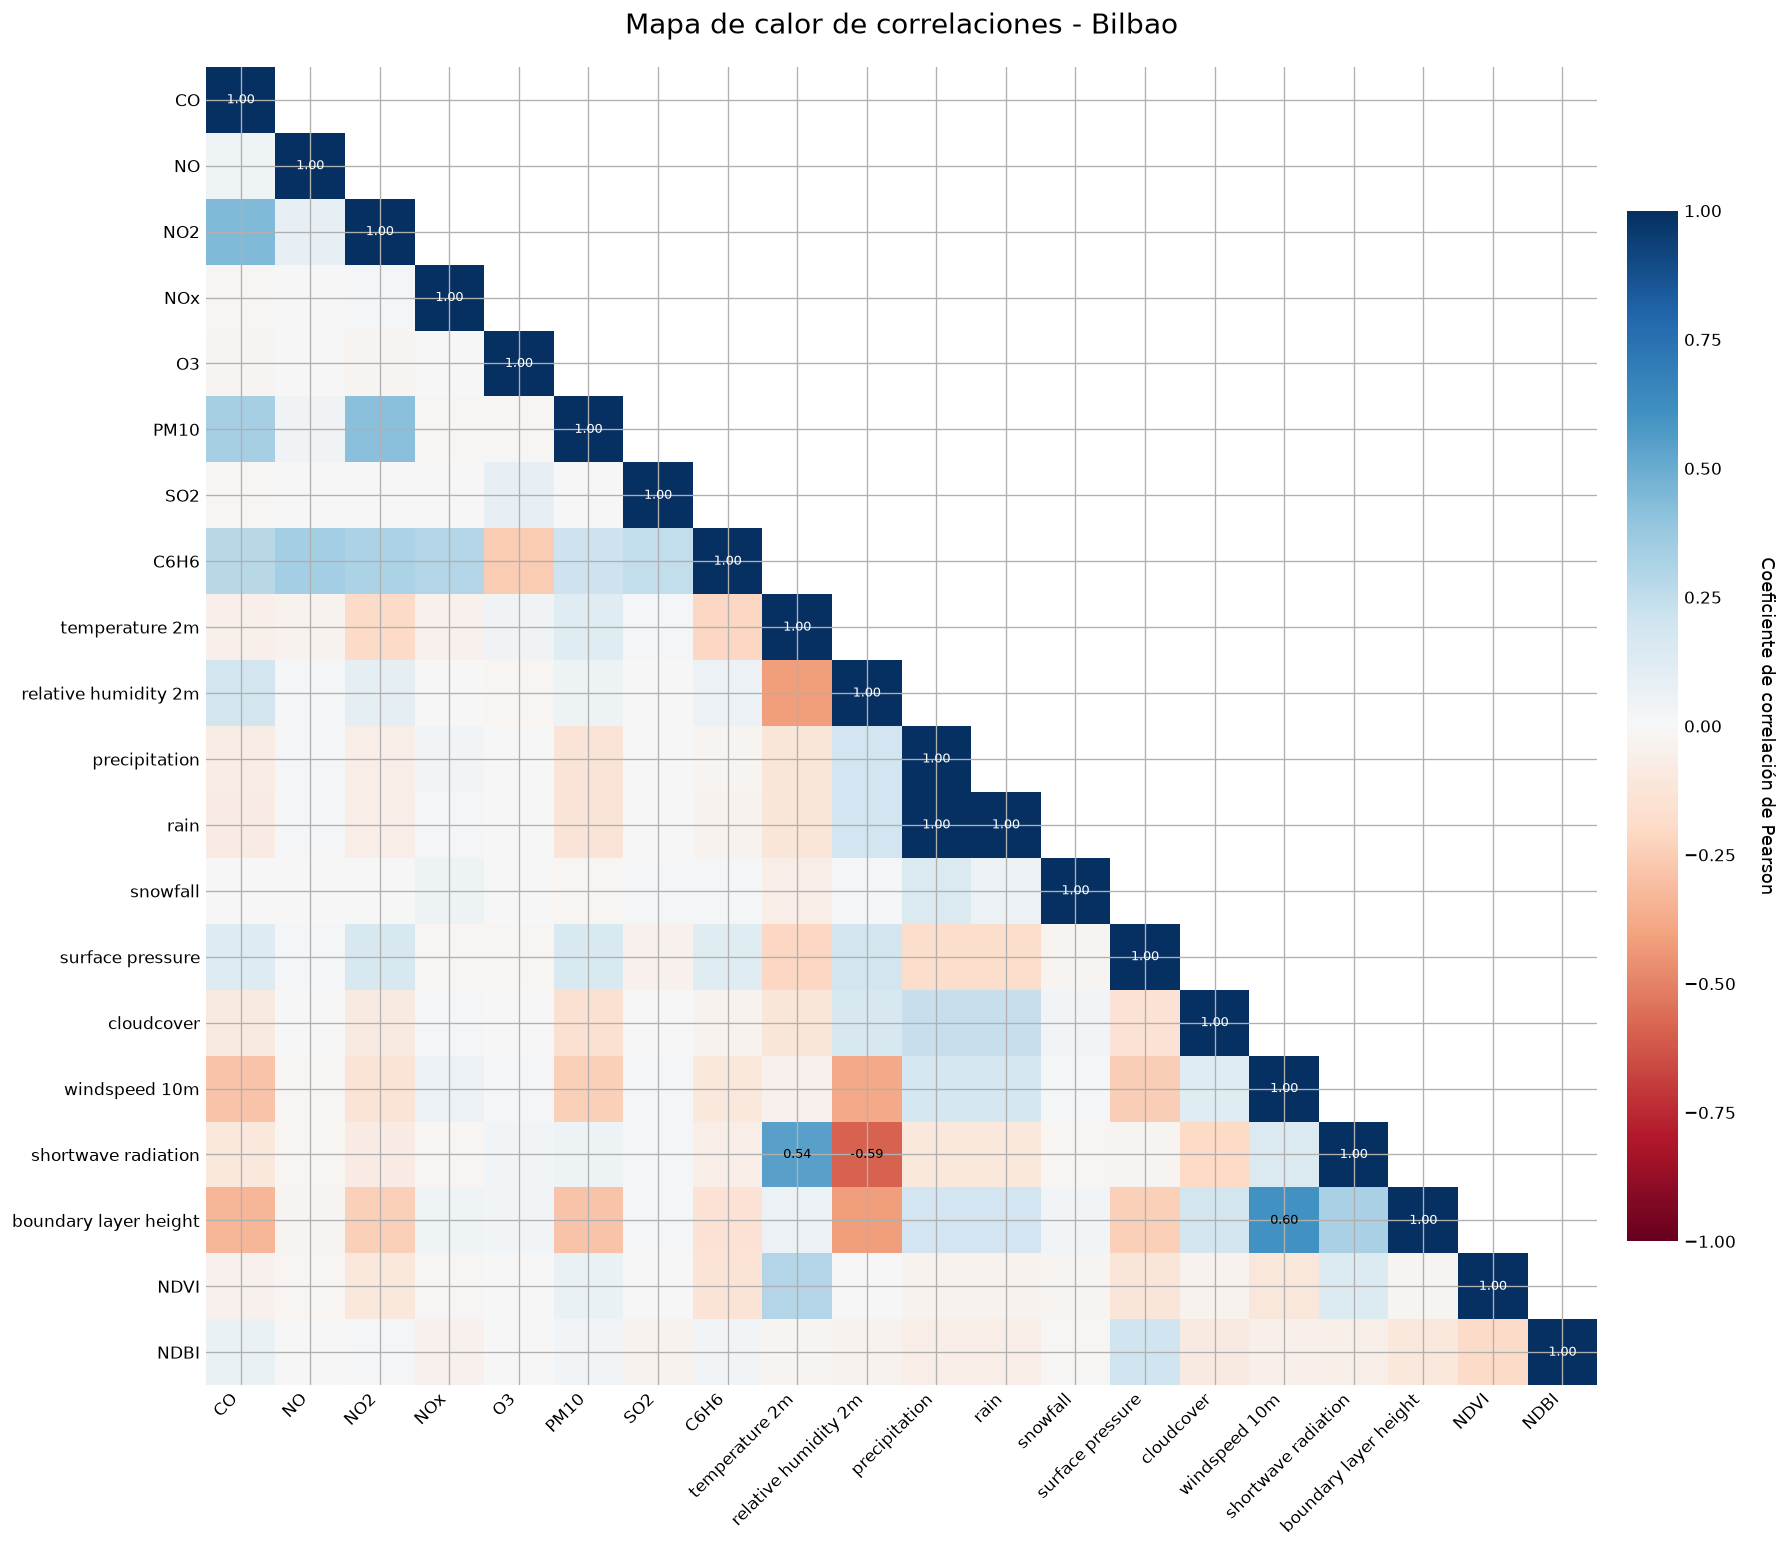

Generando matriz de correlación para: Madrid


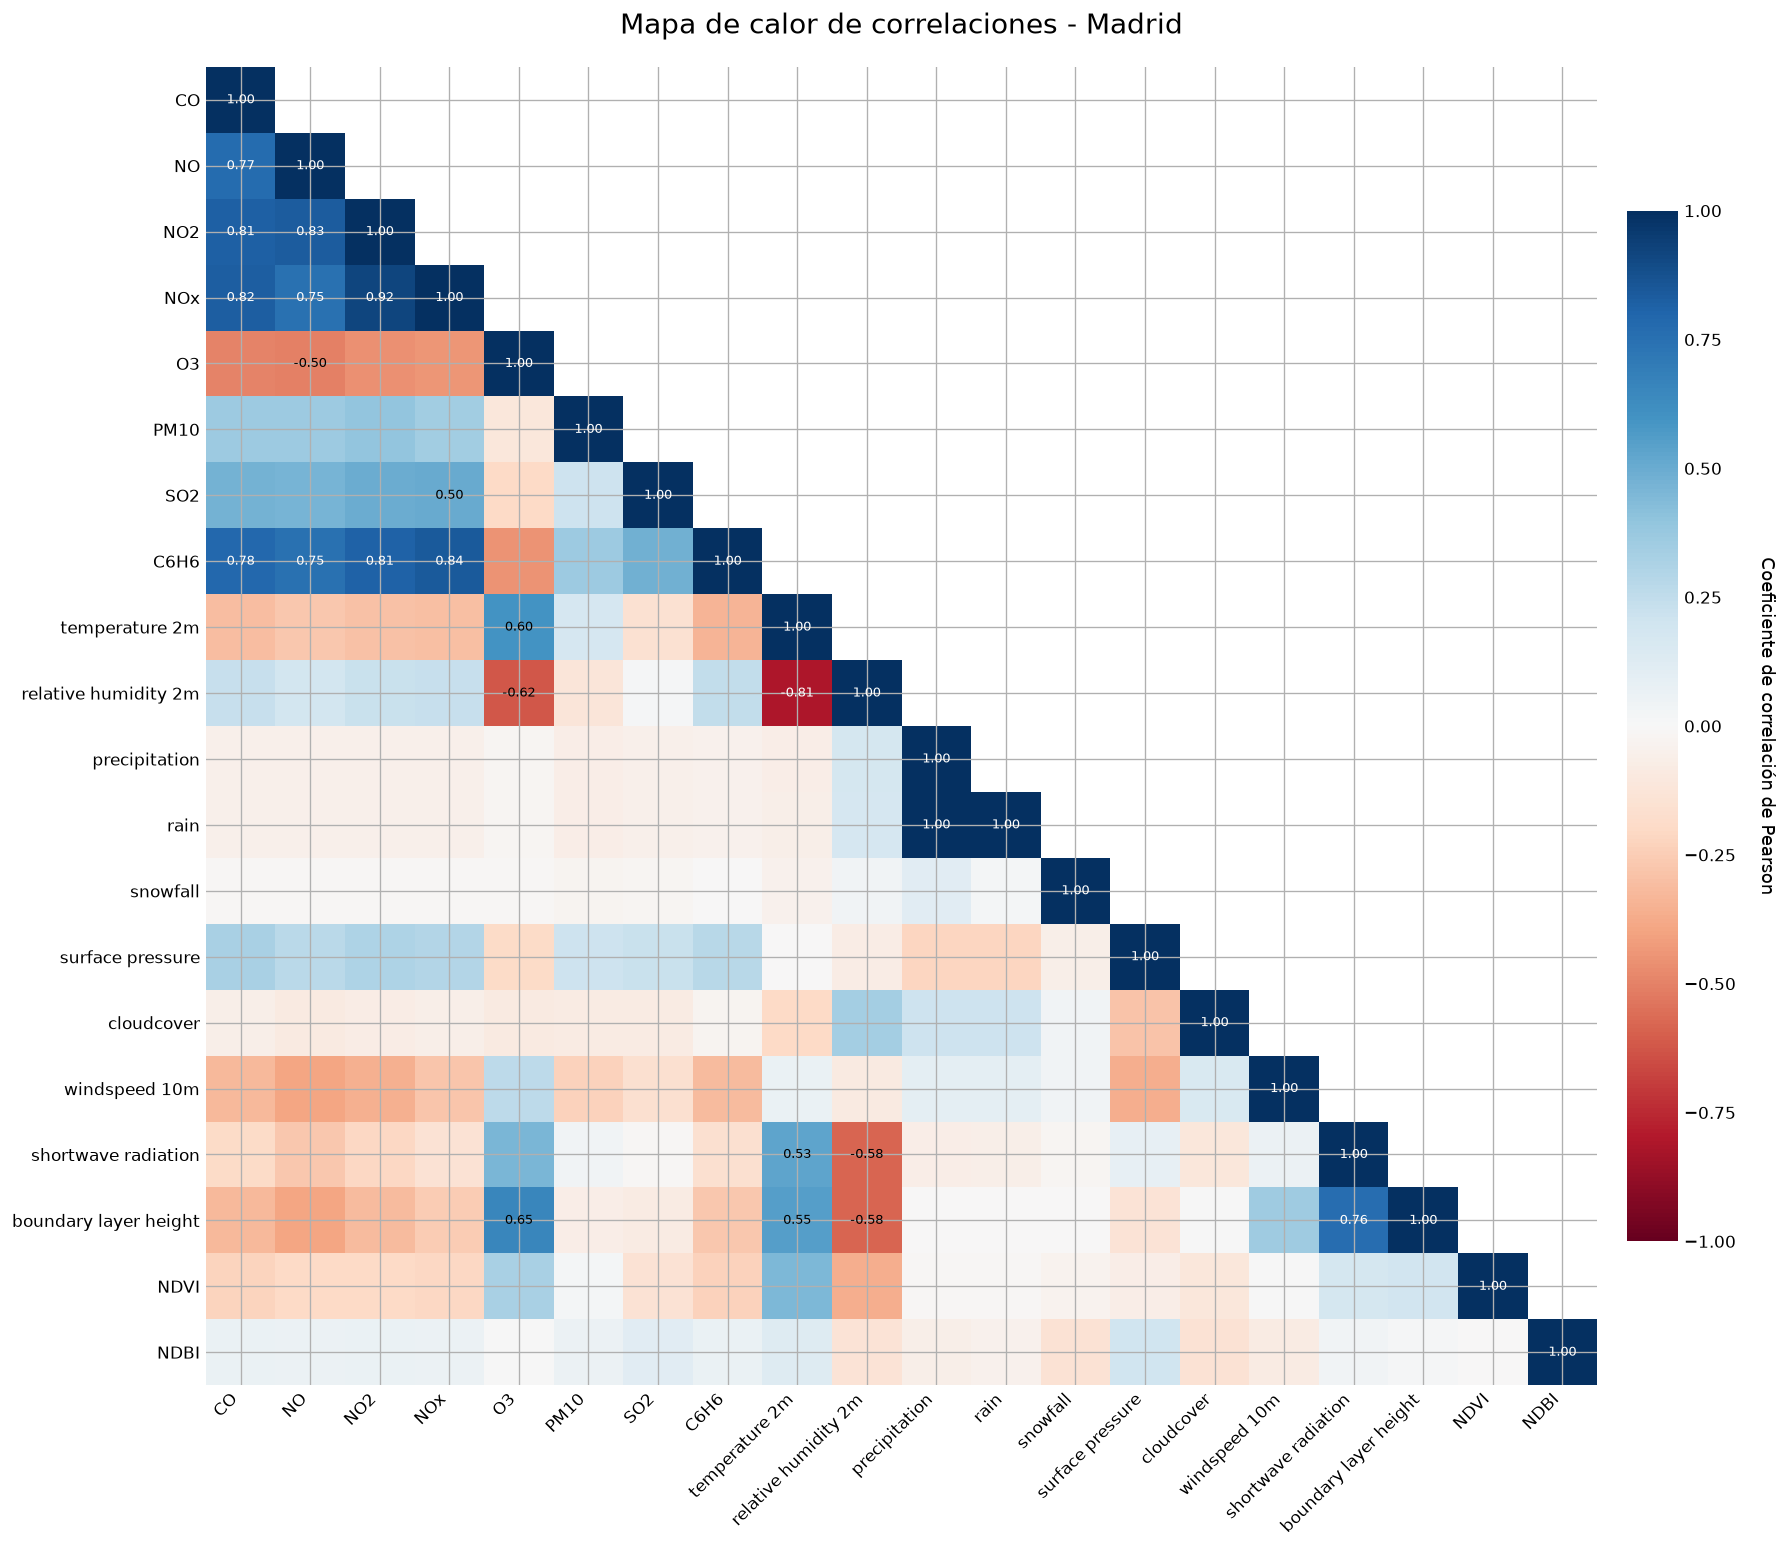

Generando matriz de correlación para: Murcia


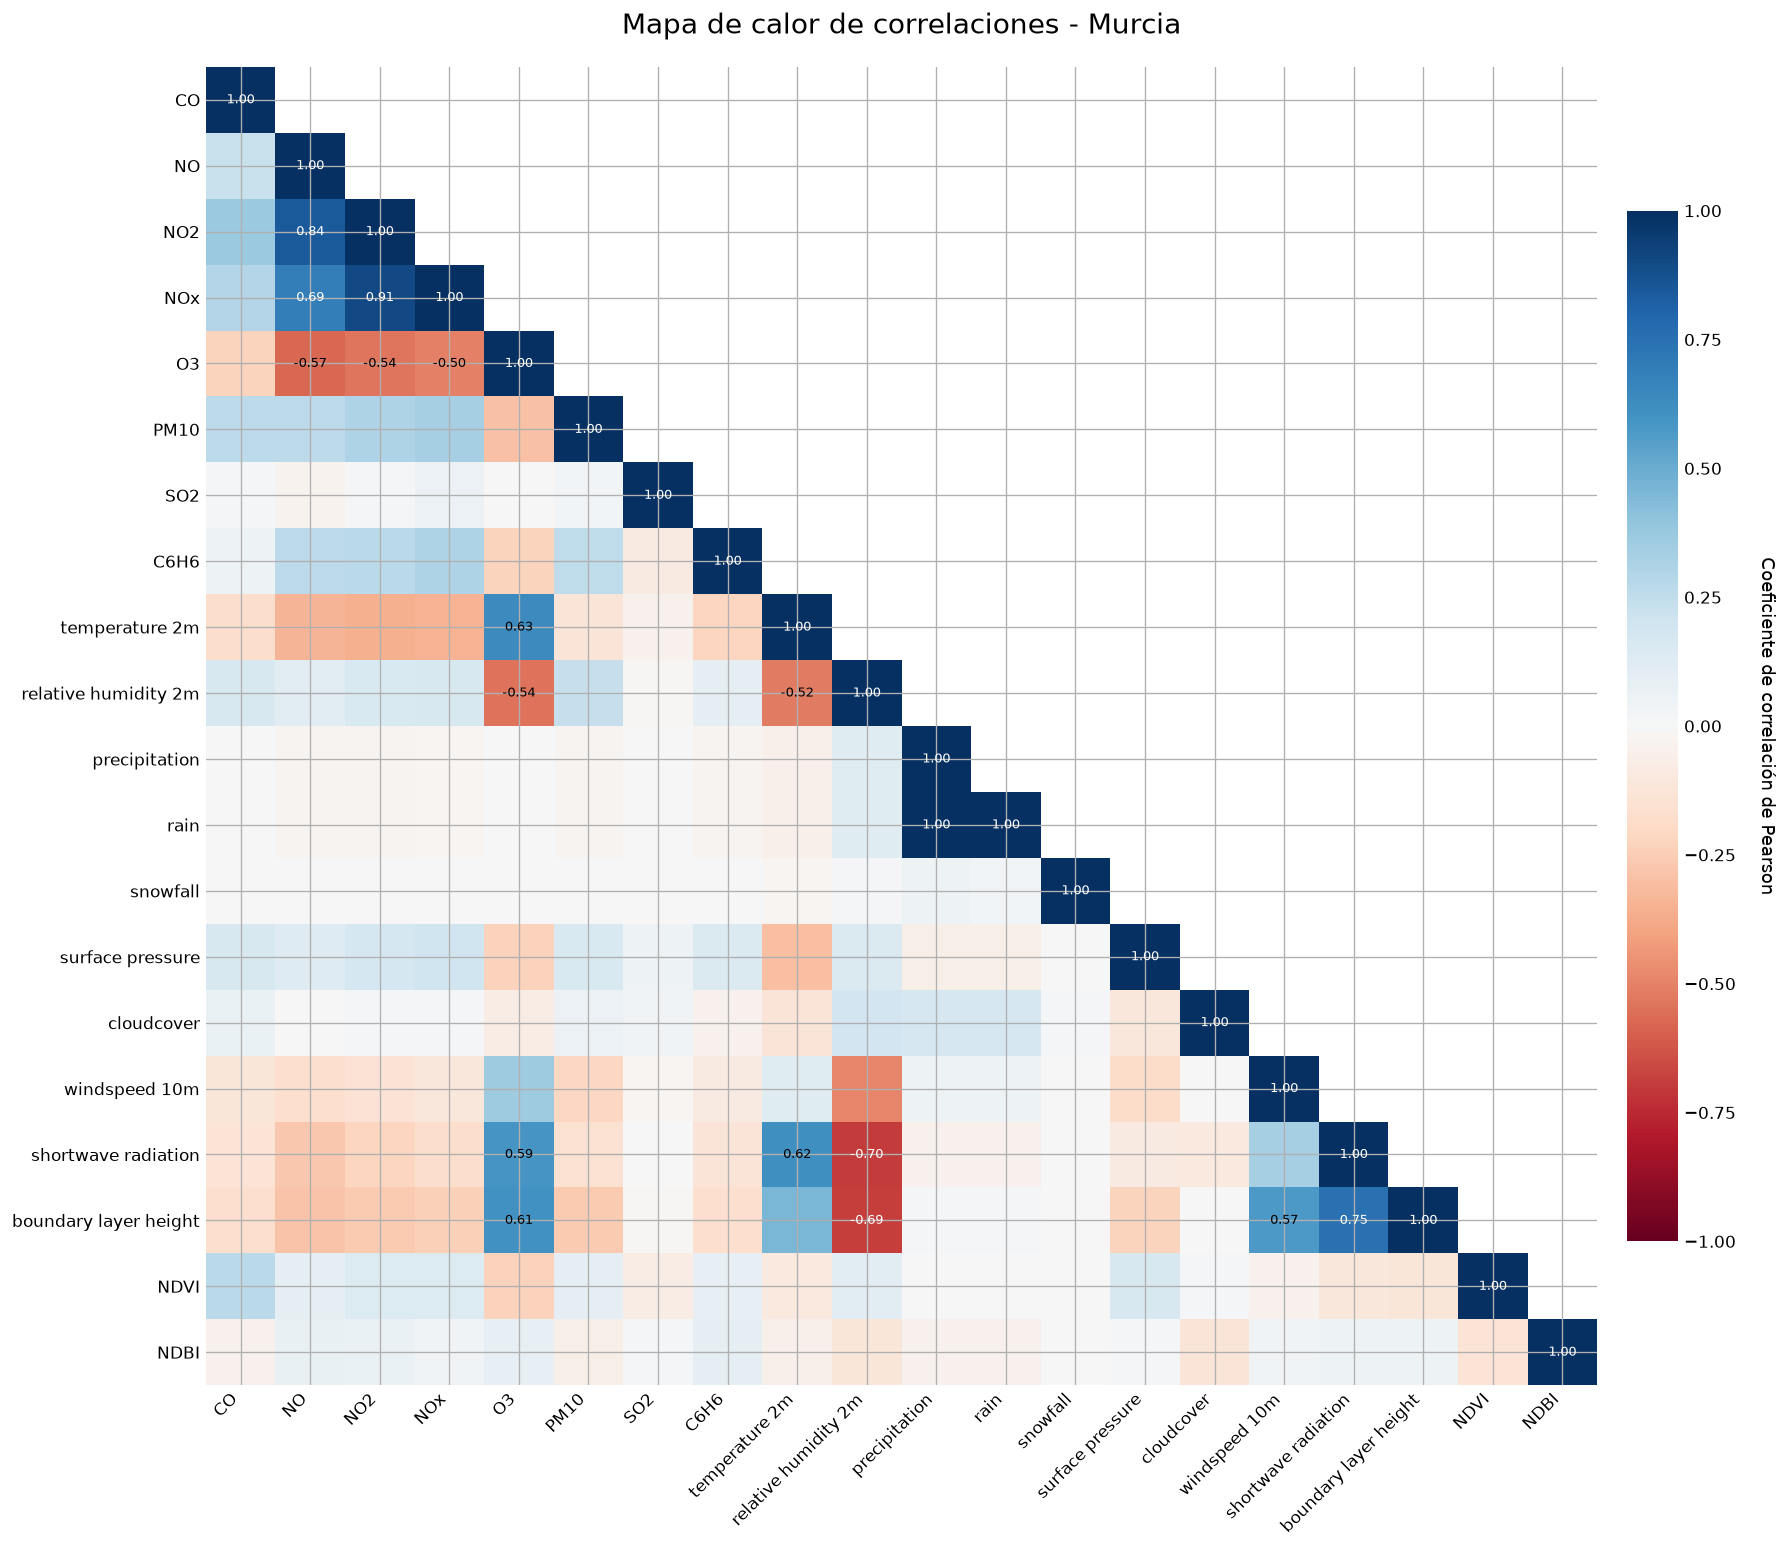

Generando matriz de correlación para: Santa Cruz de Tenerife


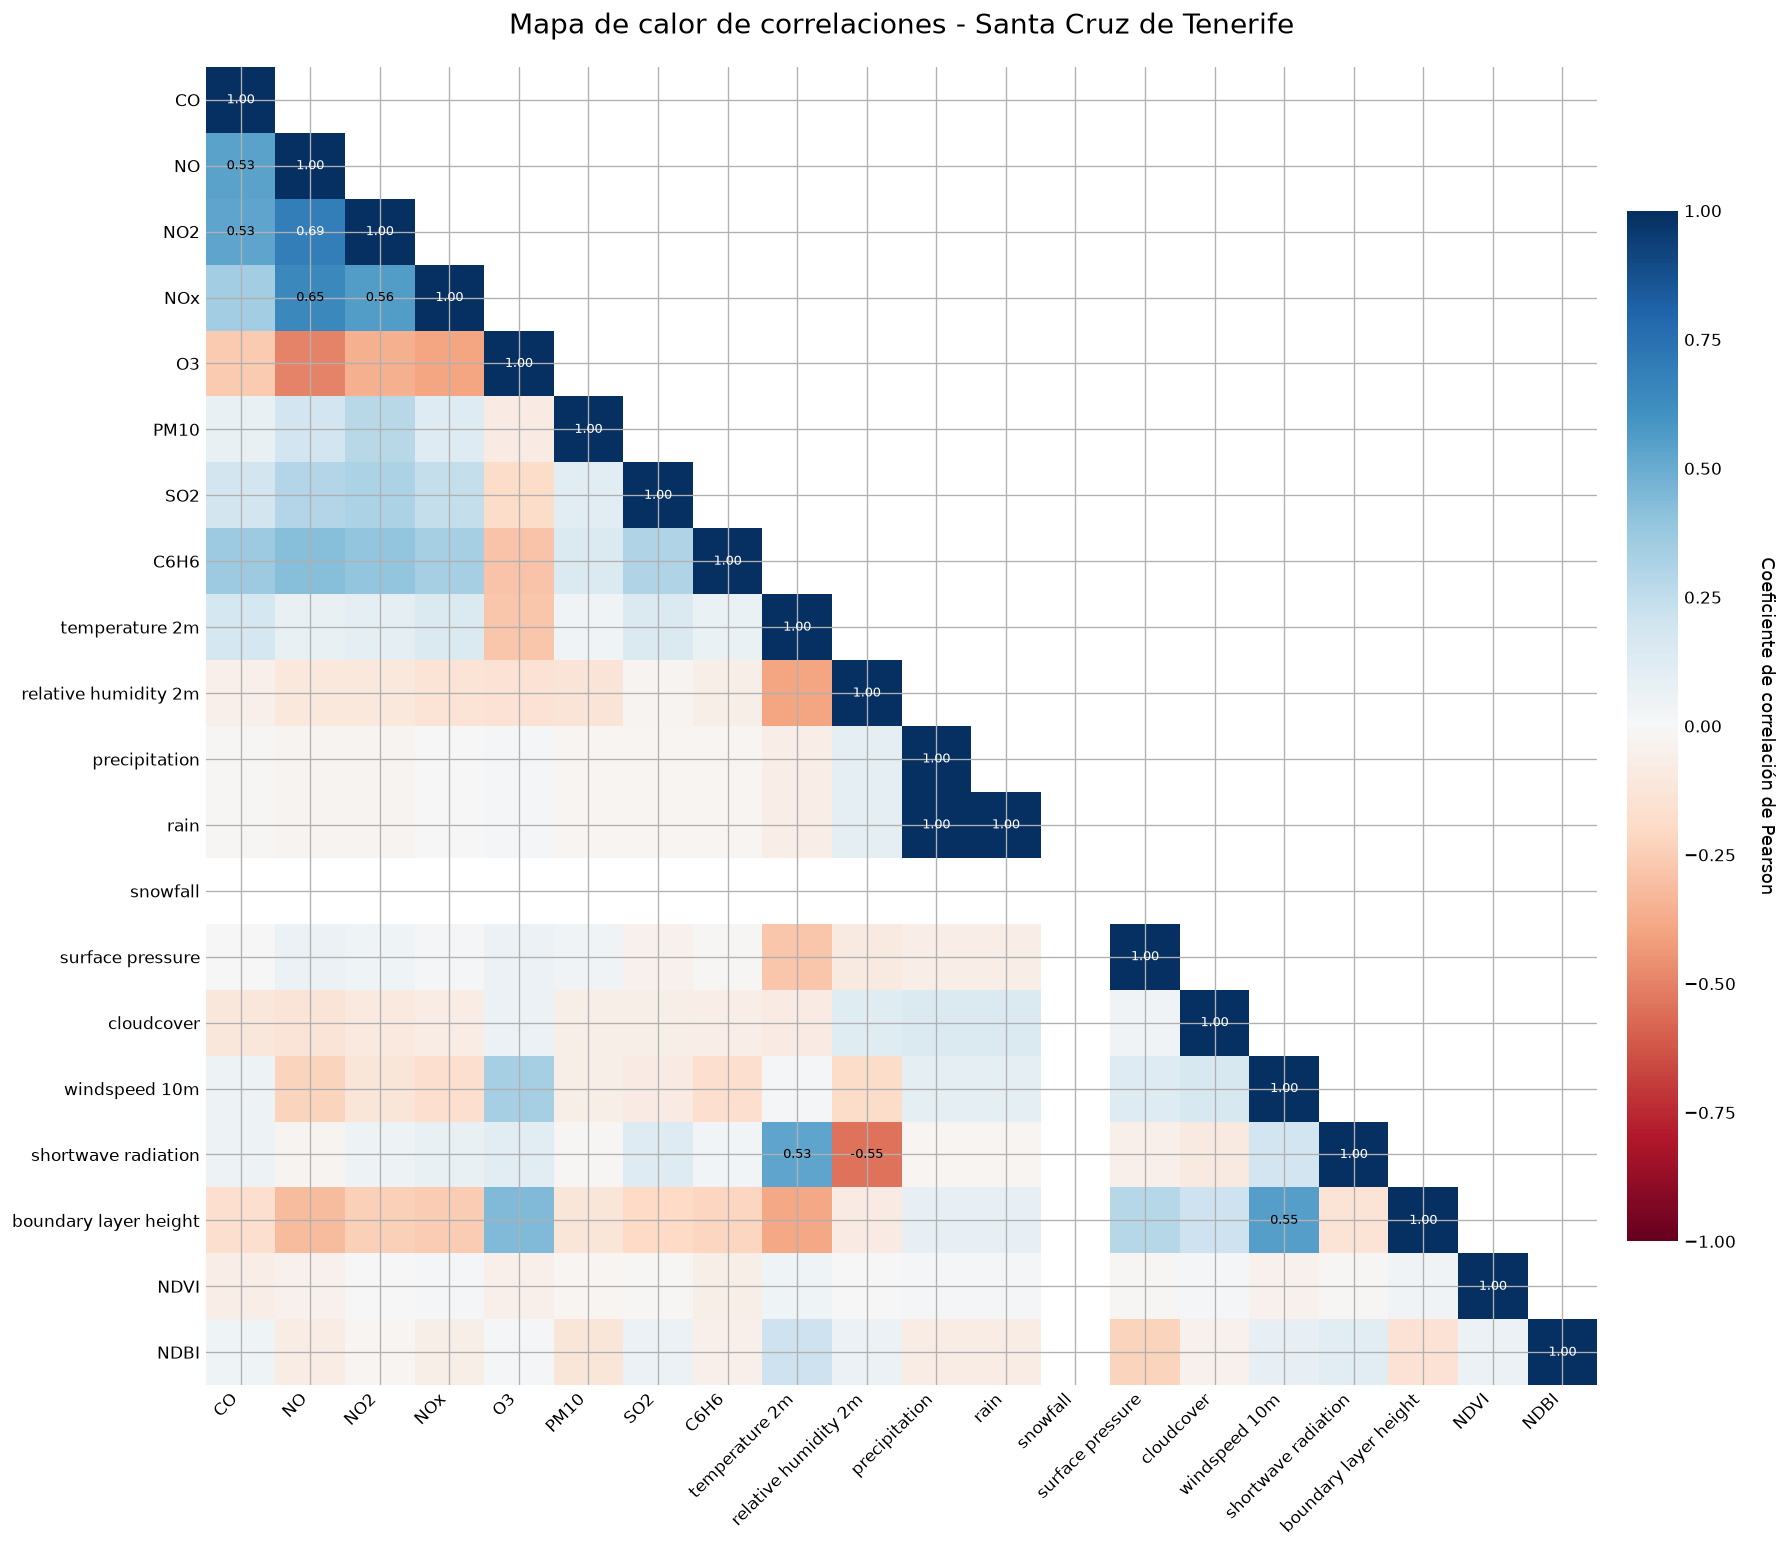

Generando matriz de correlación para: Sevilla


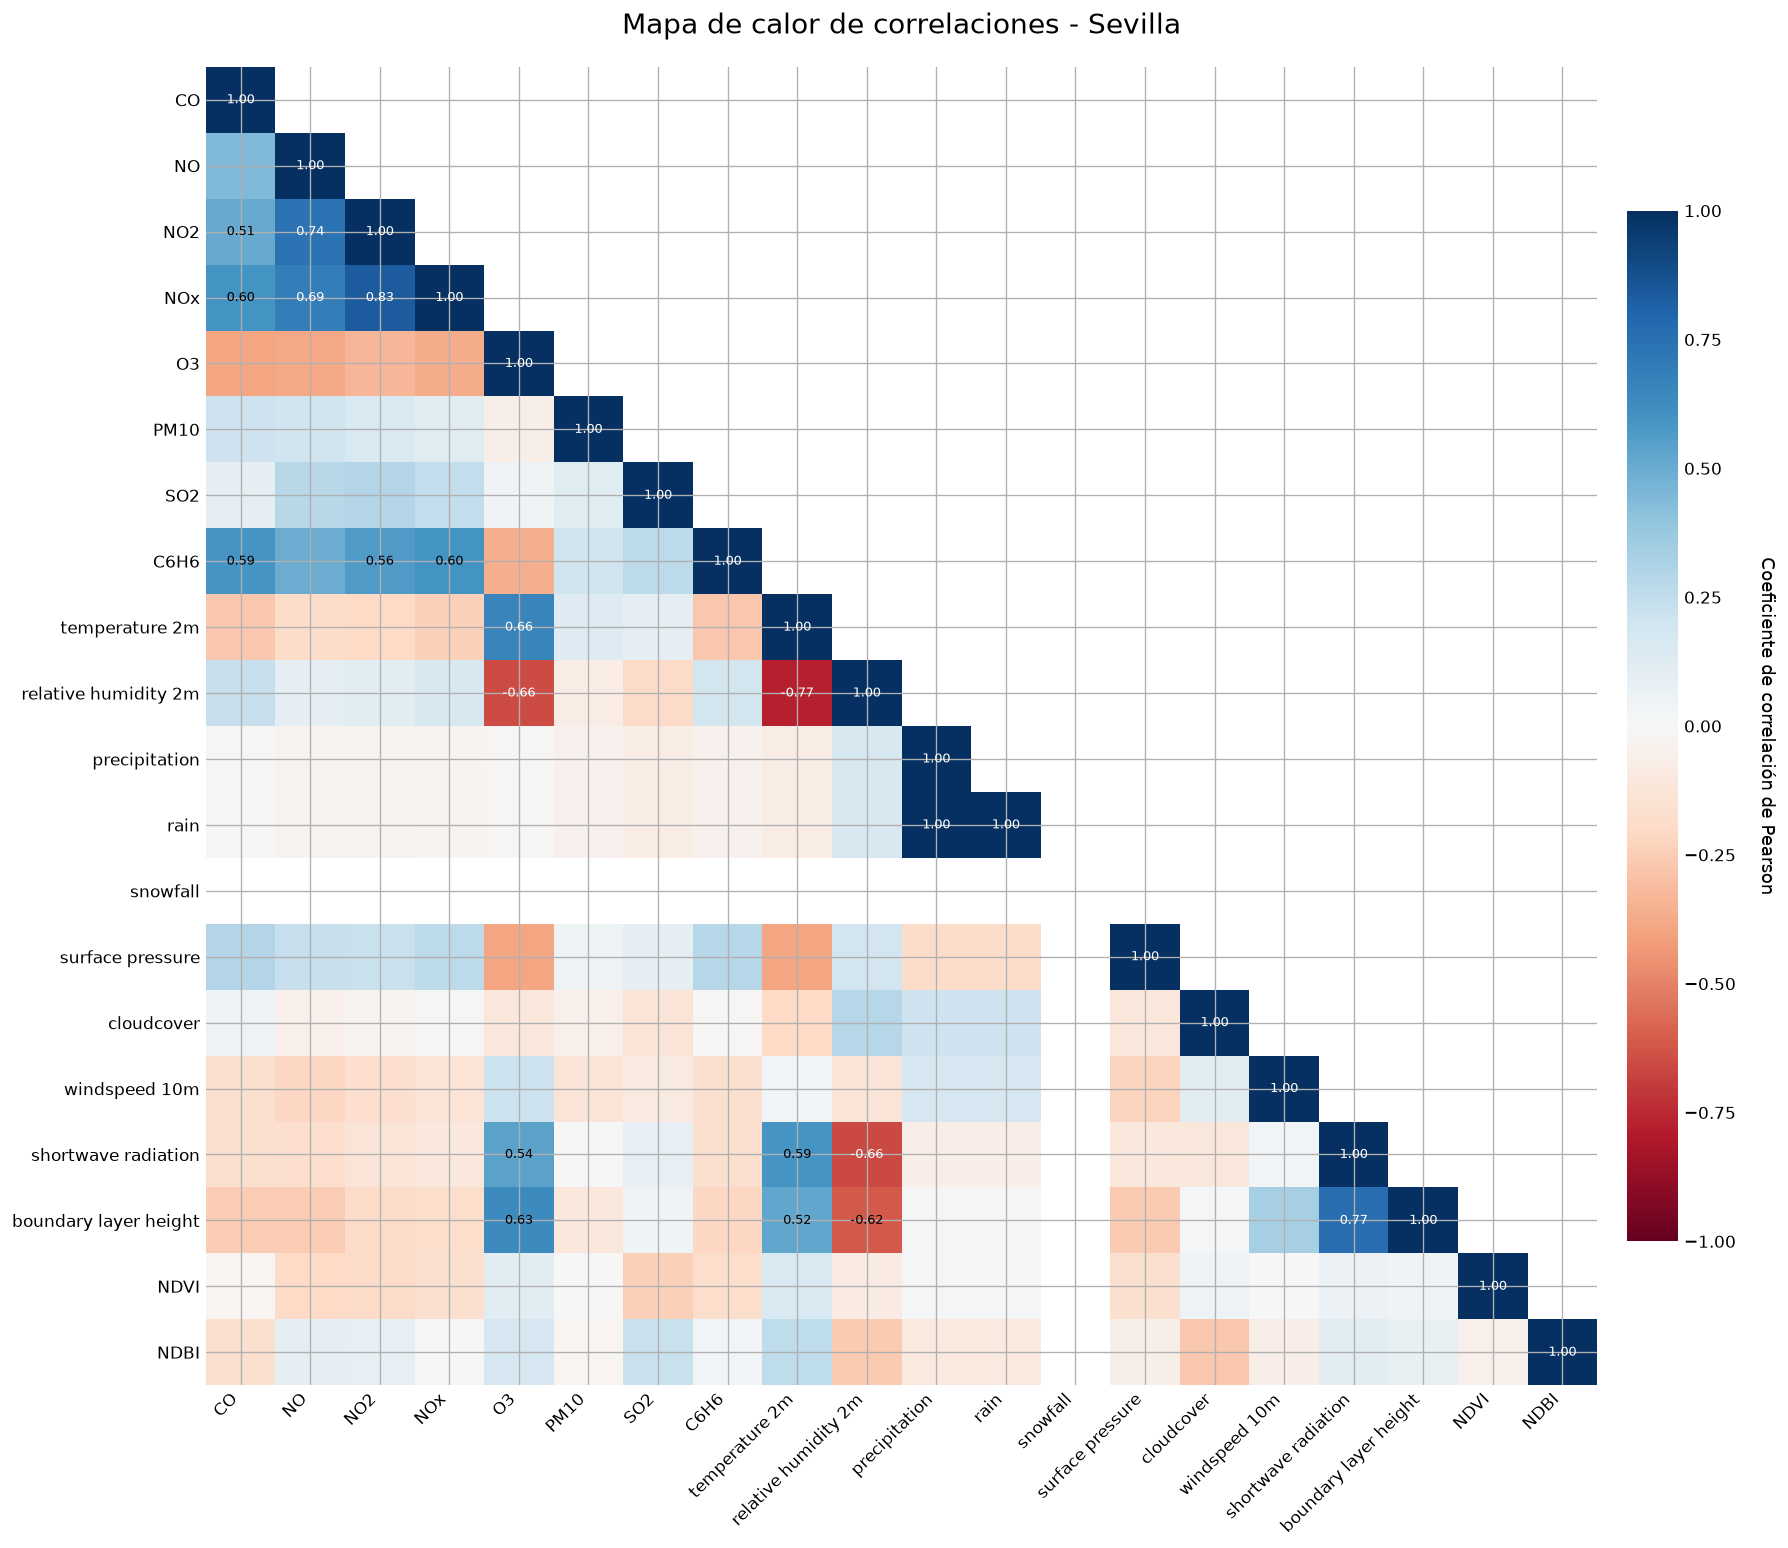

Generando matriz de correlación para: Valencia


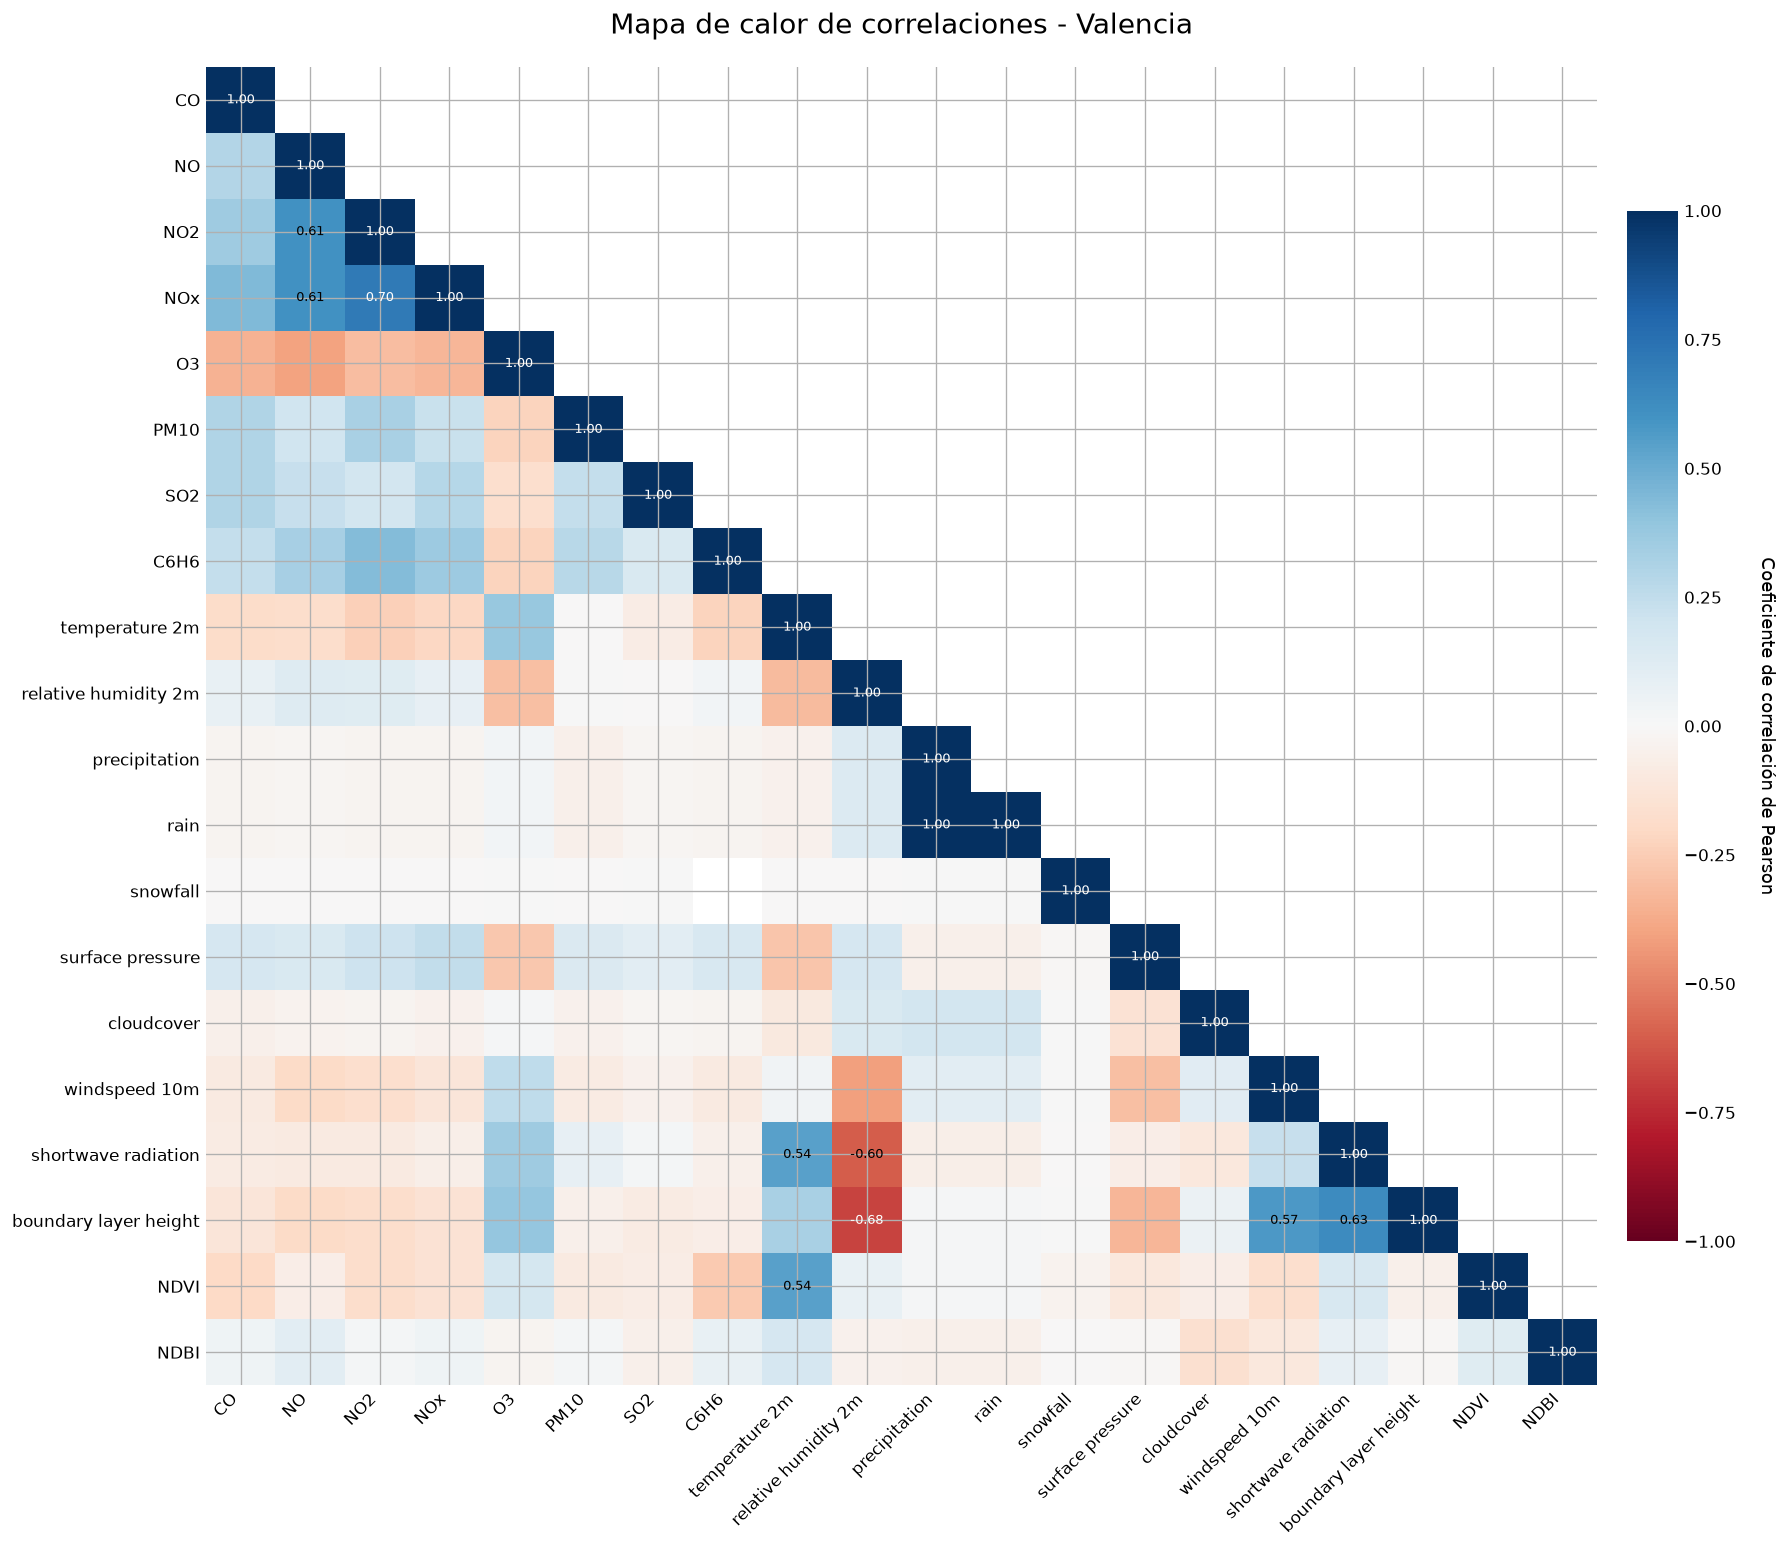

Generando matriz de correlación para: Valladolid


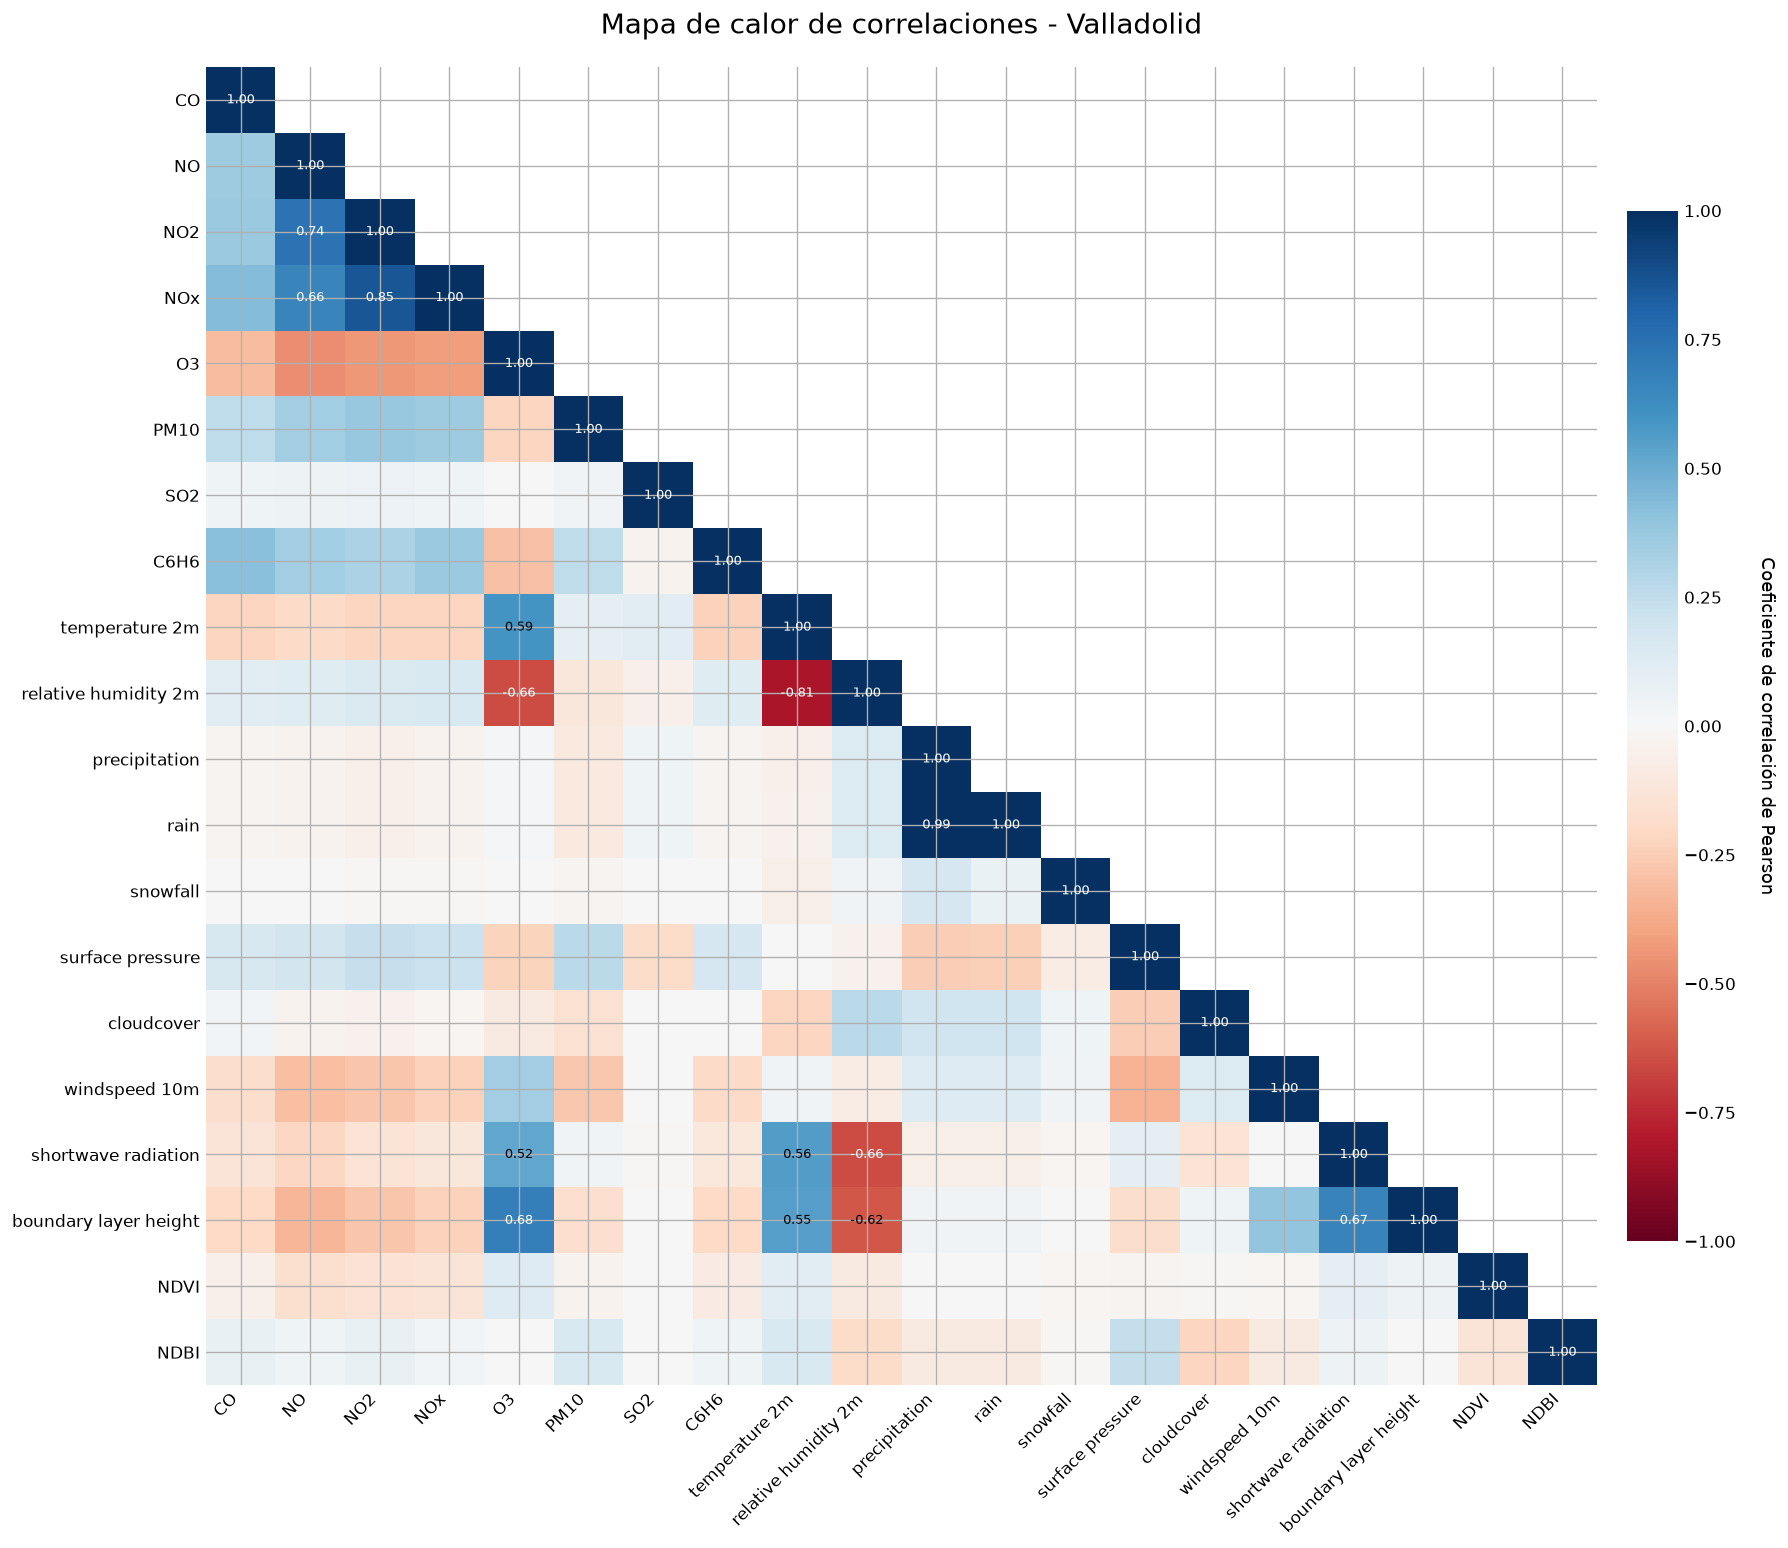

Generando matriz de correlación para: Zaragoza


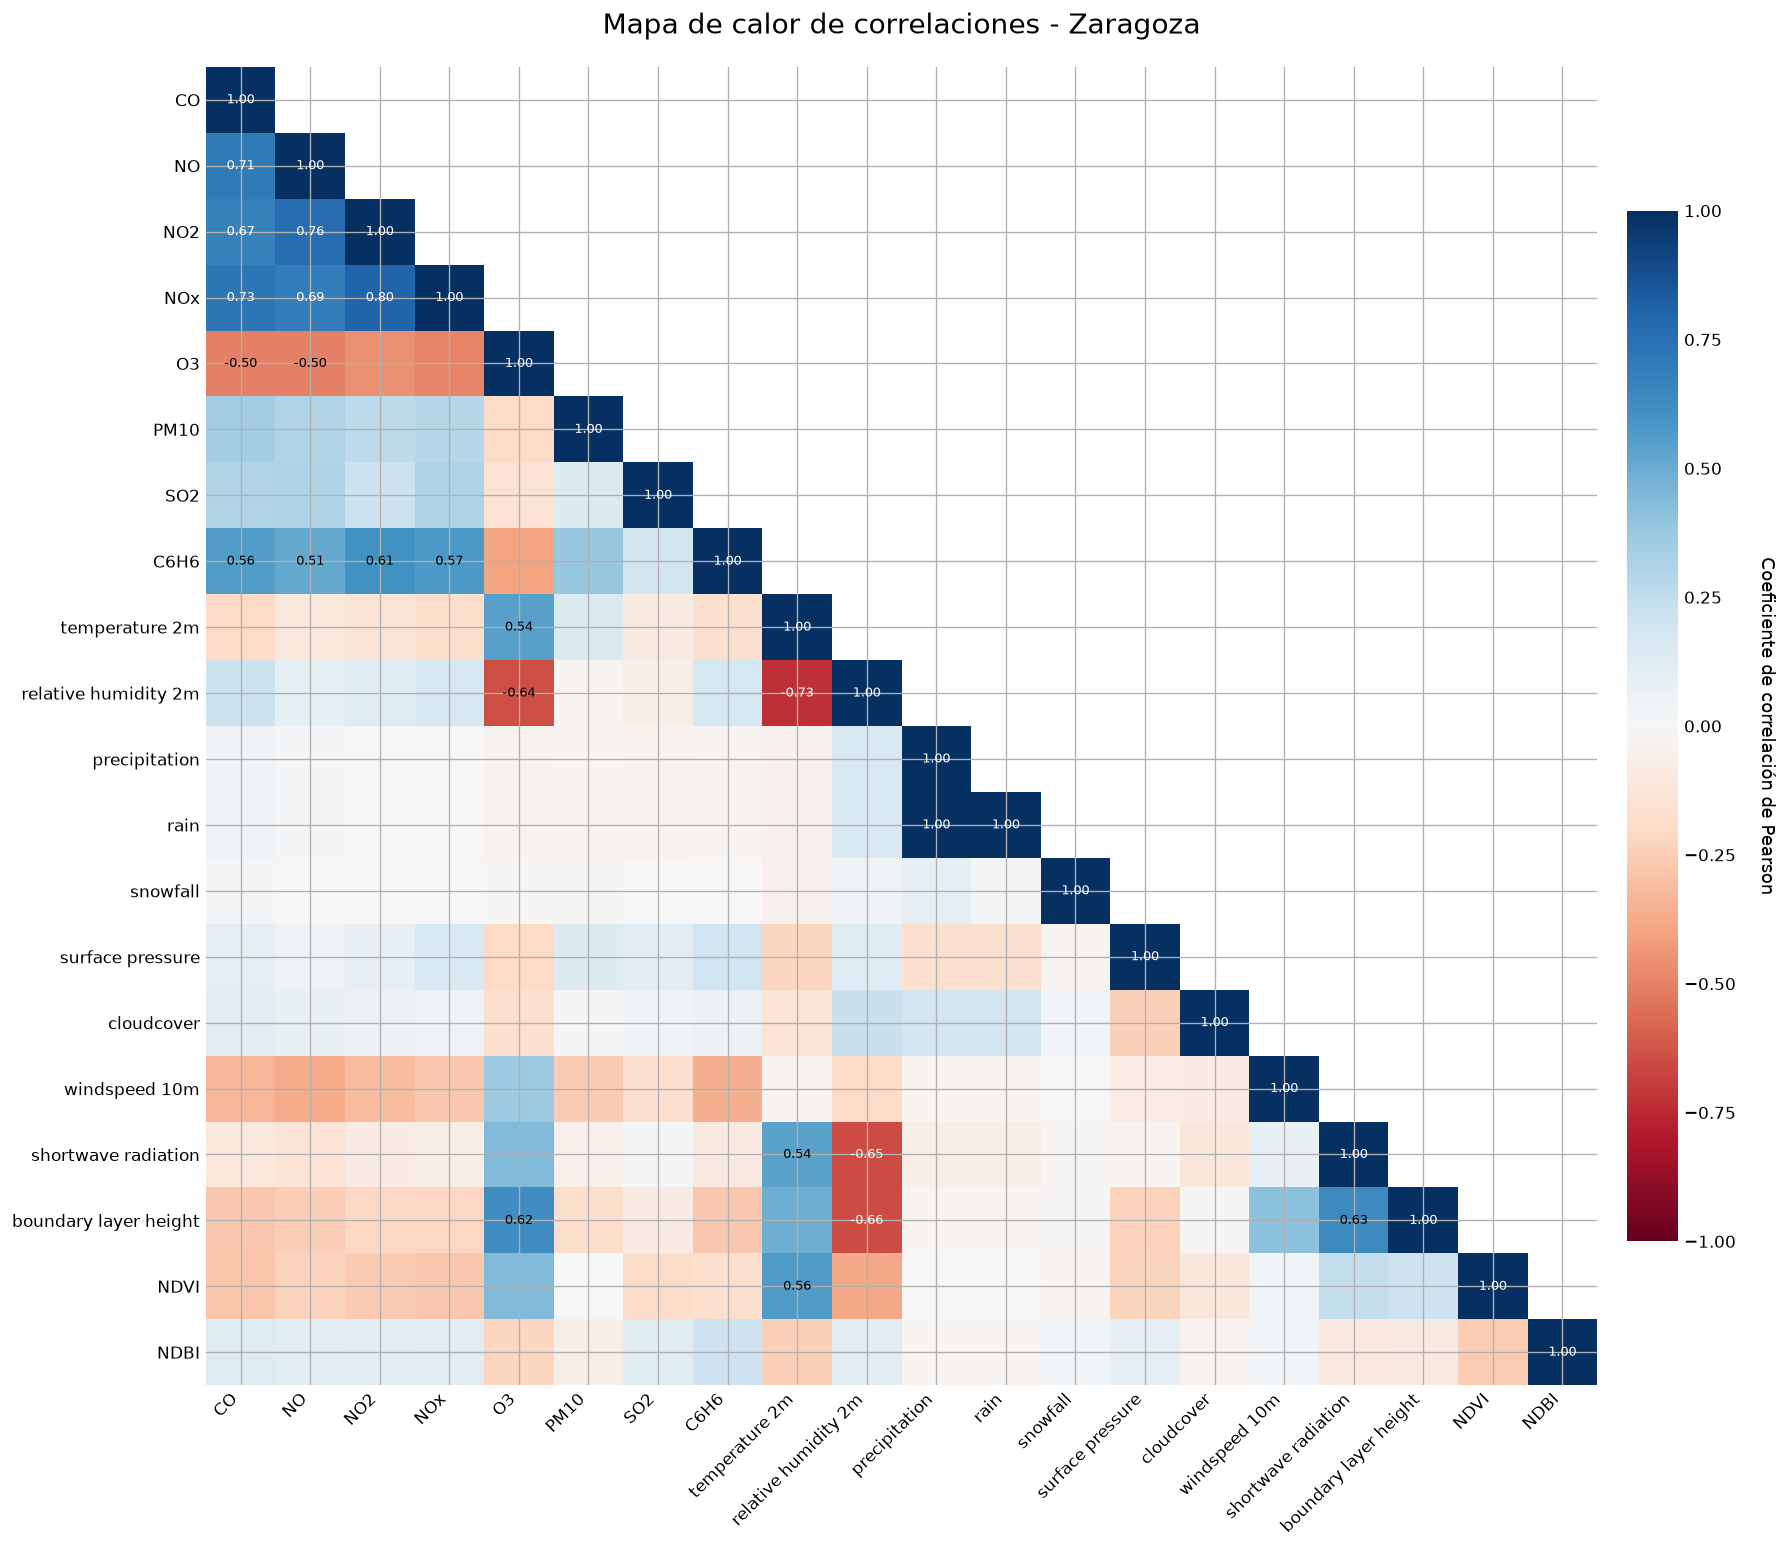

In [47]:
# -----------------------------------------------------------------------------
# 1. VARIABLES A INCLUIR
# -----------------------------------------------------------------------------

variables_correlacion = (
    columnas_contaminantes
    + columnas_clima
    + columnas_indices
)

variables_correlacion = [
    variable for variable in variables_correlacion
    if variable in df.columns
]


# -----------------------------------------------------------------------------
# 2. CONVERSIÓN A NUMÉRICO
# -----------------------------------------------------------------------------

for variable in variables_correlacion:
    df[variable] = pd.to_numeric(df[variable], errors="coerce")


# -----------------------------------------------------------------------------
# 3. FUNCIÓN PARA LIMPIAR ETIQUETAS
# -----------------------------------------------------------------------------

def limpiar_etiqueta_variable(nombre):
    """
    Limpia el nombre de las variables para que las etiquetas del gráfico
    sean más legibles.
    """

    nombre_limpio = nombre

    nombre_limpio = nombre_limpio.replace(" (ug.m-3)", "")
    nombre_limpio = nombre_limpio.replace(" (mg.m-3)", "")
    nombre_limpio = nombre_limpio.replace("_", " ")

    return nombre_limpio


# -----------------------------------------------------------------------------
# 4. GENERACIÓN DE UN MAPA DE CALOR POR CIUDAD
# -----------------------------------------------------------------------------

ciudades_ordenadas = sorted(df["city"].dropna().unique())

for ciudad in ciudades_ordenadas:

    print(f"Generando matriz de correlación para: {ciudad}")

    df_ciudad = df[df["city"] == ciudad].copy()

    # Calculamos correlación de Pearson para esa ciudad.
    matriz_correlacion = df_ciudad[variables_correlacion].corr(method="pearson")

    etiquetas = [
        limpiar_etiqueta_variable(variable)
        for variable in matriz_correlacion.columns
    ]

    # Ocultamos el triángulo superior porque la matriz es simétrica.
    mascara_triangulo_superior = np.triu(
        np.ones_like(matriz_correlacion, dtype=bool),
        k=1
    )

    matriz_mostrada = np.ma.array(
        matriz_correlacion.values,
        mask=mascara_triangulo_superior
    )

    # -------------------------------------------------------------------------
    # Figura
    # -------------------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(15, 13))
    fig.patch.set_facecolor("white")

    cmap = plt.colormaps["RdBu"].copy()
    cmap.set_bad(color="white")

    im = ax.imshow(
        matriz_mostrada,
        cmap=cmap,
        vmin=-1,
        vmax=1,
        aspect="auto"
    )

    # -------------------------------------------------------------------------
    # Ejes
    # -------------------------------------------------------------------------

    ax.set_xticks(np.arange(len(etiquetas)))
    ax.set_yticks(np.arange(len(etiquetas)))

    ax.set_xticklabels(
        etiquetas,
        rotation=45,
        ha="right",
        fontsize=10
    )

    ax.set_yticklabels(
        etiquetas,
        fontsize=10
    )

    ax.tick_params(axis="both", length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(
        f"Mapa de calor de correlaciones - {ciudad}",
        fontsize=17,
        pad=20
    )

    # -------------------------------------------------------------------------
    # Valores de correlación
    # -------------------------------------------------------------------------

    for i in range(matriz_correlacion.shape[0]):
        for j in range(matriz_correlacion.shape[1]):

            if mascara_triangulo_superior[i, j]:
                continue

            valor = matriz_correlacion.iloc[i, j]

            if pd.isna(valor):
                continue

            # Mostramos solo correlaciones relevantes para no saturar.
            if i == j or abs(valor) >= 0.5:

                texto = f"{valor:.2f}"
                color_texto = "white" if abs(valor) > 0.65 else "black"

                ax.text(
                    j,
                    i,
                    texto,
                    ha="center",
                    va="center",
                    fontsize=8,
                    color=color_texto
                )

    # -------------------------------------------------------------------------
    # Barra de color
    # -------------------------------------------------------------------------

    cbar = plt.colorbar(
        im,
        ax=ax,
        fraction=0.035,
        pad=0.02
    )

    cbar.outline.set_visible(False)
    cbar.ax.tick_params(labelsize=10, length=0)

    cbar.ax.set_ylabel(
        "Coeficiente de correlación de Pearson",
        rotation=270,
        labelpad=24,
        fontsize=11
    )

    plt.tight_layout()

    # -------------------------------------------------------------------------
    # Guardado
    # -------------------------------------------------------------------------

    nombre_ciudad_limpio = normalizar_texto(ciudad)

    # Define la ruta del directorio de destino
    ruta_destino = FOLDER_FIGS / "correlaciones"

    # Crea la carpeta y subcarpetas si no existen
    ruta_destino.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        ruta_destino / f"mapa_calor_correlaciones_{nombre_ciudad_limpio}.png",
        bbox_inches="tight",
        dpi=180,
        facecolor="white"
    )

    plt.show()

1. Para **La Coruña**, obervamos que están positivamente correlacionados el NO2 con el NO; el NOx con el NO y el NO2; la temperatura con la radiación solar y el índice NDBI; y, la velocidad del viento con la PBLH. Únicamente están correlacionadas negativamente la radiación solar con la lluvia.

2. Para **Albacete**, están positivamente correlacionados el NO2 con el NO; el NOx con el NO y el NO2; el 03 con la temperatura y la PBLH; la temperatura con la PBLH; y, la radiación solar y la PBLH con la radiación solar. Por su parte, están correlacionadas negativamente el 03 con el NO y la humedad relativa; la temperatura con la humedad relativa; la humedad relativa con la PBLH; y, la radiación solar.

3. Para **Alicante**, están correlacionados positivamente el NO2 con el NO; el NOx con el NO y el NO2; y, la PBLH con el O3, la velocidad del viento y la radiación solar. Además, estan negativamente correlacionados el O3 con el NO y el NO2; y, la humedad relativa con la PBLH.

4. Para **Barcelona**, se encuentran positivamente correlacionadas el CO con el NO, el NO2 y el NOx; el NO con el NO2 y el NOx; el NO2 con el NOx; y, la PBLH con el O3, la velocidad del viento y la radiación solar. Por otro lado, aparece correlacionada negativamente la humedad relativa con la radiación solar y la PBLH.

5. Para **Bilbao**, está correlacionadas positivamente la temperatura con la radiación solar y la PBLH con la velocidad del viento, y está negativamente correlacionada la radiación solar con la humedad relativa.

6. Para **Madrid**, aparecen correlacionadas positivamente el CO con el NO, el NO2 y el NOx; el NO con el NO2 y el NOx; el NO2 con el NOx; el C6H6 con el CO, el NO, el NO2 y el NOx; el NOx con el SO2; el O3 con la temperatura y la PBLH; la temperatura con la radiación solar y la PBLH; y, la PBLH con la radiación solar. También, aparecen correlacionadas negativamente la humedad relativa con el O3 y la temperatura; y, la humedad relativa con la radiación solar y la PBLH.

7. Para **Murcia**, se encuentran correlacionados positivamente el NO2 con el NO; el NOx con el NO y el NO2; el O3 con la temperatura, la radiación solar y la PBLH; la temperatura con la radiación solar; y, la PBLH con la velocidad del viento y la radiación solar. Por otra parte, aparecen negativamente correlacionados el O3 con el NO, el NO2 y el NOx; la humedad relativa con el O3 y la temperatura; y, la humedad relativa con la PBLH y la radiación solar.

8. Para **Santa Cruz de Tenerife**, están correlacionadas positivamente el CO con el NO y el NO2; el NO con el NO2 y el NOX; el NO2 con el NOx; la temperatura con la radiación solar; y, la PBLH con la velocidad del viento. Además, se encuentra negativamente corrlacionadas la humedad relativa y la radiación solar.

9. Para **Sevilla**, aparecen correlacionados positivamente el CO con el NO2 y el NOx; el NO con el NO2 y el NOX; el NO2 con el NOx, el C6H6 con el CO, el NO2 y el NOx; el O3 con la temperatura, la radiación solar y la PBLH; la temperatura con la radiación solar y la PBLH; y, la PBLH con la radiación solar. También, están negativamente correlacionados la humedad relativa con el O3 y la temperatura; y, la humedad relativa con la radiación solar y la PBLH.

10. Para **Valencia**, están positivamente correlacionados el NO2 con el NO; el NOx con el NO y el NO2; la temperatura con el índice NDVI y la radiación solar; y, la PBLH con la velocidad del viento y la radiación solar. Por otro lado, se encuentran negativamente correlacionados la humedad relativa con la PBLH y la radiación solar.

11. Para **Valladolid**, se encuentran correlacionados positivamente el NO con el NO2 y el NOx; el NOX con el NO2; el O3 con la temperatura, la radiación solar y la PBLH; la temperatura con la radiación solar y la PBLH; y, la radiación solar con la PBLH. Además, están correlacionados negativamente la humedad relativa con el O3 y la temperatura; y, la humedad relativa con la radiación solar y la PBLH.

12. Para **Zaragoza**, aparecen positivamente correlacionados el CO con el NO, el NO2 y el NOx; el NO con el NO2 y el NOx; el NO2 con el NOx; el C6H6 con el CO, el NO, el NO2 y el NOx; el O3 con la temperatura y la PBlh; la temperatura con la radiación solar y el índice NDVI; y, la PBLH con la radiación solar. Por su parte, están negativamente correlacionados la humedad relativa con el O3 y la temperatura; y, la humedad relativa con la radiación solar y la PBLH.

### **RELACIONES IDENTIFICADAS A PARTIR DEL EDA**

A partir del análisis exploratorio realizado, podemos extraer varias relaciones relevantes entre los contaminantes atmosféricos, las variables meteorológicas, los índices urbanos y la propia estructura temporal de los datos.

En cuanto a las diferencias entre ciudades, el mapa de calor de medias muestra que no todas las ciudades presentan el mismo perfil contaminante. Murcia, Madrid, Sevilla, Barcelona o Bilbao tienden a destacar en contaminantes asociados a combustión y tráfico, como NO, NO2, NOx o CO. En cambio, ciudades como Albacete, Alicante o Santa Cruz de Tenerife presentan medias elevadas de O3.

También, observamos una relación entre el tipo de contaminante y su estacionalidad. Los contaminantes principales, como CO, NO, NO2, NOx y C6H6, presentan patrones horarios asociados a la actividad urbana. En general, sus concentraciones tienden a aumentar en las primeras horas de la mañana y durante la tarde-noche, coincidiendo con franjas de mayor movilidad y menor dispersión atmosférica.

El O3 muestra un comportamiento diferente al de los contaminantes principales. Tanto en el análisis mensual como en el horario, presenta valores más elevados durante las horas centrales del día y en los meses con mayor radiación solar. Este patrón es coherente con que no se emita directamente, sino que se forma mediante procesos fotoquímicos. Por ello, variables como temperatura, radiación solar, humedad relativa y altura de la capa límite atmosférica resultan especialmente relevantes para explicar su comportamiento.

El análisis mensual permite distinguir dos grandes grupos de contaminantes. Por un lado, CO, NO, NO2 y NOx presentan mayores concentraciones en los meses fríos y menores valores durante primavera y verano. Este comportamiento puede estar relacionado con una menor dispersión atmosférica, mayor estabilidad en invierno y patrones de movilidad urbana. Por otro lado, O3 presenta el patrón opuesto, con máximos en primavera-verano y mínimos en invierno. Esta diferencia refuerza la necesidad de modelar cada contaminante de forma específica.

PM10 presenta un comportamiento más irregular que otros contaminantes. Sus patrones anuales, mensuales y horarios no son tan homogéneos entre ciudades, por lo que PM10 puede estar influido por múltiples factores que no hemos considerado.

SO2 también muestra un comportamiento muy dependiente de la ciudad. En algunas ciudades, presenta valores relativamente estables, mientras que en otras aparecen picos muy marcados, especialmente en Bilbao. Esto indica que el SO2 puede estar más condicionado por fuentes locales o episodios concretos que por un patrón urbano general.

Los mapas de correlación por ciudad confirman una relación positiva fuerte entre los contaminantes nitrogenados NO, NO2 y NOx. Esta asociación es esperable, ya que estos contaminantes están relacionados con procesos de combustión y emisiones directas.

También, observamos una relación inversa entre O3 y los contaminantes nitrogenados en varias ciudades. Este patrón es coherente con la dinámica atmosférica del ozono, ya que los máximos de O3 suelen producirse en condiciones distintas a las de los máximos de NOx. En términos prácticos, esto indica que los modelos predictivos de O3 probablemente necesitarán variables explicativas diferentes a las empleadas para contaminantes como NO2 o NOx.

Las variables meteorológicas muestran relaciones consistentes entre sí. La temperatura y la radiación solar suelen estar positivamente correlacionadas, mientras que la humedad relativa tiende a correlacionarse negativamente con temperatura, radiación solar y, en algunas ciudades, con O3. Estas relaciones confirman que las variables meteorológicas contienen información relevante para explicar la variabilidad de los contaminantes.

La altura de la capa límite planetaria (PBLH) también aparece relacionada con variables como radiación solar, temperatura, viento y O3 en varias ciudades. Esto sugiere que las condiciones de mezcla vertical de la atmósfera pueden influir en la concentración observada de contaminantes. En periodos con mayor desarrollo de la capa límite, puede producirse una mayor dispersión de contaminantes primarios, mientras que también pueden darse condiciones favorables para la formación de ozono.

Los índices urbanos NDVI y NDBI presentan relaciones menos claras y menos homogéneas que las variables meteorológicas. Aunque en algunas ciudades aparecen asociaciones moderadas con determinadas variables, no muestran un patrón tan consistente como temperatura, radiación solar, humedad o PBLH. Aun así, pueden aportar información complementaria sobre el entorno urbano y la cobertura vegetal, especialmente al combinarse con variables geográficas o socioeconómicas.